In [7]:
# ============================================
# CELL 1: IMPORTS + GLOBAL CONFIG
# ============================================

import pandas as pd
import numpy as np
import time
import warnings
import json
import os
warnings.filterwarnings('ignore')

from scipy.stats import skew, wilcoxon

# Preprocessing
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import (StandardScaler, RobustScaler, MinMaxScaler,
                                    LabelEncoder)
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Models — sklearn
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor,
                               AdaBoostClassifier, AdaBoostRegressor,
                               ExtraTreesClassifier, ExtraTreesRegressor)

# Models — boosting libraries (NEW)
from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

# Outlier detection (NEW — ensemble approach)
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

# Cross-validation & metrics
from sklearn.model_selection import (cross_val_score, cross_val_predict,
                                      StratifiedKFold, KFold,
                                      RepeatedStratifiedKFold,
                                      RandomizedSearchCV, LeaveOneOut)
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# Feature Importance (NEW — permutation-based)
from sklearn.inspection import permutation_importance

# Ensemble & Stacking
from sklearn.ensemble import (StackingClassifier, StackingRegressor,
                               VotingClassifier, VotingRegressor)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Global seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Fix Windows pickle issue with parallel processing
import joblib
joblib.parallel.BACKENDS['loky'] = joblib.parallel.BACKENDS.get('threading', joblib.parallel.BACKENDS['loky'])

print("✅ All imports successful!")
print(f"   sklearn version: {__import__('sklearn').__version__}")
print(f"   pandas version: {pd.__version__}")
print(f"   numpy version: {np.__version__}")
print(f"   lightgbm version: {__import__('lightgbm').__version__}")
print(f"   xgboost version: {__import__('xgboost').__version__}")
print(f"   catboost version: {__import__('catboost').__version__}")

✅ All imports successful!
   sklearn version: 1.4.2
   pandas version: 3.0.2
   numpy version: 2.4.4
   lightgbm version: 4.6.0
   xgboost version: 3.2.0
   catboost version: 1.2.10


In [8]:
# ============================================
# CELL 2: PHASE 0 — DATASET PROFILER
# ============================================

def profile_dataset(df, target_column=None, task_type=None):
    """
    Analyzes dataset and returns a report card dictionary.
    Every future phase reads from this report.
    """
    report = {}
    
    if target_column is None:
        target_column = df.columns[-1]
    
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    # Auto-detect task type
    if task_type is None:
        if y.dtype == 'object' or y.nunique() <= 20:
            task_type = 'classification'
        else:
            task_type = 'regression'
    
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Basic stats
    report['target_column'] = target_column
    report['task_type'] = task_type
    report['n_rows'] = len(df)
    report['n_features'] = X.shape[1]
    report['n_numerical'] = len(numerical_cols)
    report['n_categorical'] = len(categorical_cols)
    report['numerical_cols'] = numerical_cols
    report['categorical_cols'] = categorical_cols
    report['n_duplicates'] = df.duplicated().sum()
    report['duplicate_pct'] = round(report['n_duplicates'] / report['n_rows'] * 100, 2)
    
    if task_type == 'classification':
        report['n_classes'] = y.nunique()
        report['class_distribution'] = y.value_counts().to_dict()
    
    # Dataset size category
    n = report['n_rows']
    if n < 200:
        report['size_category'] = 'tiny'
    elif n < 1000:
        report['size_category'] = 'small'
    elif n < 10000:
        report['size_category'] = 'medium'
    else:
        report['size_category'] = 'large'
    
    # Class imbalance
    if task_type == 'classification':
        class_counts = y.value_counts()
        ratio = round(class_counts.min() / class_counts.max(), 4)
        report['imbalance_ratio'] = ratio
        if ratio < 0.1:
            report['imbalance_level'] = 'severe'
        elif ratio < 0.4:
            report['imbalance_level'] = 'moderate'
        else:
            report['imbalance_level'] = 'balanced'
    else:
        report['imbalance_ratio'] = None
        report['imbalance_level'] = None
    
    # Feature to sample ratio
    report['feature_sample_ratio'] = round(report['n_features'] / report['n_rows'], 4)
    report['is_high_dimensional'] = report['feature_sample_ratio'] > 0.5
    
    # Missing values
    total_cells = df.shape[0] * df.shape[1]
    total_missing = df.isnull().sum().sum()
    report['missing_pct'] = round(total_missing / total_cells * 100, 2)
    report['missing_per_column'] = df.isnull().sum().to_dict()
    report['columns_with_missing'] = [col for col, cnt in report['missing_per_column'].items() if cnt > 0]
    report['columns_to_drop_missing'] = [
        col for col in df.columns
        if df[col].isnull().sum() / len(df) > 0.5
    ]
    
    # Skewness
    if len(numerical_cols) > 0:
        skewness_values = {}
        for col in numerical_cols:
            col_data = X[col].dropna()
            if len(col_data) > 2:
                skewness_values[col] = round(skew(col_data), 4)
        report['skewness_values'] = skewness_values
        skewed_count = sum(1 for v in skewness_values.values() if abs(v) > 1.0)
        report['n_skewed_features'] = skewed_count
        report['skewness_pct'] = round(skewed_count / len(numerical_cols) * 100, 2)
        report['skewed_columns'] = [col for col, v in skewness_values.items() if abs(v) > 1.0]
    else:
        report['skewness_values'] = {}
        report['n_skewed_features'] = 0
        report['skewness_pct'] = 0
        report['skewed_columns'] = []
    
    # Outliers (IQR method)
    if len(numerical_cols) > 0:
        outlier_mask = pd.Series(False, index=X.index)
        for col in numerical_cols:
            col_data = X[col].dropna()
            if len(col_data) > 4:
                Q1 = col_data.quantile(0.25)
                Q3 = col_data.quantile(0.75)
                IQR = Q3 - Q1
                if IQR > 0:
                    lower = Q1 - 1.5 * IQR
                    upper = Q3 + 1.5 * IQR
                    outlier_mask = outlier_mask | ((X[col] < lower) | (X[col] > upper))
        report['n_outlier_rows'] = int(outlier_mask.sum())
        report['outlier_pct'] = round(outlier_mask.sum() / len(X) * 100, 2)
    else:
        report['n_outlier_rows'] = 0
        report['outlier_pct'] = 0
    
    # Multicollinearity
    if len(numerical_cols) >= 2:
        corr_matrix = X[numerical_cols].corr().abs()
        upper_tri = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        all_corrs = upper_tri.stack().sort_values(ascending=False)
        top_corrs = all_corrs.head(10)
        report['multicollinearity_score'] = round(top_corrs.mean(), 4) if len(top_corrs) > 0 else 0
        report['highly_correlated_pairs'] = [
            (idx[0], idx[1], round(val, 4))
            for idx, val in all_corrs.items() if val > 0.95
        ]
        if report['multicollinearity_score'] > 0.7:
            report['multicollinearity_level'] = 'high'
        elif report['multicollinearity_score'] > 0.4:
            report['multicollinearity_level'] = 'moderate'
        else:
            report['multicollinearity_level'] = 'low'
    else:
        report['multicollinearity_score'] = 0
        report['multicollinearity_level'] = 'low'
        report['highly_correlated_pairs'] = []
    
    # High cardinality
    report['high_cardinality_cols'] = [
        col for col in categorical_cols if X[col].nunique() > 10
    ]
    
    return report


def print_report(report):
    """Pretty prints the dataset report card."""
    print("=" * 60)
    print("  SmartML — DATASET REPORT CARD")
    print("=" * 60)
    print(f"  Rows:              {report['n_rows']}")
    print(f"  Features:          {report['n_features']} ({report['n_numerical']} numerical, {report['n_categorical']} categorical)")
    print(f"  Target:            {report['target_column']}")
    print(f"  Task:              {report['task_type']}", end="")
    if report['task_type'] == 'classification':
        print(f" ({report['n_classes']} classes)")
    else:
        print()
    print(f"  Size category:     {report['size_category']}")
    print("-" * 60)
    
    if report['n_duplicates'] > 0:
        print(f"  ⚠️  Duplicates:     {report['n_duplicates']} rows ({report['duplicate_pct']}%)")
    else:
        print(f"  ✅ Duplicates:     None")
    
    if report['task_type'] == 'classification':
        sym = "⚠️" if report['imbalance_level'] != 'balanced' else "✅"
        print(f"  {sym} Imbalance:      {report['imbalance_level']} (ratio: {report['imbalance_ratio']})")
    
    if report['missing_pct'] > 0:
        print(f"  ⚠️  Missing:        {report['missing_pct']}% ({len(report['columns_with_missing'])} columns)")
    else:
        print(f"  ✅ Missing:        None")
    
    if report['n_skewed_features'] > 0:
        print(f"  ⚠️  Skewed:         {report['n_skewed_features']}/{report['n_numerical']} features ({report['skewness_pct']}%)")
    else:
        print(f"  ✅ Skewed:         None")
    
    if report['outlier_pct'] > 2:
        print(f"  ⚠️  Outlier rows:   {report['n_outlier_rows']} ({report['outlier_pct']}%)")
    else:
        print(f"  ✅ Outlier rows:   {report['n_outlier_rows']} ({report['outlier_pct']}%)")
    
    sym = "⚠️" if report['multicollinearity_level'] == 'high' else "✅"
    print(f"  {sym} Multicollinear: {report['multicollinearity_level']} (score: {report['multicollinearity_score']})")
    
    if report['is_high_dimensional']:
        print(f"  ⚠️  Dimensionality: HIGH (ratio: {report['feature_sample_ratio']})")
    
    print("=" * 60)

print("✅ Phase 0 functions loaded!")

✅ Phase 0 functions loaded!


In [9]:
# ============================================
# CELL 3: PHASE 1A — SMART PREPROCESSING (IMPROVED)
# ============================================
# Improvements over v1:
#   - Outlier detection: IF + LOF ensemble (both must agree)
#   - Minority-safe: skip removal if it destroys >10% of minority class
#   - PowerTransformer properly imported

from sklearn.preprocessing import PowerTransformer

def smart_preprocess(df, report, verbose=True):
    """
    Applies intelligent preprocessing based on the dataset report card.
    Returns cleaned X, y, and preprocessing log.
    """
    log = {}

    target_col = report['target_column']
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()

    if verbose:
        print("=" * 50)
        print("  PHASE 1: SMART PREPROCESSING")
        print("=" * 50)

    # ── Step 1.0: Duplicate Removal ────────────────────
    if report['n_duplicates'] > 0:
        before = len(X)
        mask = ~df.duplicated()
        X = X[mask].reset_index(drop=True)
        y = y[mask].reset_index(drop=True)
        removed = before - len(X)
        log['duplicates_removed'] = removed
        if verbose:
            print(f"  [1.0] Removed {removed} duplicate rows ({before} → {len(X)})")
    else:
        log['duplicates_removed'] = 0
        if verbose:
            print(f"  [1.0] No duplicates found ✓")

    # ── Step 1.1: Missing Value Handling ───────────────
    missing_pct = report['missing_pct']

    if missing_pct == 0:
        log['imputation_method'] = 'none'
        if verbose:
            print(f"  [1.1] No missing values ✓")
    else:
        # Drop columns with >50% missing first
        cols_to_drop = report['columns_to_drop_missing']
        if cols_to_drop:
            X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])
            log['columns_dropped_missing'] = cols_to_drop
            if verbose:
                print(f"  [1.1a] Dropped {len(cols_to_drop)} columns with >50% missing")

        # Recompute actual missing % after dropping columns
        actual_missing = X.isnull().sum().sum() / (X.shape[0] * X.shape[1]) * 100 if X.shape[1] > 0 else 0

        num_cols = [c for c in report['numerical_cols'] if c in X.columns]
        cat_cols = [c for c in report['categorical_cols'] if c in X.columns]

        if actual_missing == 0:
            log['imputation_method'] = 'none_after_drop'
            if verbose:
                print(f"  [1.1] No missing after column drop ✓")
        elif actual_missing < 5:
            if num_cols:
                imputer_num = SimpleImputer(strategy='median')
                X[num_cols] = imputer_num.fit_transform(X[num_cols])
            if cat_cols:
                imputer_cat = SimpleImputer(strategy='most_frequent')
                X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])
            log['imputation_method'] = 'simple_median_mode'
            if verbose:
                print(f"  [1.1] Imputed with median/mode (low missing: {actual_missing:.1f}%)")
        else:
            n_neighbors = min(5, max(3, len(X) // 50))
            if num_cols:
                knn_imp = KNNImputer(n_neighbors=n_neighbors, weights='distance')
                X[num_cols] = knn_imp.fit_transform(X[num_cols])
            if cat_cols:
                imputer_cat = SimpleImputer(strategy='most_frequent')
                X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])
            log['imputation_method'] = f'knn_imputer(k={n_neighbors})'
            if verbose:
                print(f"  [1.1] Imputed with KNN Imputer k={n_neighbors} (missing: {actual_missing:.1f}%)")

    # ── Step 1.2: Outlier Detection — IF + LOF Ensemble (NOVEL #2) ──
    # Two ML detectors must AGREE a point is an outlier before removal.
    # Also: minority-safe — skip removal if it destroys minority class.
    outlier_pct = report['outlier_pct']
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    if outlier_pct < 2 or len(num_cols) == 0:
        log['outlier_method'] = 'none'
        log['outliers_removed'] = 0
        if verbose:
            print(f"  [1.2] Outliers negligible ({outlier_pct}%) ✓")

    elif outlier_pct <= 20:
        try:
            contamination = min(outlier_pct / 100, 0.15)

            # Detector 1: Isolation Forest
            iso = IsolationForest(
                contamination=contamination,
                random_state=RANDOM_SEED,
                n_estimators=100
            )
            iso_labels = iso.fit_predict(X[num_cols])
            iso_outliers = (iso_labels == -1)

            # Detector 2: Local Outlier Factor
            lof = LocalOutlierFactor(
                n_neighbors=max(2, min(20, len(X) // 5)),
                contamination=contamination
            )
            lof_labels = lof.fit_predict(X[num_cols])
            lof_outliers = (lof_labels == -1)

            # Ensemble: only remove if BOTH agree
            agreed_outliers = iso_outliers & lof_outliers
            n_outliers = agreed_outliers.sum()

            if verbose:
                print(f"  [1.2] IF flagged: {iso_outliers.sum()} | LOF flagged: {lof_outliers.sum()} | Both agree: {n_outliers}")

            if 0 < n_outliers < len(X) * 0.15:
                # MINORITY-SAFE CHECK (NOVEL)
                safe_to_remove = True
                if report['task_type'] == 'classification' and report['imbalance_level'] != 'balanced':
                    minority_class = y.value_counts().idxmin()
                    minority_count = (y == minority_class).sum()
                    minority_outliers = agreed_outliers[y == minority_class].sum()
                    minority_loss_pct = minority_outliers / minority_count * 100

                    if minority_loss_pct > 10:
                        safe_to_remove = False
                        if verbose:
                            print(f"  [1.2] ⚠️ Minority-safe: would lose {minority_loss_pct:.1f}% of minority → IQR clip instead")

                if safe_to_remove:
                    X = X[~agreed_outliers].reset_index(drop=True)
                    y = y[~agreed_outliers].reset_index(drop=True)
                    log['outlier_method'] = 'if_lof_ensemble'
                    log['outliers_removed'] = int(n_outliers)
                    if verbose:
                        print(f"  [1.2] Ensemble removed {n_outliers} agreed outliers ✓")
                else:
                    # Clip instead of remove
                    for col in num_cols:
                        Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
                        IQR = Q3 - Q1
                        if IQR > 0:
                            X[col] = X[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
                    log['outlier_method'] = 'iqr_clip_minority_safe'
                    log['outliers_removed'] = 0
            else:
                # Too many or zero agreed outliers — clip
                for col in num_cols:
                    Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
                    IQR = Q3 - Q1
                    if IQR > 0:
                        X[col] = X[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
                log['outlier_method'] = 'iqr_clip_fallback'
                log['outliers_removed'] = 0
                if verbose:
                    print(f"  [1.2] Ensemble agreed on {n_outliers} (too many/few) → IQR clip")

        except Exception as e:
            for col in num_cols:
                Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
                IQR = Q3 - Q1
                if IQR > 0:
                    X[col] = X[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
            log['outlier_method'] = 'iqr_clip_error'
            log['outliers_removed'] = 0
            if verbose:
                print(f"  [1.2] Ensemble failed ({e}) → IQR clip")
    else:
        # >20% outliers — just clip
        for col in num_cols:
            Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
            IQR = Q3 - Q1
            if IQR > 0:
                X[col] = X[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
        log['outlier_method'] = 'iqr_clip_heavy'
        log['outliers_removed'] = 0
        if verbose:
            print(f"  [1.2] High outlier % ({outlier_pct}%) → IQR clip (no removal)")

    # ── Step 1.3: Encode Categorical Features ──────────
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    if len(cat_cols) == 0:
        log['encoding_method'] = 'none'
        if verbose:
            print(f"  [1.3] No categorical features ✓")
    else:
        encoded_cols = []
        for col in cat_cols:
            n_unique = X[col].nunique()
            if n_unique == 2:
                le = LabelEncoder()
                X[col] = le.fit_transform(X[col].astype(str))
                encoded_cols.append(f"{col}(label)")
            elif n_unique <= 10:
                dummies = pd.get_dummies(X[col], prefix=col, drop_first=True, dtype=int)
                X = pd.concat([X.drop(columns=[col]), dummies], axis=1)
                encoded_cols.append(f"{col}(onehot)")
            else:
                freq_map = X[col].value_counts(normalize=True).to_dict()
                X[col] = X[col].map(freq_map).fillna(0)
                encoded_cols.append(f"{col}(freq)")
        log['encoding_method'] = encoded_cols
        if verbose:
            print(f"  [1.3] Encoded {len(cat_cols)} categorical: {encoded_cols}")

    # ── Step 1.4: Skewness Correction ──────────────────
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    skewed_fixed = []
    skew_unchanged = []

    if len(num_cols) > 0:
        for col in num_cols:
            col_data = X[col].dropna()
            if len(col_data) > 2:
                current_skew = abs(skew(col_data))
                if current_skew > 1.0:
                    if (X[col] > 0).all():
                        transformed = np.log1p(X[col])
                        new_skew = abs(skew(transformed.dropna()))
                        if new_skew < current_skew:
                            X[col] = transformed
                            skewed_fixed.append(col)
                        else:
                            skew_unchanged.append(col)
                    else:
                        try:
                            pt = PowerTransformer(method='yeo-johnson')
                            transformed = pt.fit_transform(X[[col]])
                            new_skew = abs(skew(transformed.flatten()))
                            if new_skew < current_skew:
                                X[col] = transformed
                                skewed_fixed.append(col)
                            else:
                                skew_unchanged.append(col)
                        except Exception:
                            skew_unchanged.append(col)

        log['skewness_fixed'] = len(skewed_fixed)
        log['skewness_unfixable'] = len(skew_unchanged)
        if verbose:
            if skewed_fixed:
                print(f"  [1.4] Fixed skewness on {len(skewed_fixed)} features")
            else:
                print(f"  [1.4] No skewness to fix ✓")
    else:
        log['skewness_fixed'] = 0
        log['skewness_unfixable'] = 0

    # Encode target if categorical
    if y.dtype == 'object':
        le_target = LabelEncoder()
        y = pd.Series(le_target.fit_transform(y), name=y.name)
        log['target_encoded'] = True
        if verbose:
            print(f"  [1.x] Target column label-encoded")

    return X, y, log

print("✅ Phase 1A loaded — IF+LOF ensemble + minority-safe outlier removal")

✅ Phase 1A loaded — IF+LOF ensemble + minority-safe outlier removal


In [10]:
# ============================================
# CELL 4: PHASE 1B — FEATURE ENGINEERING (IMPROVED)
# ============================================
# Improvements over v1:
#   - NOVEL #1: Permutation importance feature gating (replaces useless MI threshold)
#   - Scaler probe: test 3 scalers with quick RF, pick best
#   - Keeps: variance filter, correlation filter, PCA/LDA, SMOTE planning

def smart_preprocess_part_b(X, y, report, log, verbose=True):
    """
    Feature engineering phase.
    X comes in as DataFrame, goes out as numpy array.
    """
    features_before = X.shape[1]

    # ── Step 1.5: Feature Selection ──

    # Layer 1: Remove near-zero variance (on unscaled data)
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    dropped_variance = 0
    if len(num_cols) > 0:
        try:
            vt = VarianceThreshold(threshold=0.0001)
            X_num = X[num_cols]
            X_num_filtered = pd.DataFrame(
                vt.fit_transform(X_num),
                columns=X_num.columns[vt.get_support()],
                index=X.index
            )
            dropped_variance = len(num_cols) - X_num_filtered.shape[1]
            non_num_cols = [c for c in X.columns if c not in num_cols]
            X = pd.concat([X[non_num_cols], X_num_filtered], axis=1)
        except Exception:
            dropped_variance = 0

    # Layer 2: Remove highly correlated features (>0.95)
    # Keep the one with higher MI score
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    dropped_corr = 0
    if len(num_cols) >= 2:
        corr_matrix = X[num_cols].corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = []
        for col in upper.columns:
            if any(upper[col] > 0.95):
                correlated_with = upper.index[upper[col] > 0.95].tolist()
                for corr_col in correlated_with:
                    if corr_col not in to_drop and col not in to_drop:
                        try:
                            if report['task_type'] == 'classification':
                                mi_col = mutual_info_classif(X[[col]], y, random_state=RANDOM_SEED)[0]
                                mi_corr = mutual_info_classif(X[[corr_col]], y, random_state=RANDOM_SEED)[0]
                            else:
                                mi_col = mutual_info_regression(X[[col]], y, random_state=RANDOM_SEED)[0]
                                mi_corr = mutual_info_regression(X[[corr_col]], y, random_state=RANDOM_SEED)[0]
                            if mi_col < mi_corr:
                                to_drop.append(col)
                            else:
                                to_drop.append(corr_col)
                        except Exception:
                            to_drop.append(corr_col)
        if to_drop:
            to_drop = list(set(to_drop))
            X = X.drop(columns=[c for c in to_drop if c in X.columns])
            dropped_corr = len(to_drop)

    # Layer 3 (NOVEL #1): CV-Validated Permutation Importance Feature Gating
    # Replaces MI < 0.01 threshold which was provably doing nothing.
    # Trains a quick RF, measures permutation importance across CV folds,
    # drops features with zero or negative importance.
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    dropped_perm = 0
    if len(num_cols) > 5:
        try:
            # Quick RF probe for feature importance
            rf_probe = RandomForestClassifier(
                n_estimators=50, max_depth=5, random_state=RANDOM_SEED, n_jobs=-1
            ) if report['task_type'] == 'classification' else RandomForestRegressor(
                n_estimators=50, max_depth=5, random_state=RANDOM_SEED, n_jobs=-1
            )

            # 3-fold CV permutation importance
            if report['task_type'] == 'classification':
                cv_perm = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
                scoring_perm = 'accuracy'
            else:
                cv_perm = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
                scoring_perm = 'neg_mean_squared_error'

            # Collect importance across folds
            importances_all = np.zeros(len(num_cols))
            n_folds = 0

            for train_idx, val_idx in cv_perm.split(X[num_cols], y):
                X_train_f = X[num_cols].iloc[train_idx]
                X_val_f = X[num_cols].iloc[val_idx]
                y_train_f = y.iloc[train_idx]
                y_val_f = y.iloc[val_idx]

                rf_probe.fit(X_train_f, y_train_f)
                perm_result = permutation_importance(
                    rf_probe, X_val_f, y_val_f,
                    n_repeats=5, random_state=RANDOM_SEED,
                    scoring=scoring_perm, n_jobs=-1
                )
                importances_all += perm_result.importances_mean
                n_folds += 1

            importances_avg = importances_all / n_folds
            imp_series = pd.Series(importances_avg, index=num_cols)

            # Drop features with zero or negative importance
            useless = imp_series[imp_series <= 0].index.tolist()

            # Safety: never drop more than 30% of features
            max_drop = int(len(num_cols) * 0.3)
            useless = useless[:max_drop]

            if useless:
                X = X.drop(columns=useless)
                dropped_perm = len(useless)

            log['perm_importance_scores'] = imp_series.to_dict()

        except Exception as e:
            if verbose:
                print(f"        Permutation importance failed: {e}")
            dropped_perm = 0

    log['features_dropped_variance'] = dropped_variance
    log['features_dropped_correlation'] = dropped_corr
    log['features_dropped_perm_importance'] = dropped_perm
    log['features_after_selection'] = X.shape[1]

    if verbose:
        total_dropped = dropped_variance + dropped_corr + dropped_perm
        if total_dropped > 0:
            print(f"  [1.5] Feature selection: {features_before} → {X.shape[1]} features")
            parts = []
            if dropped_variance > 0:
                parts.append(f"{dropped_variance} low-variance")
            if dropped_corr > 0:
                parts.append(f"{dropped_corr} high-correlation")
            if dropped_perm > 0:
                parts.append(f"{dropped_perm} zero-importance (permutation)")
            print(f"        ({', '.join(parts)})")
        else:
            print(f"  [1.5] All {X.shape[1]} features kept ✓")

    # ── Step 1.6: Scaler Probe — Test 3 Scalers, Pick Best (NEW) ──
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    if len(num_cols) > 0:
        scalers = {
            'StandardScaler': StandardScaler(),
            'RobustScaler': RobustScaler(),
            'MinMaxScaler': MinMaxScaler(),
        }

        best_scaler_name = 'StandardScaler'
        best_scaler_score = -np.inf

        # Quick RF probe with each scaler (using Pipeline to avoid leakage)
        try:
            from sklearn.pipeline import Pipeline as SkPipeline

            scoring_scaler = 'accuracy' if report['task_type'] == 'classification' else 'neg_root_mean_squared_error'
            cv_scaler = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED) if report['task_type'] == 'classification' else KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

            for s_name, scaler in scalers.items():
                rf_scaler = RandomForestClassifier(
                    n_estimators=30, max_depth=4, random_state=RANDOM_SEED, n_jobs=-1
                ) if report['task_type'] == 'classification' else RandomForestRegressor(
                    n_estimators=30, max_depth=4, random_state=RANDOM_SEED, n_jobs=-1
                )
                pipe = SkPipeline([('scaler', scaler), ('rf', rf_scaler)])
                scores = cross_val_score(pipe, X[num_cols], y, cv=cv_scaler,
                                         scoring=scoring_scaler, n_jobs=-1)
                mean_score = scores.mean()
                if mean_score > best_scaler_score:
                    best_scaler_score = mean_score
                    best_scaler_name = s_name

        except Exception:
            best_scaler_name = 'RobustScaler' if report['outlier_pct'] > 5 else 'StandardScaler'

        # Apply the winning scaler
        chosen_scaler = scalers[best_scaler_name]
        X[num_cols] = chosen_scaler.fit_transform(X[num_cols])
        log['scaler'] = best_scaler_name
        log['scaler_method'] = 'probe'
        if verbose:
            print(f"  [1.6] Scaler probe → {best_scaler_name} (best of 3)")
    else:
        log['scaler'] = 'none'
        log['scaler_method'] = 'none'
        if verbose:
            print(f"  [1.6] No numerical features to scale ✓")

    # ── Step 1.7: Dimensionality Reduction ──
    feature_sample_ratio = X.shape[1] / len(X)

    if feature_sample_ratio > 0.5 and X.shape[1] > 5:
        if report['task_type'] == 'classification' and report.get('n_classes', 2) > 2:
            try:
                n_components = min(report['n_classes'] - 1, X.shape[1])
                lda = LinearDiscriminantAnalysis(
                    n_components=n_components, solver='lsqr', shrinkage='auto'
                )
                X_reduced = lda.fit_transform(X, y)
                feature_names_new = [f'LDA_{i+1}' for i in range(X_reduced.shape[1])]
                X = pd.DataFrame(X_reduced, columns=feature_names_new)
                log['dim_reduction'] = f'LDA ({n_components} components)'
                if verbose:
                    print(f"  [1.7] LDA reduced to {n_components} components (supervised)")
            except Exception:
                pca = PCA(n_components=0.95, random_state=RANDOM_SEED)
                X_reduced = pca.fit_transform(X)
                feature_names_new = [f'PC_{i+1}' for i in range(X_reduced.shape[1])]
                X = pd.DataFrame(X_reduced, columns=feature_names_new)
                log['dim_reduction'] = f'PCA ({X_reduced.shape[1]} components, 95% var)'
                if verbose:
                    print(f"  [1.7] LDA failed → PCA to {X_reduced.shape[1]} components")
        else:
            pca = PCA(n_components=0.95, random_state=RANDOM_SEED)
            X_reduced = pca.fit_transform(X)
            feature_names_new = [f'PC_{i+1}' for i in range(X_reduced.shape[1])]
            X = pd.DataFrame(X_reduced, columns=feature_names_new)
            log['dim_reduction'] = f'PCA ({X_reduced.shape[1]} components, 95% var)'
            if verbose:
                print(f"  [1.7] PCA reduced to {X_reduced.shape[1]} components (95% variance)")
    else:
        log['dim_reduction'] = 'none (not needed)'
        if verbose:
            print(f"  [1.7] Dimensionality OK (ratio: {feature_sample_ratio:.4f}) ✓")

    # ── Step 1.8: Class Imbalance Planning ──
    # SMOTE applied INSIDE CV folds in Phase 3, not here
    if report['task_type'] == 'classification':
        imb_level = report['imbalance_level']
        if imb_level == 'balanced':
            log['imbalance_strategy'] = 'none'
            if verbose:
                print(f"  [1.8] Classes balanced ✓")
        elif imb_level == 'moderate':
            log['imbalance_strategy'] = 'smote_inside_cv'
            min_class_count = min(y.value_counts())
            log['smote_k_neighbors'] = min(5, min_class_count - 1) if min_class_count > 1 else 1
            if verbose:
                print(f"  [1.8] Moderate imbalance → SMOTE inside CV (k={log['smote_k_neighbors']})")
        else:
            log['imbalance_strategy'] = 'smote_tomek_inside_cv'
            min_class_count = min(y.value_counts())
            log['smote_k_neighbors'] = min(5, min_class_count - 1) if min_class_count > 1 else 1
            if verbose:
                print(f"  [1.8] Severe imbalance → SMOTE+Tomek inside CV (k={log['smote_k_neighbors']})")
    else:
        log['imbalance_strategy'] = 'none (regression)'
        if verbose:
            print(f"  [1.8] Regression task ✓")

    # ── Return ──
    feature_names = X.columns.tolist()

    if verbose:
        print("=" * 50)
        print(f"  PREPROCESSING COMPLETE: {X.shape[0]} rows × {X.shape[1]} features")
        print("=" * 50)

    return X, y, log, feature_names


def full_preprocess(df, report, verbose=True):
    """Runs complete preprocessing: Part A + Part B."""
    X, y, log = smart_preprocess(df, report, verbose=verbose)
    X, y, log, feature_names = smart_preprocess_part_b(X, y, report, log, verbose=verbose)
    return X, y, log, feature_names

print("✅ Phase 1B loaded — Permutation importance gating + Scaler probe")

✅ Phase 1B loaded — Permutation importance gating + Scaler probe


In [11]:
# ============================================
# CELL 5: PHASE 2 — MODEL SELECTION (EXPANDED)
# ============================================
# NEW: LightGBM, XGBoost, CatBoost added to model pool
# These consistently outperform sklearn's GradientBoosting on tabular data

def get_model_candidates(report, preproc_log):
    """
    Returns filtered list of (name, model) tuples based on dataset profile.
    Profile-driven blocking: skip models known to fail on this dataset type.
    """
    task = report['task_type']
    size = report['size_category']
    imb_level = report.get('imbalance_level', 'balanced')
    multicoll = report.get('multicollinearity_level', 'low')

    use_class_weight = imb_level in ['moderate', 'severe']

    if task == 'classification':
        all_models = {
            'LogisticRegression': LogisticRegression(
                max_iter=1000, random_state=RANDOM_SEED,
                class_weight='balanced' if use_class_weight else None
            ),
            'KNN': KNeighborsClassifier(),
            'DecisionTree': DecisionTreeClassifier(
                random_state=RANDOM_SEED,
                class_weight='balanced' if use_class_weight else None
            ),
            'SVM_Linear': SVC(
                kernel='linear', probability=True, random_state=RANDOM_SEED,
                class_weight='balanced' if use_class_weight else None
            ),
            'SVM_RBF': SVC(
                kernel='rbf', probability=True, random_state=RANDOM_SEED,
                class_weight='balanced' if use_class_weight else None
            ),
            'NaiveBayes': GaussianNB(),
            'RandomForest': RandomForestClassifier(
                n_estimators=100, random_state=RANDOM_SEED,
                class_weight='balanced' if use_class_weight else None
            ),
            'GradientBoosting': GradientBoostingClassifier(
                n_estimators=100, random_state=RANDOM_SEED
            ),
           'AdaBoost': AdaBoostClassifier(
    n_estimators=100, random_state=RANDOM_SEED
),
            'ExtraTrees': ExtraTreesClassifier(
                n_estimators=100, random_state=RANDOM_SEED,
                class_weight='balanced' if use_class_weight else None
            ),
            # ── NEW: Gradient Boosting Libraries ──
            'LightGBM': LGBMClassifier(
                n_estimators=100, random_state=RANDOM_SEED, verbose=-1,
                class_weight='balanced' if use_class_weight else None
            ),
            'XGBoost': XGBClassifier(
                n_estimators=100, random_state=RANDOM_SEED, verbosity=0
            ),
          'CatBoost': CatBoostClassifier(
    iterations=100, random_state=RANDOM_SEED,
    verbose=0, auto_class_weights='Balanced' if use_class_weight else None
),
        }

        # Size-aware blocking
        if size == 'tiny':
            blocked = ['RandomForest', 'GradientBoosting',
                        'AdaBoost', 'ExtraTrees', 'XGBoost']
            reason = "tiny dataset — complex models blocked (SVM_RBF/LightGBM/CatBoost allowed)"
        elif size == 'small':
            blocked = ['ExtraTrees']
            reason = "small dataset — ExtraTrees redundant with RF"
        elif size == 'medium':
            blocked = []
            reason = "medium dataset — all models allowed"
        else:
            blocked = ['KNN', 'SVM_RBF']
            reason = "large dataset — KNN/SVM_RBF too slow"

        # Imbalance adjustments
        if imb_level == 'severe':
            if 'NaiveBayes' not in blocked:
                blocked.append('NaiveBayes')
            reason += " + severe imbalance"

    else:
        # REGRESSION
        all_models = {
            'LinearRegression': LinearRegression(),
            'Ridge': Ridge(random_state=RANDOM_SEED),
            'Lasso': Lasso(random_state=RANDOM_SEED, max_iter=5000),
            'SVR_Linear': SVR(kernel='linear'),
            'SVR_RBF': SVR(kernel='rbf'),
            'KNN_Reg': KNeighborsRegressor(),
            'DecisionTree_Reg': DecisionTreeRegressor(random_state=RANDOM_SEED),
            'RandomForest_Reg': RandomForestRegressor(
                n_estimators=100, random_state=RANDOM_SEED
            ),
            'GradientBoosting_Reg': GradientBoostingRegressor(
                n_estimators=100, random_state=RANDOM_SEED
            ),
            'AdaBoost_Reg': AdaBoostRegressor(
                n_estimators=100, random_state=RANDOM_SEED
            ),
            # ── NEW ──
            'LightGBM_Reg': LGBMRegressor(
                n_estimators=100, random_state=RANDOM_SEED, verbose=-1
            ),
            'XGBoost_Reg': XGBRegressor(
                n_estimators=100, random_state=RANDOM_SEED, verbosity=0
            ),
            'CatBoost_Reg': CatBoostRegressor(
    iterations=100, random_state=RANDOM_SEED, verbose=0
),
        }

        if size == 'tiny':
            blocked = ['RandomForest_Reg', 'GradientBoosting_Reg', 'SVR_RBF',
                        'AdaBoost_Reg', 'LightGBM_Reg', 'XGBoost_Reg', 'CatBoost_Reg']
            reason = "tiny dataset — complex/boosting models blocked"
        elif size == 'small':
            blocked = []
            reason = "small dataset — all models allowed"
        elif size == 'medium':
            blocked = []
            reason = "medium dataset — all models allowed"
        else:
            blocked = ['KNN_Reg', 'SVR_RBF']
            reason = "large dataset — slow models blocked"

    # Apply filtering
    candidates = {name: model for name, model in all_models.items() if name not in blocked}

    print(f"  📋 MODEL SELECTION (Phase 2)")
    print(f"     Size: {size} | Imbalance: {imb_level} | Multicollinearity: {multicoll}")
    print(f"     Rule: {reason}")
    print(f"     Candidates: {len(candidates)}/{len(all_models)} models")
    print(f"     → {list(candidates.keys())}")
    if blocked:
        print(f"     ✗ Blocked: {blocked}")
    print()

    return list(candidates.items())

print("✅ Phase 2 loaded — 13 models (10 sklearn + LightGBM + XGBoost + CatBoost)")

✅ Phase 2 loaded — 13 models (10 sklearn + LightGBM + XGBoost + CatBoost)


In [12]:
# ============================================
# CELL 6: PHASE 3 — EVALUATION + TUNING (IMPROVED)
# ============================================
# NOVEL #3: Wilcoxon statistical elimination (replaces hard top-50% cutoff)
# NOVEL #5: Budget-aware tuning with real time tracking
# NEW: Tuning params for LightGBM, XGBoost, CatBoost

from functools import reduce

def get_cv_strategy(report):
    """Returns appropriate CV strategy based on dataset size."""
    size = report['size_category']
    task = report['task_type']

    if task == 'classification':
        if size == 'tiny':
            return RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_SEED)
        else:
            return StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    else:
        if size == 'tiny':
            from sklearn.model_selection import RepeatedKFold
            return RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_SEED)
        else:
            return KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


def get_scoring_metric(report):
    """Returns appropriate scoring metric based on task + imbalance."""
    if report['task_type'] == 'classification':
        if report.get('imbalance_level') in ['moderate', 'severe']:
            return 'f1_weighted'
        else:
            return 'accuracy'
    else:
        return 'neg_root_mean_squared_error'


def quick_evaluate(X, y, candidates, report, preproc_log):
    """
    Step 3.1: Run all candidates with DEFAULT params.
    NOVEL #3: Wilcoxon signed-rank test eliminates models that are
    statistically worse than the best (p < 0.05), instead of hard top-50%.
    """
    cv = get_cv_strategy(report)
    scoring = get_scoring_metric(report)
    imb_strategy = preproc_log.get('imbalance_strategy', 'none')

    print(f"  ⚡ PHASE 3: QUICK EVALUATION")
    print(f"     CV: {cv}")
    print(f"     Scoring: {scoring}")
    print(f"     Imbalance strategy: {imb_strategy}")
    print(f"     Testing {len(candidates)} models with default params...\n")

    results = []

    for name, model in candidates:
        try:
            start = time.time()

            if imb_strategy in ['smote_inside_cv', 'smote_tomek_inside_cv']:
                smote_k = preproc_log.get('smote_k_neighbors', 5)
                if imb_strategy == 'smote_tomek_inside_cv':
                    sampler = SMOTETomek(
                        smote=SMOTE(k_neighbors=smote_k, random_state=RANDOM_SEED),
                        random_state=RANDOM_SEED
                    )
                else:
                    sampler = SMOTE(k_neighbors=smote_k, random_state=RANDOM_SEED)

                pipeline = ImbPipeline([('sampler', sampler), ('model', model)])
                scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
            else:
                scores = cross_val_score(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

            elapsed = time.time() - start
            results.append({
                'name': name,
                'model': model,
                'mean_score': scores.mean(),
                'std_score': scores.std(),
                'time': elapsed,
                'scores_per_fold': scores
            })

            display_score = scores.mean() if report['task_type'] == 'classification' else -scores.mean()
            print(f"     {name:<25} | Score: {display_score:.4f} (±{scores.std():.4f}) | Time: {elapsed:.2f}s")

        except Exception as e:
            print(f"     {name:<25} | ❌ FAILED: {e}")

    # Sort by score (higher is better — neg_RMSE: higher = better)
    results.sort(key=lambda x: x['mean_score'], reverse=True)

    if len(results) == 0:
        raise RuntimeError("❌ ALL models failed during quick evaluation.")

    # ── NOVEL #3: Wilcoxon Statistical Elimination ──
    # Compare each model's fold scores against the best.
    # Only eliminate if statistically worse (p < 0.05).
    best_scores = results[0]['scores_per_fold']
    top_results = [results[0]]  # best always survives
    eliminated = []

    for r in results[1:]:
        try:
            # One-sided test: is this model worse than the best?
            diffs = best_scores - r['scores_per_fold']
            # Only test if there are non-zero differences
            if np.any(diffs != 0):
                stat, p_value = wilcoxon(diffs, alternative='greater')
                if p_value < 0.05:
                    eliminated.append((r, f"p={p_value:.4f}"))
                    continue
            # Not significantly worse → keep
            top_results.append(r)
        except Exception:
            # If test fails (e.g., too few samples), keep the model
            top_results.append(r)

    # Safety: keep at least 2 models
    # Safety: keep at least 2 models — restore BEST eliminated first
    while len(top_results) < 2 and eliminated:
        restored = eliminated.pop(0)
        top_results.append(restored[0])

    # Safety: never eliminate more than 60% of models
    max_eliminate = int(len(results) * 0.6)
    while len(eliminated) > max_eliminate and eliminated:
        restored = eliminated.pop(0)
        top_results.append(restored[0])

    print(f"\n  ── WILCOXON ELIMINATION (p < 0.05) ──")
    print(f"  ── TOP {len(top_results)} (advancing to tuning) ──")
    for r in top_results:
        display = r['mean_score'] if report['task_type'] == 'classification' else -r['mean_score']
        print(f"     ✅ {r['name']:<25} | {display:.4f}")

    if eliminated:
        print(f"\n  ── ELIMINATED (statistically worse) ──")
        for r, reason in eliminated:
            display = r['mean_score'] if report['task_type'] == 'classification' else -r['mean_score']
            print(f"     ✗ {r['name']:<25} | {display:.4f} | {reason}")
    print()

    return top_results


def get_tuning_params(name, task):
    """Returns hyperparameter search space per model."""
    params = {
        # ── Classification ──
        'LogisticRegression': {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs'],
},
        'KNN': {
            'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan'],
        },
        'DecisionTree': {
            'max_depth': [3, 5, 7, 10, 15, None],
            'min_samples_split': [2, 5, 10, 20],
            'criterion': ['gini', 'entropy'],
        },
        'SVM_Linear': {
            'C': [0.01, 0.1, 1, 10, 100],
        },
        'SVM_RBF': {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.01, 0.1],
        },
        'NaiveBayes': {
            'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5],
        },
        'RandomForest': {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [5, 10, 15, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        },
        'GradientBoosting': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.7, 0.8, 0.9, 1.0],
        },
        'AdaBoost': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
        },
        'ExtraTrees': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
        },
        # ── NEW: Boosting Libraries ──
        'LightGBM': {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [3, 5, 7, -1],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'num_leaves': [15, 31, 63],
            'subsample': [0.7, 0.8, 1.0],
        },
        'XGBoost': {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [3, 5, 7, 9],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0],
        },
        'CatBoost': {
            'iterations': [50, 100, 200],
            'depth': [4, 6, 8],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
        },
        # ── Regression ──
        'LinearRegression': {},
        'Ridge': {'alpha': [0.01, 0.1, 1, 10, 100]},
        'Lasso': {'alpha': [0.001, 0.01, 0.1, 1, 10]},
        'SVR_Linear': {
            'C': [0.01, 0.1, 1, 10, 100],
            'epsilon': [0.01, 0.1, 0.2],
        },
        'SVR_RBF': {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.01, 0.1],
            'epsilon': [0.01, 0.1, 0.2],
        },
        'KNN_Reg': {
            'n_neighbors': [3, 5, 7, 9, 11, 15],
            'weights': ['uniform', 'distance'],
        },
        'DecisionTree_Reg': {
            'max_depth': [3, 5, 7, 10, 15, None],
            'min_samples_split': [2, 5, 10, 20],
        },
        'RandomForest_Reg': {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [5, 10, 15, 20, None],
            'min_samples_split': [2, 5, 10],
        },
        'GradientBoosting_Reg': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.7, 0.8, 0.9, 1.0],
        },
        'AdaBoost_Reg': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
        },
        # ── NEW: Boosting Regression ──
        'LightGBM_Reg': {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [3, 5, 7, -1],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'num_leaves': [15, 31, 63],
            'subsample': [0.7, 0.8, 1.0],
        },
        'XGBoost_Reg': {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [3, 5, 7, 9],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0],
        },
        'CatBoost_Reg': {
            'iterations': [50, 100, 200],
            'depth': [4, 6, 8],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
        },
    }
    return params.get(name, {})


def tune_top_models(X, y, top_results, report, preproc_log):
    """
    Step 3.2: Tune top candidates.
    NOVEL #5: Budget-aware — 120s total, rank-proportional allocation,
    subsample large datasets, hard enforcement.
    """
    cv = get_cv_strategy(report)
    scoring = get_scoring_metric(report)
    imb_strategy = preproc_log.get('imbalance_strategy', 'none')

    TOTAL_BUDGET = 120  # seconds
    budget_start = time.time()

    print(f"  🔧 PHASE 3: HYPERPARAMETER TUNING")
    print(f"     Budget: {TOTAL_BUDGET}s | Models: {len(top_results)}")

    # Rank-proportional time allocation
    n_models = len(top_results)
    weights = list(range(n_models, 0, -1))  # [n, n-1, ..., 1]
    total_weight = sum(weights)
    time_allocs = [(w / total_weight) * TOTAL_BUDGET for w in weights]

    print(f"     Time allocation: {[f'{t:.0f}s' for t in time_allocs]}\n")

    # Subsample large datasets for tuning speed
    X_tune = X
    y_tune = y
    if len(X) > 5000:
        sample_idx = np.random.choice(len(X), 5000, replace=False)
        if isinstance(X, pd.DataFrame):
            X_tune = X.iloc[sample_idx].reset_index(drop=True)
        else:
            X_tune = X[sample_idx]
        y_tune = y.iloc[sample_idx].reset_index(drop=True) if isinstance(y, pd.Series) else y[sample_idx]
        print(f"     ⚡ Subsampled to 5000 rows for tuning speed\n")

    tuned_results = []

    for i, result in enumerate(top_results):
        name = result['name']
        model = result['model']
        param_space = get_tuning_params(name, report['task_type'])

        elapsed_total = time.time() - budget_start

        # NOVEL #5: Hard budget enforcement
        if elapsed_total > TOTAL_BUDGET * 0.95:
            print(f"     {name:<25} | ⏰ Budget exhausted → keeping default")
            tuned_results.append({
                'name': name, 'model': model, 'best_params': {},
                'mean_score': result['mean_score'], 'std_score': result['std_score'],
                'time': result['time'], 'scores_per_fold': result['scores_per_fold'],
                'tuned': False,
            })
            continue

        if not param_space:
            tuned_results.append({
                'name': name, 'model': model, 'best_params': {},
                'mean_score': result['mean_score'], 'std_score': result['std_score'],
                'time': result['time'], 'scores_per_fold': result['scores_per_fold'],
                'tuned': False,
            })
            print(f"     {name:<25} | No tunable params → keeping default")
            continue

        try:
            start = time.time()

            if imb_strategy in ['smote_inside_cv', 'smote_tomek_inside_cv']:
                smote_k = preproc_log.get('smote_k_neighbors', 5)
                if imb_strategy == 'smote_tomek_inside_cv':
                    sampler = SMOTETomek(
                        smote=SMOTE(k_neighbors=smote_k, random_state=RANDOM_SEED),
                        random_state=RANDOM_SEED
                    )
                else:
                    sampler = SMOTE(k_neighbors=smote_k, random_state=RANDOM_SEED)

                pipeline = ImbPipeline([('sampler', sampler), ('model', model)])
                pipeline_params = {f'model__{k}': v for k, v in param_space.items()}

                total_combos = reduce(lambda a, b: a * b, [len(v) for v in pipeline_params.values()], 1)
                n_iter = min(30, total_combos)

                search = RandomizedSearchCV(
                    pipeline, pipeline_params, n_iter=n_iter,
                    cv=cv, scoring=scoring, random_state=RANDOM_SEED, n_jobs=-1
                )
            else:
                total_combos = reduce(lambda a, b: a * b, [len(v) for v in param_space.values()], 1)
                n_iter = min(30, total_combos)

                search = RandomizedSearchCV(
                    model, param_space, n_iter=n_iter,
                    cv=cv, scoring=scoring, random_state=RANDOM_SEED, n_jobs=-1
                )

            search.fit(X_tune, y_tune)
            elapsed = time.time() - start

            # Get fold scores on FULL data with best params
            best_model = search.best_estimator_
            fold_scores = cross_val_score(best_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

            best_params = search.best_params_
            if imb_strategy in ['smote_inside_cv', 'smote_tomek_inside_cv']:
                best_params = {k.replace('model__', ''): v for k, v in best_params.items()}

            tuned_results.append({
                'name': name, 'model': best_model, 'best_params': best_params,
                'mean_score': fold_scores.mean(), 'std_score': fold_scores.std(),
                'time': elapsed, 'scores_per_fold': fold_scores, 'tuned': True,
            })

            display = fold_scores.mean() if report['task_type'] == 'classification' else -fold_scores.mean()
            improvement = fold_scores.mean() - result['mean_score']
            arrow = "↑" if improvement > 0 else "↓" if improvement < 0 else "="

            print(f"     {name:<25} | Score: {display:.4f} (±{fold_scores.std():.4f}) | "
                  f"{arrow} {abs(improvement):.4f} | Time: {elapsed:.1f}s")
            print(f"       Best params: {best_params}")

        except Exception as e:
            tuned_results.append({
                'name': name, 'model': model, 'best_params': {},
                'mean_score': result['mean_score'], 'std_score': result['std_score'],
                'time': result['time'], 'scores_per_fold': result['scores_per_fold'],
                'tuned': False,
            })
            print(f"     {name:<25} | ❌ Tuning failed ({e}) → keeping default")

    tuned_results.sort(key=lambda x: x['mean_score'], reverse=True)

    total_tuning_time = time.time() - budget_start
    print(f"\n  ── TUNED RANKINGS (total tuning: {total_tuning_time:.1f}s / {TOTAL_BUDGET}s budget) ──")
    for i, r in enumerate(tuned_results):
        display = r['mean_score'] if report['task_type'] == 'classification' else -r['mean_score']
        tag = "✅ tuned" if r['tuned'] else "default"
        print(f"     #{i+1} {r['name']:<25} | {display:.4f} | {tag}")
    print()

    return tuned_results

print("✅ Phase 3 loaded — Wilcoxon elimination + Budget-aware tuning + Boosting params")

✅ Phase 3 loaded — Wilcoxon elimination + Budget-aware tuning + Boosting params


In [13]:
# ============================================
# CELL 7: PHASE 4 — SMART ENSEMBLE (IMPROVED)
# ============================================
# NOVEL #4: Disagreement-based diversity using cross_val_predict
#   Instead of family labels (tree/linear/distance), measure ACTUAL
#   prediction disagreement between models. Select members that
#   maximize: quality × disagreement.

def classify_model_type(name):
    """Classify model into family (used for display, not selection)."""
    tree_models = ['DecisionTree', 'RandomForest', 'GradientBoosting', 'AdaBoost',
                   'ExtraTrees', 'LightGBM', 'XGBoost', 'CatBoost',
                   'DecisionTree_Reg', 'RandomForest_Reg', 'GradientBoosting_Reg',
                   'AdaBoost_Reg', 'LightGBM_Reg', 'XGBoost_Reg', 'CatBoost_Reg']
    linear_models = ['LogisticRegression', 'SVM_Linear', 'LinearRegression', 'Ridge',
                     'Lasso', 'SVR_Linear', 'NaiveBayes']
    distance_models = ['KNN', 'SVM_RBF', 'KNN_Reg', 'SVR_RBF']

    if name in tree_models:
        return 'tree'
    elif name in linear_models:
        return 'linear'
    elif name in distance_models:
        return 'distance'
    else:
        return 'other'


def select_diverse_ensemble(tuned_results, X, y, report, preproc_log, max_members=3):
    """
    NOVEL #4: Select ensemble members by actual prediction disagreement.
    Uses cross_val_predict to get OOF predictions, then greedily picks
    members that maximize: mean_disagreement × quality_ratio.
    """
    if len(tuned_results) <= max_members:
        return tuned_results

    task = report['task_type']
    cv = get_cv_strategy(report)
    imb_strategy = preproc_log.get('imbalance_strategy', 'none')

    # Step 1: Get out-of-fold predictions for each model
    oof_predictions = {}
    for r in tuned_results:
        try:
            model = r['model']
            if hasattr(model, 'named_steps') and 'model' in model.named_steps:
                model = model.named_steps['model']

            if imb_strategy in ['smote_inside_cv', 'smote_tomek_inside_cv']:
                smote_k = preproc_log.get('smote_k_neighbors', 5)
                sampler = SMOTE(k_neighbors=smote_k, random_state=RANDOM_SEED)
                pipe = ImbPipeline([('sampler', sampler), ('model', model)])
                preds = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)
            else:
                preds = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)

            oof_predictions[r['name']] = preds
        except Exception:
            pass

    if len(oof_predictions) < 2:
        return tuned_results[:max_members]

    # Step 2: Compute pairwise disagreement
    model_names = list(oof_predictions.keys())
    n = len(model_names)
    disagreement = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            pred_i = oof_predictions[model_names[i]]
            pred_j = oof_predictions[model_names[j]]
            if task == 'classification':
                disagree_pct = np.mean(pred_i != pred_j)
            else:
                # For regression: normalized MAE between predictions
                range_y = float(np.max(y) - np.min(y)) if float(np.max(y) - np.min(y)) > 0 else 1.0
                disagree_pct = np.mean(np.abs(pred_i - pred_j)) / range_y
            disagreement[i, j] = disagree_pct
            disagreement[j, i] = disagree_pct

    # Step 3: Greedy selection — maximize quality × disagreement
    scores = {r['name']: r['mean_score'] for r in tuned_results if r['name'] in model_names}
    best_name = model_names[0]  # highest score always included
    selected = [best_name]
    selected_idx = [model_names.index(best_name)]

    for _ in range(max_members - 1):
        best_candidate = None
        best_value = -np.inf

        for j, name in enumerate(model_names):
            if name in selected:
                continue

            # Mean disagreement with already selected members
            mean_disagree = np.mean([disagreement[j, s] for s in selected_idx])

            # Quality ratio: normalized to [0, 1], works for both clf and reg
            all_scores_list = list(scores.values())
            max_s = max(all_scores_list)
            min_s = min(all_scores_list)
            range_s = max_s - min_s if max_s != min_s else 1.0
            quality = (scores[name] - min_s + 0.001) / (range_s + 0.001)

            # Combined score
            value = mean_disagree * quality

            if value > best_value:
                best_value = value
                best_candidate = (name, j)

        if best_candidate:
            selected.append(best_candidate[0])
            selected_idx.append(best_candidate[1])

    # Return selected models in original order
    result = [r for r in tuned_results if r['name'] in selected]
    return result


def build_ensemble(tuned_results, X, y, report, preproc_log):
    """
    Phase 4: Build ensemble from top models using disagreement-based selection.
    """
    cv = get_cv_strategy(report)
    scoring = get_scoring_metric(report)
    task = report['task_type']

    print("=" * 50)
    print("  PHASE 4: SMART ENSEMBLE")
    print("=" * 50)

    # ── Step 4.1: Disagreement-based member selection (NOVEL #4) ──
    top = select_diverse_ensemble(tuned_results, X, y, report, preproc_log, max_members=3)

    print(f"\n  📋 Selected for ensemble (disagreement-based):")
    for r in top:
        family = classify_model_type(r['name'])
        display = r['mean_score'] if task == 'classification' else -r['mean_score']
        print(f"     {r['name']:<25} | {display:.4f} | family: {family}")

    families = [classify_model_type(r['name']) for r in top]
    n_families = len(set(families))
    print(f"     Diversity: {n_families} families → {'✅ diverse' if n_families > 1 else '⚠️ same family'}")

    # ── Extract base estimators ──
    base_estimators = []
    for r in top:
        model = r['model']
        if hasattr(model, 'named_steps') and 'model' in model.named_steps:
            model = model.named_steps['model']
        base_estimators.append((r['name'], model))

    ensemble_results = {}

    # ── Best individual (baseline) ──
    best_individual = tuned_results[0]
    display = best_individual['mean_score'] if task == 'classification' else -best_individual['mean_score']
    ensemble_results['Best Individual'] = {
        'score': best_individual['mean_score'],
        'display_score': display,
        'name': best_individual['name'],
        'scores_per_fold': best_individual['scores_per_fold'],
    }
    print(f"\n  ── ENSEMBLE COMPARISON ──")
    print(f"     {'Best Individual':<25} | {display:.4f} ({best_individual['name']})")

    # ── Hard Voting (classification only) ──
    try:
        if task == 'classification':
            hard_vote = VotingClassifier(estimators=base_estimators, voting='hard', n_jobs=1)
            start = time.time()
            scores = cross_val_score(hard_vote, X, y, cv=cv, scoring=scoring, n_jobs=-1)
            elapsed = time.time() - start
            display = float(scores.mean())
            ensemble_results['Hard Voting'] = {
                'score': float(scores.mean()), 'display_score': display,
                'model': hard_vote, 'scores_per_fold': scores, 'time': elapsed,
            }
            print(f"     {'Hard Voting':<25} | {display:.4f} | {elapsed:.1f}s")
        else:
            print(f"     {'Hard Voting':<25} | ⚠️ Skipped (regression)")
    except Exception as e:
        print(f"     {'Hard Voting':<25} | ❌ Failed: {e}")

    # ── Soft Voting (weighted) ──
    try:
        raw_scores = [r['mean_score'] for r in top]
        min_s = min(raw_scores)
        shifted = [s - min_s + 0.001 for s in raw_scores]
        total = sum(shifted)
        weights = [float(round(s / total, 3)) for s in shifted]

        if task == 'classification':
            all_proba = all(hasattr(est, 'predict_proba') for _, est in base_estimators)
            if all_proba:
                soft_vote = VotingClassifier(estimators=base_estimators, voting='soft',
                                             weights=weights, n_jobs=1)
            else:
                soft_vote = None
                print(f"     {'Soft Voting':<25} | ⚠️ Skipped (no predict_proba)")
        else:
            soft_vote = VotingRegressor(estimators=base_estimators, weights=weights, n_jobs=1)

        if soft_vote is not None:
            start = time.time()
            scores = cross_val_score(soft_vote, X, y, cv=cv, scoring=scoring, n_jobs=-1)
            elapsed = time.time() - start
            display = float(scores.mean()) if task == 'classification' else float(-scores.mean())
            ensemble_results['Soft Voting'] = {
                'score': float(scores.mean()), 'display_score': display,
                'model': soft_vote, 'weights': weights,
                'scores_per_fold': scores, 'time': elapsed,
            }
            print(f"     {'Soft Voting (weighted)':<25} | {display:.4f} (w: {weights}) | {elapsed:.1f}s")
    except Exception as e:
        print(f"     {'Soft Voting':<25} | ❌ Failed: {e}")

    # ── Stacking (LogReg / Ridge meta-learner) ──
    try:
        if task == 'classification':
            stacking_lr = StackingClassifier(
                estimators=base_estimators,
                final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
                cv=5, n_jobs=-1, passthrough=False
            )
        else:
            stacking_lr = StackingRegressor(
                estimators=base_estimators,
                final_estimator=Ridge(random_state=RANDOM_SEED),
                cv=5, n_jobs=-1, passthrough=False
            )

        start = time.time()
        scores = cross_val_score(stacking_lr, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        elapsed = time.time() - start
        display = float(scores.mean()) if task == 'classification' else float(-scores.mean())
        ensemble_results['Stacking (LR)'] = {
            'score': float(scores.mean()), 'display_score': display,
            'model': stacking_lr, 'scores_per_fold': scores, 'time': elapsed,
        }
        print(f"     {'Stacking (LogReg meta)':<25} | {display:.4f} | {elapsed:.1f}s")
    except Exception as e:
        print(f"     {'Stacking (LR)':<25} | ❌ Failed: {e}")

    # ── Stacking with passthrough ──
    try:
        if task == 'classification':
            stacking_pt = StackingClassifier(
                estimators=base_estimators,
                final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
                cv=5, n_jobs=-1, passthrough=True
            )
        else:
            stacking_pt = StackingRegressor(
                estimators=base_estimators,
                final_estimator=Ridge(random_state=RANDOM_SEED),
                cv=5, n_jobs=-1, passthrough=True
            )

        start = time.time()
        scores = cross_val_score(stacking_pt, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        elapsed = time.time() - start
        display = float(scores.mean()) if task == 'classification' else float(-scores.mean())
        ensemble_results['Stacking (passthrough)'] = {
            'score': float(scores.mean()), 'display_score': display,
            'model': stacking_pt, 'scores_per_fold': scores, 'time': elapsed,
        }
        print(f"     {'Stacking (passthrough)':<25} | {display:.4f} | {elapsed:.1f}s")
    except Exception as e:
        print(f"     {'Stacking (passthrough)':<25} | ❌ Failed: {e}")

    # ── Stacking with KNN meta-learner ──
    try:
        if task == 'classification':
            stacking_knn = StackingClassifier(
                estimators=base_estimators,
                final_estimator=KNeighborsClassifier(n_neighbors=5),
                cv=5, n_jobs=-1, passthrough=False
            )
        else:
            stacking_knn = StackingRegressor(
                estimators=base_estimators,
                final_estimator=KNeighborsRegressor(n_neighbors=5),
                cv=5, n_jobs=-1, passthrough=False
            )

        start = time.time()
        scores = cross_val_score(stacking_knn, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        elapsed = time.time() - start
        display = float(scores.mean()) if task == 'classification' else float(-scores.mean())
        ensemble_results['Stacking (KNN meta)'] = {
            'score': float(scores.mean()), 'display_score': display,
            'model': stacking_knn, 'scores_per_fold': scores, 'time': elapsed,
        }
        print(f"     {'Stacking (KNN meta)':<25} | {display:.4f} | {elapsed:.1f}s")
    except Exception as e:
        print(f"     {'Stacking (KNN meta)':<25} | ❌ Failed: {e}")

    # ── Find the winner ──
    print(f"\n  ── 🏆 FINAL RANKINGS ──")
    
    # Filter out NaN scores before sorting
    valid_results = {k: v for k, v in ensemble_results.items() if not np.isnan(v['score'])}
    sorted_results = sorted(valid_results.items(), key=lambda x: x[1]['score'], reverse=True)

    for i, (name, data) in enumerate(sorted_results):
        marker = "🏆" if i == 0 else "  "
        extra = f" ({data['name']})" if 'name' in data else ""
        t = f" | {data['time']:.1f}s" if 'time' in data else ""
        print(f"     {marker} #{i+1} {name:<25} | {data['display_score']:.4f}{extra}{t}")

    winner_name, winner_data = sorted_results[0]
    print(f"\n  ✅ Best strategy: {winner_name} with score {winner_data['display_score']:.4f}")

    return ensemble_results, sorted_results, tuned_results

print("✅ Phase 4 loaded — Disagreement-based ensemble diversity")

✅ Phase 4 loaded — Disagreement-based ensemble diversity


In [14]:
# ============================================
# CELL 8: SMARTML — ONE-CALL WRAPPER
# ============================================

def run_smartml(df, target_column=None, task_type=None, verbose=True):
    """
    Runs the ENTIRE SmartML pipeline in one call.
    Returns dict with best_score, best_strategy, report, tuned_results, etc.
    Each phase has error handling so partial results survive.
    """
    total_start = time.time()
    result = {}

    # Phase 0: Profile
    try:
        report = profile_dataset(df, target_column=target_column, task_type=task_type)
        result['report'] = report
        if verbose:
            print_report(report)
            print()
    except Exception as e:
        print(f"  ❌ Phase 0 (Profiling) failed: {e}")
        return {'error': str(e), 'best_score': None, 'total_time': time.time() - total_start}

    # Phase 1: Preprocess
    try:
        X, y, preproc_log, feat_names = full_preprocess(df, report, verbose=verbose)
        result['preproc_log'] = preproc_log
        result['feature_names'] = feat_names
        result['X'] = X
        result['y'] = y
        if verbose:
            print()
    except Exception as e:
        print(f"  ❌ Phase 1 (Preprocessing) failed: {e}")
        return {**result, 'error': str(e), 'best_score': None, 'total_time': time.time() - total_start}

    # Phase 2: Model selection
    try:
        candidates = get_model_candidates(report, preproc_log)
    except Exception as e:
        print(f"  ❌ Phase 2 (Model Selection) failed: {e}")
        return {**result, 'error': str(e), 'best_score': None, 'total_time': time.time() - total_start}

    # Phase 3: Quick eval + tune
    try:
        top_results = quick_evaluate(X, y, candidates, report, preproc_log)
        tuned_results = tune_top_models(X, y, top_results, report, preproc_log)
        result['tuned_results'] = tuned_results
    except Exception as e:
        print(f"  ❌ Phase 3 (Training/Tuning) failed: {e}")
        return {**result, 'error': str(e), 'best_score': None, 'total_time': time.time() - total_start}

    # Phase 4: Ensemble
    try:
        ensemble_results, sorted_results, tuned_results = build_ensemble(
            tuned_results, X, y, report, preproc_log
        )
        result['ensemble_results'] = ensemble_results
        result['sorted_results'] = sorted_results
        result['tuned_results'] = tuned_results
    except Exception as e:
        print(f"  ❌ Phase 4 (Ensemble) failed: {e}")
        # Fall back to best individual model
        best = tuned_results[0]
        display = best['mean_score'] if report['task_type'] == 'classification' else -best['mean_score']
        result['best_strategy'] = best['name']
        result['best_score'] = float(display)
        result['total_time'] = time.time() - total_start
        if verbose:
            print(f"  ⚠️ Falling back to best individual: {best['name']} ({display:.4f})")
        return result

    total_time = time.time() - total_start

    # Get best score
    winner_name = sorted_results[0][0]
    winner_score = float(sorted_results[0][1]['display_score'])

    result['best_strategy'] = winner_name
    result['best_score'] = winner_score
    result['total_time'] = total_time

    if verbose:
        print(f"\n  ⏱️  Total SmartML time: {total_time:.1f}s")

    return result

print("✅ SmartML wrapper loaded!")

✅ SmartML wrapper loaded!


In [12]:
# ============================================
# CELL 9: DATASETS + PYCARET BENCHMARK + RUNNER
# ============================================

from sklearn.datasets import (load_breast_cancer, load_iris, load_wine,
                                load_diabetes as load_diabetes_reg,
                                fetch_california_housing, load_digits,
                                make_classification, make_moons, make_regression)

def load_all_datasets():
    """Load all 12 benchmark datasets."""
    datasets = []

    # 1. Breast Cancer — binary, 569 rows, 30 features
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target
    datasets.append(('Breast Cancer', df, 'target', 'classification'))

    # 2. Iris — 3-class, 150 rows, 4 features
    data = load_iris()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target
    datasets.append(('Iris', df, 'target', 'classification'))

    # 3. Wine — 3-class, 178 rows, 13 features
    data = load_wine()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target
    datasets.append(('Wine', df, 'target', 'classification'))

    # 4. Synthetic Imbalanced — 1000 rows, 90:10 split
    X_syn, y_syn = make_classification(
        n_samples=1000, n_features=20, n_informative=12, n_redundant=4,
        n_clusters_per_class=2, weights=[0.9, 0.1],
        flip_y=0.03, random_state=RANDOM_SEED
    )
    df = pd.DataFrame(X_syn, columns=[f'feature_{i}' for i in range(20)])
    df['target'] = y_syn
    datasets.append(('Synth Imbalanced', df, 'target', 'classification'))

    # 5. Synthetic Noisy — 500 rows, 30% noisy features
    X_syn2, y_syn2 = make_classification(
        n_samples=500, n_features=15, n_informative=5, n_redundant=5,
        n_clusters_per_class=1, flip_y=0.15, random_state=RANDOM_SEED
    )
    df = pd.DataFrame(X_syn2, columns=[f'feat_{i}' for i in range(15)])
    df['target'] = y_syn2
    datasets.append(('Synth Noisy', df, 'target', 'classification'))

    # 6. Synthetic High-Dim — 300 rows, 50 features
    X_syn3, y_syn3 = make_classification(
        n_samples=300, n_features=50, n_informative=10, n_redundant=15,
        n_clusters_per_class=2, random_state=RANDOM_SEED
    )
    df = pd.DataFrame(X_syn3, columns=[f'f_{i}' for i in range(50)])
    df['target'] = y_syn3
    datasets.append(('Synth High-Dim', df, 'target', 'classification'))

    # 7. Diabetes Regression — 442 rows, 10 features
    data = load_diabetes_reg()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target
    datasets.append(('Diabetes (reg)', df, 'target', 'regression'))

    # 8. California Housing — subsampled to 2000
    data = fetch_california_housing()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target
    df = df.sample(n=2000, random_state=RANDOM_SEED).reset_index(drop=True)
    datasets.append(('California Housing', df, 'target', 'regression'))

    # 9. Digits — 10-class, 1797 rows, 64 features
    data = load_digits()
    df = pd.DataFrame(data.data, columns=[f'pixel_{i}' for i in range(64)])
    df['target'] = data.target
    datasets.append(('Digits', df, 'target', 'classification'))

    # 10. Synthetic Multicollinear — 800 rows, 80% redundant
    X_mc, y_mc = make_classification(
        n_samples=800, n_features=25, n_informative=5, n_redundant=18,
        n_clusters_per_class=2, flip_y=0.02, random_state=RANDOM_SEED
    )
    df = pd.DataFrame(X_mc, columns=[f'mc_{i}' for i in range(25)])
    df['target'] = y_mc
    datasets.append(('Synth Multicollinear', df, 'target', 'classification'))

    # 11. Moons — non-linear boundary + 8 noise features
    X_moon, y_moon = make_moons(n_samples=600, noise=0.25, random_state=RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    noise_feats = np.random.randn(600, 8)
    X_moon = np.hstack([X_moon, noise_feats])
    df = pd.DataFrame(X_moon, columns=[f'moon_{i}' for i in range(10)])
    df['target'] = y_moon
    datasets.append(('Moons', df, 'target', 'classification'))

    # 12. Synthetic Regression Noisy — high noise-to-signal
    X_reg, y_reg = make_regression(
        n_samples=600, n_features=15, n_informative=6, noise=30.0,
        random_state=RANDOM_SEED
    )
    df = pd.DataFrame(X_reg, columns=[f'reg_{i}' for i in range(15)])
    df['target'] = y_reg
    datasets.append(('Synth Reg Noisy', df, 'target', 'regression'))

    return datasets


# ── PYCARET BENCHMARK ──

import io
import contextlib

def run_pycaret_benchmark(df, target_column, task_type='classification', verbose=True):
    """Runs PyCaret on same raw data. Returns best score and time."""
    import pycaret.classification as pyc_cls
    import pycaret.regression as pyc_reg

    total_start = time.time()

    try:
        if task_type == 'classification':
            with contextlib.redirect_stdout(io.StringIO()):
                pyc_cls.setup(
                    data=df, target=target_column, session_id=RANDOM_SEED,
                    fold=5, verbose=False, html=False, log_experiment=False,
                )
                best = pyc_cls.compare_models(sort='Accuracy', n_select=1, verbose=False)
                results_df = pyc_cls.pull()

            best_score = None
            for col_name in ['Accuracy', 'accuracy', 'Acc.', 'acc']:
                if col_name in results_df.columns:
                    best_score = results_df.iloc[0][col_name]
                    break

            if best_score is None:
                numeric_cols = results_df.select_dtypes(include=[np.number]).columns
                if len(numeric_cols) > 0:
                    best_score = results_df.iloc[0][numeric_cols[0]]
                else:
                    raise ValueError(f"No accuracy column found: {list(results_df.columns)}")

            return {
                'best_score': float(best_score),
                'best_model_name': str(results_df.index[0]),
                'total_time': time.time() - total_start,
                'metric': 'Accuracy',
            }

        else:
            with contextlib.redirect_stdout(io.StringIO()):
                pyc_reg.setup(
                    data=df, target=target_column, session_id=RANDOM_SEED,
                    fold=5, verbose=False, html=False, log_experiment=False,
                )
                best = pyc_reg.compare_models(sort='RMSE', n_select=1, verbose=False)
                results_df = pyc_reg.pull()

            best_rmse = None
            for col_name in ['RMSE', 'rmse']:
                if col_name in results_df.columns:
                    best_rmse = results_df.iloc[0][col_name]
                    break

            if best_rmse is None:
                numeric_cols = results_df.select_dtypes(include=[np.number]).columns
                if len(numeric_cols) > 0:
                    best_rmse = results_df.iloc[0][numeric_cols[0]]
                else:
                    raise ValueError(f"No RMSE column found: {list(results_df.columns)}")

            return {
                'best_score': float(best_rmse),
                'best_model_name': str(results_df.index[0]),
                'total_time': time.time() - total_start,
                'metric': 'RMSE',
            }

    except Exception as e:
        print(f"  ❌ PyCaret failed: {e}")
        return {
            'best_score': None,
            'best_model_name': 'FAILED',
            'total_time': time.time() - total_start,
        }


# ── HEAD-TO-HEAD BENCHMARK ──

def run_benchmark(run_pycaret=True):
    """Run SmartML (and optionally PyCaret) on all datasets."""
    datasets = load_all_datasets()
    all_results = []

    print("=" * 70)
    print("  SmartML BENCHMARK")
    print("=" * 70)
    print(f"  Datasets: {len(datasets)} | Seed: {RANDOM_SEED}")
    if run_pycaret:
        print("  Mode: SmartML vs PyCaret")
    print()

    for ds_name, df, target, task in datasets:
        print(f"\n{'─'*60}")
        print(f"  DATASET: {ds_name} ({task}, {df.shape[0]}×{df.shape[1]-1})")
        print(f"{'─'*60}")

        # SmartML
        sm_result = run_smartml(df, target_column=target, task_type=task, verbose=False)
        sm_score = sm_result.get('best_score', None)
        sm_time = sm_result.get('total_time', None)
        sm_strategy = sm_result.get('best_strategy', 'N/A')

        # PyCaret
        pc_score = None
        pc_time = None
        pc_model = 'N/A'
        if run_pycaret:
            pc_result = run_pycaret_benchmark(df, target, task, verbose=False)
            pc_score = pc_result.get('best_score', None)
            pc_time = pc_result.get('total_time', None)
            pc_model = pc_result.get('best_model_name', 'N/A')

        # Determine winner
        winner = 'N/A'
        if sm_score is not None and pc_score is not None:
            if task == 'classification':
                winner = 'SmartML' if sm_score >= pc_score else 'PyCaret'
            else:
                winner = 'SmartML' if sm_score <= pc_score else 'PyCaret'

        row = {
            'dataset': ds_name,
            'task': task,
            'smartml_score': sm_score,
            'smartml_time': sm_time,
            'smartml_strategy': sm_strategy,
            'pycaret_score': pc_score,
            'pycaret_time': pc_time,
            'pycaret_model': pc_model,
            'winner': winner,
        }
        all_results.append(row)

        # Print row
        sm_str = f"{sm_score:.4f}" if sm_score is not None else "FAIL"
        pc_str = f"{pc_score:.4f}" if pc_score is not None else "SKIP"
        sm_time_str = f"{sm_time:.1f}s" if sm_time is not None else "N/A"
        print(f"  SmartML: {sm_str} ({sm_strategy}) | {sm_time_str}")
        if run_pycaret:
            if pc_time is not None:
                print(f"  PyCaret: {pc_str} ({pc_model}) | {pc_time:.1f}s")
            else:
                print(f"  PyCaret: {pc_str}")
            print(f"  Winner:  {winner}")

    # Summary
    print("\n" + "=" * 70)
    print("  BENCHMARK SUMMARY")
    print("=" * 70)

    results_df = pd.DataFrame(all_results)

    if run_pycaret:
        sm_wins = sum(1 for r in all_results if r['winner'] == 'SmartML')
        pc_wins = sum(1 for r in all_results if r['winner'] == 'PyCaret')
        ties = sum(1 for r in all_results if r['winner'] == 'N/A')
        print(f"  SmartML: {sm_wins} wins | PyCaret: {pc_wins} wins | N/A: {ties}")

    print(f"\n{results_df.to_string(index=False)}")

    return all_results, results_df


print(f"✅ Datasets + Benchmark loaded — {len(load_all_datasets())} datasets ready")

✅ Datasets + Benchmark loaded — 12 datasets ready


In [27]:
import json
with open('pycaret_results.json') as f:
    pycaret_results = json.load(f)
for r in pycaret_results:
    s = f"{r['pycaret_score']:.4f}" if r['pycaret_score'] is not None else "FAIL"
    print(f"{r['dataset']:<25} | {s} | {r['pycaret_model']}")

Breast Cancer             | 0.9725 | rf
Iris                      | 0.9810 | nb
Wine                      | 0.9840 | lda
Synth Imbalanced          | 0.9186 | lightgbm
Synth Noisy               | 0.9086 | ridge
Synth High-Dim            | 0.8762 | lightgbm
Diabetes (reg)            | 56.1931 | huber
California Housing        | 0.5978 | gbr
Digits                    | 0.9825 | knn
Synth Multicollinear      | 0.8714 | et
Moons                     | 0.9286 | gbc
Synth Reg Noisy           | 29.9300 | lasso


In [13]:
results, df = run_benchmark(run_pycaret=False)

  SmartML BENCHMARK
  Datasets: 12 | Seed: 42


────────────────────────────────────────────────────────────
  DATASET: Breast Cancer (classification, 569×30)
────────────────────────────────────────────────────────────
  📋 MODEL SELECTION (Phase 2)
     Size: small | Imbalance: balanced | Multicollinearity: high
     Rule: small dataset — ExtraTrees redundant with RF
     Candidates: 12/13 models
     → ['LogisticRegression', 'KNN', 'DecisionTree', 'SVM_Linear', 'SVM_RBF', 'NaiveBayes', 'RandomForest', 'GradientBoosting', 'AdaBoost', 'LightGBM', 'XGBoost', 'CatBoost']
     ✗ Blocked: ['ExtraTrees']

  ⚡ PHASE 3: QUICK EVALUATION
     CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
     Scoring: accuracy
     Imbalance strategy: none
     Testing 12 models with default params...

     LogisticRegression        | Score: 0.9701 (±0.0105) | Time: 0.03s
     KNN                       | Score: 0.9613 (±0.0119) | Time: 2.25s
     DecisionTree              | Score: 0.9262 (±0.0

In [19]:
result = run_smartml(load_all_datasets()[1][1], 'target', 'classification')

  SmartML — DATASET REPORT CARD
  Rows:              150
  Features:          4 (4 numerical, 0 categorical)
  Target:            target
  Task:              classification (3 classes)
  Size category:     tiny
------------------------------------------------------------
  ⚠️  Duplicates:     1 rows (0.67%)
  ✅ Imbalance:      balanced (ratio: 1.0)
  ✅ Missing:        None
  ✅ Skewed:         None
  ⚠️  Outlier rows:   4 (2.67%)
  ✅ Multicollinear: moderate (score: 0.5941)

  PHASE 1: SMART PREPROCESSING
  [1.0] Removed 1 duplicate rows (150 → 149)
  [1.1] No missing values ✓
  [1.2] IF flagged: 4 | LOF flagged: 4 | Both agree: 3
  [1.2] Ensemble removed 3 agreed outliers ✓
  [1.3] No categorical features ✓
  [1.4] No skewness to fix ✓
  [1.5] Feature selection: 4 → 3 features
        (1 high-correlation)
  [1.6] Scaler probe → StandardScaler (best of 3)
  [1.7] Dimensionality OK (ratio: 0.0205) ✓
  [1.8] Classes balanced ✓
  PREPROCESSING COMPLETE: 146 rows × 3 features

  📋 MODEL SEL

In [21]:
# ============================================
# CELL 10: ABLATION STUDY
# ============================================
# Tests each of 5 novel contributions by running a REAL modified
# pipeline variant — no monkey-patching, no faking.
#
# Each ablation variant is a proper function that calls the same
# pipeline but with one specific contribution disabled.
#
# Representative datasets (one per contribution):
#   C1 Perm Importance Gating  → Breast Cancer  (30 features, high-dim)
#   C2 IF+LOF Outlier Removal  → Iris           (known outliers detected)
#   C3 Wilcoxon Elimination    → Digits         (many models, elimination matters)
#   C4 Disagreement Diversity  → Synth High-Dim (ensemble selection matters)
#   C5 Budget-Aware Tuning     → Synth High-Dim (10 models, budget binding)

import time
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

from functools import reduce
from sklearn.model_selection import (cross_val_score, cross_val_predict,
                                      StratifiedKFold, KFold,
                                      RandomizedSearchCV)
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               IsolationForest,
                               VotingClassifier, VotingRegressor,
                               StackingClassifier, StackingRegressor)
from sklearn.neighbors import LocalOutlierFactor, KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline


# =============================================================================
# ABLATION VARIANT 1: No Permutation Importance Feature Gating
# =============================================================================
# Original: CV-validated RF permutation importance drops zero/negative features
# Ablated:  Keeps ALL features after variance + correlation filter only

def smart_preprocess_part_b_no_perm(X, y, report, log, verbose=False):
    """Part B preprocessing with permutation importance gating DISABLED."""
    from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, mutual_info_regression
    from sklearn.decomposition import PCA
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.pipeline import Pipeline as SkPipeline

    features_before = X.shape[1]
    dropped_variance = 0
    dropped_corr = 0

    # Layer 1: Variance filter (unchanged)
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) > 0:
        try:
            vt = VarianceThreshold(threshold=0.0)
            vt.fit(X[num_cols])
            low_var = [c for c, s in zip(num_cols, vt.variances_) if s == 0]
            if low_var:
                X = X.drop(columns=low_var)
                dropped_variance = len(low_var)
        except Exception:
            pass

    # Layer 2: Correlation filter (unchanged)
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) >= 2 and report.get('multicollinearity_level') in ['moderate', 'high']:
        try:
            corr_matrix = X[num_cols].corr().abs()
            upper = corr_matrix.where(
                np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
            to_drop = []
            for col in upper.columns:
                for row in upper.index:
                    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.95:
                        if col not in to_drop and row not in to_drop:
                            try:
                                if report['task_type'] == 'classification':
                                    mi_col = mutual_info_classif(
                                        X[[col]], y, random_state=RANDOM_SEED)[0]
                                    mi_row = mutual_info_classif(
                                        X[[row]], y, random_state=RANDOM_SEED)[0]
                                else:
                                    mi_col = mutual_info_regression(
                                        X[[col]], y, random_state=RANDOM_SEED)[0]
                                    mi_row = mutual_info_regression(
                                        X[[row]], y, random_state=RANDOM_SEED)[0]
                                to_drop.append(col if mi_col < mi_row else row)
                            except Exception:
                                to_drop.append(col)
            if to_drop:
                to_drop = list(set(to_drop))
                X = X.drop(columns=[c for c in to_drop if c in X.columns])
                dropped_corr = len(to_drop)
        except Exception:
            pass

    # === PERMUTATION IMPORTANCE GATING DISABLED ===
    # No RF probe, no feature dropping based on importance
    log['features_dropped_variance'] = dropped_variance
    log['features_dropped_correlation'] = dropped_corr
    log['features_dropped_perm_importance'] = 0
    log['features_after_selection'] = X.shape[1]

    if verbose:
        print(f"  [1.5-ABL] Perm importance DISABLED: {features_before} → {X.shape[1]} features")

    # Scaler probe (unchanged)
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) > 0:
        scalers = {
            'StandardScaler': StandardScaler(),
            'RobustScaler': RobustScaler(),
            'MinMaxScaler': MinMaxScaler(),
        }
        best_scaler_name = 'StandardScaler'
        best_scaler_score = -np.inf
        try:
            sc_scoring = 'accuracy' if report['task_type'] == 'classification' \
                         else 'neg_root_mean_squared_error'
            cv_s = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED) \
                   if report['task_type'] == 'classification' \
                   else KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
            for s_name, scaler in scalers.items():
                rf_s = RandomForestClassifier(n_estimators=30, max_depth=4,
                                              random_state=RANDOM_SEED, n_jobs=-1) \
                       if report['task_type'] == 'classification' \
                       else RandomForestRegressor(n_estimators=30, max_depth=4,
                                                  random_state=RANDOM_SEED, n_jobs=-1)
                pipe = SkPipeline([('scaler', scaler), ('rf', rf_s)])
                sc_scores = cross_val_score(pipe, X[num_cols], y,
                                            cv=cv_s, scoring=sc_scoring, n_jobs=-1)
                if sc_scores.mean() > best_scaler_score:
                    best_scaler_score = sc_scores.mean()
                    best_scaler_name = s_name
        except Exception:
            best_scaler_name = 'RobustScaler' if report.get('outlier_pct', 0) > 5 \
                               else 'StandardScaler'
        X[num_cols] = scalers[best_scaler_name].fit_transform(X[num_cols])
        log['scaler'] = best_scaler_name

    # Dimensionality reduction (unchanged)
    from sklearn.decomposition import PCA
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    fsr = X.shape[1] / len(X)
    if fsr > 0.5 and X.shape[1] > 5:
        try:
            if report['task_type'] == 'classification' and report.get('n_classes', 2) > 2:
                nc = min(report['n_classes'] - 1, X.shape[1])
                lda = LinearDiscriminantAnalysis(n_components=nc,
                                                  solver='lsqr', shrinkage='auto')
                Xr = lda.fit_transform(X, y)
                X = pd.DataFrame(Xr, columns=[f'LDA_{i+1}' for i in range(Xr.shape[1])])
            else:
                pca = PCA(n_components=0.95, random_state=RANDOM_SEED)
                Xr = pca.fit_transform(X)
                X = pd.DataFrame(Xr, columns=[f'PC_{i+1}' for i in range(Xr.shape[1])])
        except Exception:
            pass
    log['dim_reduction'] = 'applied_if_needed'

    # SMOTE planning (unchanged)
    if report['task_type'] == 'classification':
        imb = report.get('imbalance_level', 'balanced')
        if imb == 'balanced':
            log['imbalance_strategy'] = 'none'
        elif imb == 'moderate':
            log['imbalance_strategy'] = 'smote_inside_cv'
            log['smote_k_neighbors'] = min(5, int(min(y.value_counts())) - 1)
        else:
            log['imbalance_strategy'] = 'smote_tomek_inside_cv'
            log['smote_k_neighbors'] = min(5, int(min(y.value_counts())) - 1)
    else:
        log['imbalance_strategy'] = 'none (regression)'

    return X, y, log, X.columns.tolist()


# =============================================================================
# ABLATION VARIANT 2: No IF+LOF Ensemble Outlier Removal
# =============================================================================
# Original: IF and LOF must BOTH flag a point; minority-safe check
# Ablated:  Outlier removal step is completely skipped

def smart_preprocess_no_outlier(df, report, verbose=False):
    """Phase 1A with outlier removal DISABLED."""
    from sklearn.preprocessing import PowerTransformer, LabelEncoder
    from sklearn.impute import KNNImputer, SimpleImputer

    log = {}
    target_col = report['target_column']
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()

    # Duplicate removal (unchanged)
    if report['n_duplicates'] > 0:
        before = len(X)
        mask = ~df.duplicated()
        X = X[mask].reset_index(drop=True)
        y = y[mask].reset_index(drop=True)
        log['duplicates_removed'] = before - len(X)
    else:
        log['duplicates_removed'] = 0

    # Imputation (unchanged)
    if report['missing_pct'] == 0:
        log['imputation_method'] = 'none'
    else:
        num_cols = [c for c in report['numerical_cols'] if c in X.columns]
        if report['missing_pct'] < 5:
            if num_cols:
                X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
            log['imputation_method'] = 'simple_median'
        else:
            k = min(5, max(3, len(X) // 50))
            if num_cols:
                X[num_cols] = KNNImputer(n_neighbors=k).fit_transform(X[num_cols])
            log['imputation_method'] = f'knn(k={k})'

    # === OUTLIER REMOVAL DISABLED ===
    log['outlier_method'] = 'disabled_ablation'
    log['outliers_removed'] = 0

    # Categorical encoding (unchanged)
    for col in X.select_dtypes(include=['object', 'category']).columns.tolist():
        if X[col].nunique() <= 10:
            X = pd.get_dummies(X, columns=[col], drop_first=True)
        else:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

    # Skewness correction (unchanged)
    skewed = [c for c in X.select_dtypes(include=[np.number]).columns
              if c in report.get('skewed_columns', [])]
    if skewed:
        try:
            X[skewed] = PowerTransformer(
                method='yeo-johnson', standardize=False).fit_transform(X[skewed])
        except Exception:
            pass
    log['skewness_fixed'] = len(skewed)

    return X, y, log


# =============================================================================
# ABLATION VARIANT 3: No Wilcoxon Statistical Elimination
# =============================================================================
# Original: models statistically worse than the best (p<0.05) are eliminated
# Ablated:  ALL models that completed evaluation advance to tuning

def quick_evaluate_no_wilcoxon(X, y, candidates, report, preproc_log):
    """Quick evaluation with Wilcoxon elimination DISABLED. All models advance."""
    cv = get_cv_strategy(report)
    scoring = get_scoring_metric(report)
    imb_strategy = preproc_log.get('imbalance_strategy', 'none')

    print(f"  ⚡ PHASE 3: QUICK EVALUATION (Wilcoxon DISABLED)")
    print(f"     Scoring: {scoring} | Testing {len(candidates)} models...\n")

    results = []
    for name, model in candidates:
        try:
            start = time.time()
            if imb_strategy in ['smote_inside_cv', 'smote_tomek_inside_cv']:
                smote_k = preproc_log.get('smote_k_neighbors', 5)
                sampler = SMOTETomek(
                    smote=SMOTE(k_neighbors=smote_k, random_state=RANDOM_SEED),
                    random_state=RANDOM_SEED) \
                    if imb_strategy == 'smote_tomek_inside_cv' \
                    else SMOTE(k_neighbors=smote_k, random_state=RANDOM_SEED)
                scores = cross_val_score(
                    ImbPipeline([('sampler', sampler), ('model', model)]),
                    X, y, cv=cv, scoring=scoring, n_jobs=-1)
            else:
                scores = cross_val_score(model, X, y, cv=cv,
                                         scoring=scoring, n_jobs=-1)
            elapsed = time.time() - start
            display = scores.mean() if report['task_type'] == 'classification' \
                      else -scores.mean()
            print(f"     {name:<25} | {display:.4f} (±{scores.std():.4f}) | {elapsed:.2f}s")
            results.append({
                'name': name, 'model': model,
                'mean_score': scores.mean(), 'std_score': scores.std(),
                'time': elapsed, 'scores_per_fold': scores,
            })
        except Exception as e:
            print(f"     {name:<25} | FAILED: {e}")

    results.sort(key=lambda x: x['mean_score'], reverse=True)
    if not results:
        raise RuntimeError("All models failed in ablation C3 quick_evaluate")

    # ALL models advance — no Wilcoxon elimination
    print(f"\n  [ABL-C3] Wilcoxon DISABLED → all {len(results)} models advance to tuning\n")
    return results


# =============================================================================
# ABLATION VARIANT 4: No Disagreement-Based Ensemble Diversity
# =============================================================================
# Original: cross_val_predict OOF disagreement → greedy quality×disagreement selection
# Ablated:  simply picks top-3 models by score (no OOF computation)

def build_ensemble_no_diversity(tuned_results, X, y, report, preproc_log):
    """Phase 4 ensemble with disagreement-based diversity DISABLED (top-3 by score)."""
    cv = get_cv_strategy(report)
    scoring = get_scoring_metric(report)
    task = report['task_type']

    print("=" * 50)
    print("  PHASE 4: SMART ENSEMBLE (diversity DISABLED — top-3 by score)")
    print("=" * 50)

    # TOP-3 BY SCORE, no OOF disagreement
    top = tuned_results[:3]

    print(f"\n  Selected (top-3 by score, no disagreement):")
    for r in top:
        d = r['mean_score'] if task == 'classification' else -r['mean_score']
        print(f"     {r['name']:<25} | {d:.4f}")

    base_estimators = []
    for r in top:
        model = r['model']
        if hasattr(model, 'named_steps') and 'model' in model.named_steps:
            model = model.named_steps['model']
        base_estimators.append((r['name'], model))

    ensemble_results = {}

    # Best individual
    best_ind = tuned_results[0]
    d = best_ind['mean_score'] if task == 'classification' else -best_ind['mean_score']
    ensemble_results['Best Individual'] = {
        'score': best_ind['mean_score'], 'display_score': d,
        'name': best_ind['name'], 'scores_per_fold': best_ind['scores_per_fold'],
    }
    print(f"\n  ── ENSEMBLE COMPARISON ──")
    print(f"     {'Best Individual':<25} | {d:.4f} ({best_ind['name']})")

    # Hard Voting
    try:
        if task == 'classification':
            hv = VotingClassifier(estimators=base_estimators, voting='hard', n_jobs=1)
            sc = cross_val_score(hv, X, y, cv=cv, scoring=scoring, n_jobs=-1)
            d = float(sc.mean())
            ensemble_results['Hard Voting'] = {
                'score': float(sc.mean()), 'display_score': d,
                'scores_per_fold': sc, 'time': 0,
            }
            print(f"     {'Hard Voting':<25} | {d:.4f}")
    except Exception as e:
        print(f"     Hard Voting failed: {e}")

    # Soft Voting
    try:
        raw = [r['mean_score'] for r in top]
        shifted = [s - min(raw) + 0.001 for s in raw]
        weights = [round(s / sum(shifted), 3) for s in shifted]
        if task == 'classification':
            if all(hasattr(est, 'predict_proba') for _, est in base_estimators):
                sv = VotingClassifier(estimators=base_estimators, voting='soft',
                                      weights=weights, n_jobs=1)
                sc = cross_val_score(sv, X, y, cv=cv, scoring=scoring, n_jobs=-1)
                d = float(sc.mean())
                ensemble_results['Soft Voting'] = {
                    'score': float(sc.mean()), 'display_score': d,
                    'scores_per_fold': sc, 'time': 0,
                }
                print(f"     {'Soft Voting':<25} | {d:.4f} (w:{weights})")
        else:
            sv = VotingRegressor(estimators=base_estimators, weights=weights, n_jobs=1)
            sc = cross_val_score(sv, X, y, cv=cv, scoring=scoring, n_jobs=-1)
            d = float(-sc.mean())
            ensemble_results['Soft Voting'] = {
                'score': float(sc.mean()), 'display_score': d,
                'scores_per_fold': sc, 'time': 0,
            }
            print(f"     {'Soft Voting':<25} | {d:.4f}")
    except Exception as e:
        print(f"     Soft Voting failed: {e}")

    # Stacking LR
    try:
        if task == 'classification':
            st = StackingClassifier(
                estimators=base_estimators,
                final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
                cv=5, n_jobs=-1, passthrough=False)
        else:
            st = StackingRegressor(
                estimators=base_estimators,
                final_estimator=Ridge(random_state=RANDOM_SEED),
                cv=5, n_jobs=-1, passthrough=False)
        sc = cross_val_score(st, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        d = float(sc.mean()) if task == 'classification' else float(-sc.mean())
        ensemble_results['Stacking (LR)'] = {
            'score': float(sc.mean()), 'display_score': d,
            'scores_per_fold': sc, 'time': 0,
        }
        print(f"     {'Stacking (LR)':<25} | {d:.4f}")
    except Exception as e:
        print(f"     Stacking failed: {e}")

    # Stacking passthrough
    try:
        if task == 'classification':
            stp = StackingClassifier(
                estimators=base_estimators,
                final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
                cv=5, n_jobs=-1, passthrough=True)
        else:
            stp = StackingRegressor(
                estimators=base_estimators,
                final_estimator=Ridge(random_state=RANDOM_SEED),
                cv=5, n_jobs=-1, passthrough=True)
        sc = cross_val_score(stp, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        d = float(sc.mean()) if task == 'classification' else float(-sc.mean())
        ensemble_results['Stacking (passthrough)'] = {
            'score': float(sc.mean()), 'display_score': d,
            'scores_per_fold': sc, 'time': 0,
        }
        print(f"     {'Stacking (passthrough)':<25} | {d:.4f}")
    except Exception as e:
        print(f"     Stacking passthrough failed: {e}")

    # Pick winner
    valid = {k: v for k, v in ensemble_results.items()
             if not np.isnan(v.get('score', np.nan))}
    sorted_results = sorted(valid.items(), key=lambda x: x[1]['score'], reverse=True)

    print(f"\n  ── 🏆 FINAL ──")
    for i, (name, data) in enumerate(sorted_results):
        marker = "🏆" if i == 0 else "  "
        extra = f" ({data['name']})" if 'name' in data else ""
        print(f"     {marker} #{i+1} {name:<25} | {data['display_score']:.4f}{extra}")

    winner_name, winner_data = sorted_results[0]
    print(f"\n  ✅ Best: {winner_name} | {winner_data['display_score']:.4f}")

    return ensemble_results, sorted_results, tuned_results


# =============================================================================
# ABLATION VARIANT 5: No Budget-Aware Tuning
# =============================================================================
# Original: rank-proportional time allocation + hard 120s budget enforcement
# Ablated:  flat equal time per model, no hard cutoff

def tune_top_models_no_budget(X, y, top_results, report, preproc_log):
    """Hyperparameter tuning with budget-aware allocation DISABLED (flat time)."""
    cv = get_cv_strategy(report)
    scoring = get_scoring_metric(report)
    imb_strategy = preproc_log.get('imbalance_strategy', 'none')

    n_models = len(top_results)
    TOTAL_BUDGET = 120
    flat_alloc = TOTAL_BUDGET / n_models if n_models > 0 else TOTAL_BUDGET

    print(f"  🔧 TUNING (budget-aware DISABLED — flat {flat_alloc:.0f}s per model)")
    print(f"     Models: {n_models}\n")

    X_tune, y_tune = X, y
    if len(X) > 5000:
        idx = np.random.choice(len(X), 5000, replace=False)
        X_tune = X.iloc[idx].reset_index(drop=True) if isinstance(X, pd.DataFrame) else X[idx]
        y_tune = y.iloc[idx].reset_index(drop=True) if isinstance(y, pd.Series) else y[idx]

    tuned_results = []

    for result in top_results:
        name = result['name']
        model = result['model']
        param_space = get_tuning_params(name, report['task_type'])

        # NO hard budget enforcement — every model gets attempted
        if not param_space:
            tuned_results.append({
                'name': name, 'model': model, 'best_params': {},
                'mean_score': result['mean_score'], 'std_score': result['std_score'],
                'time': result['time'], 'scores_per_fold': result['scores_per_fold'],
                'tuned': False,
            })
            continue

        try:
            start = time.time()
            if imb_strategy in ['smote_inside_cv', 'smote_tomek_inside_cv']:
                smote_k = preproc_log.get('smote_k_neighbors', 5)
                sampler = SMOTETomek(
                    smote=SMOTE(k_neighbors=smote_k, random_state=RANDOM_SEED),
                    random_state=RANDOM_SEED) \
                    if imb_strategy == 'smote_tomek_inside_cv' \
                    else SMOTE(k_neighbors=smote_k, random_state=RANDOM_SEED)
                pp = {f'model__{k}': v for k, v in param_space.items()}
                total_combos = reduce(lambda a, b: a * b, [len(v) for v in pp.values()], 1)
                search = RandomizedSearchCV(
                    ImbPipeline([('sampler', sampler), ('model', model)]),
                    pp, n_iter=min(30, total_combos),
                    cv=cv, scoring=scoring, random_state=RANDOM_SEED, n_jobs=-1)
            else:
                total_combos = reduce(lambda a, b: a * b,
                                      [len(v) for v in param_space.values()], 1)
                search = RandomizedSearchCV(
                    model, param_space, n_iter=min(30, total_combos),
                    cv=cv, scoring=scoring, random_state=RANDOM_SEED, n_jobs=-1)

            search.fit(X_tune, y_tune)
            elapsed = time.time() - start

            best_model = search.best_estimator_
            fold_scores = cross_val_score(best_model, X, y, cv=cv,
                                          scoring=scoring, n_jobs=-1)
            best_params = search.best_params_
            if imb_strategy in ['smote_inside_cv', 'smote_tomek_inside_cv']:
                best_params = {k.replace('model__', ''): v for k, v in best_params.items()}

            display = fold_scores.mean() if report['task_type'] == 'classification' \
                      else -fold_scores.mean()
            improvement = fold_scores.mean() - result['mean_score']
            arrow = "↑" if improvement > 0.0001 else ("↓" if improvement < -0.0001 else "=")
            print(f"     {name:<25} | {display:.4f} | {arrow} {abs(improvement):.4f} | {elapsed:.1f}s")

            tuned_results.append({
                'name': name, 'model': best_model, 'best_params': best_params,
                'mean_score': fold_scores.mean(), 'std_score': fold_scores.std(),
                'time': elapsed, 'scores_per_fold': fold_scores, 'tuned': True,
            })

        except Exception as e:
            print(f"     {name:<25} | FAILED: {e} → keeping default")
            tuned_results.append({
                'name': name, 'model': model, 'best_params': {},
                'mean_score': result['mean_score'], 'std_score': result['std_score'],
                'time': result['time'], 'scores_per_fold': result['scores_per_fold'],
                'tuned': False,
            })

    tuned_results.sort(key=lambda x: x['mean_score'], reverse=True)
    total_time = sum(r['time'] for r in tuned_results)
    print(f"\n  Tuning done: {total_time:.1f}s total (no budget cap)")
    return tuned_results


# =============================================================================
# ABLATION PIPELINE RUNNERS
# Each runs the full pipeline with exactly one contribution swapped out
# =============================================================================

def run_ablation_c1(df, target_col, task_type):
    """C1 ablation: permutation importance gating OFF."""
    t0 = time.time()
    report = profile_dataset(df, target_col, task_type)
    X, y, log = smart_preprocess(df, report, verbose=False)
    X, y, log, feat_names = smart_preprocess_part_b_no_perm(X, y, report, log)
    candidates = get_model_candidates(report, log)
    top = quick_evaluate(X, y, candidates, report, log)
    tuned = tune_top_models(X, y, top, report, log)
    ens, sorted_r, tuned = build_ensemble(tuned, X, y, report, log)
    score = float(sorted_r[0][1]['display_score'])
    return score, sorted_r[0][0], time.time() - t0, X.shape[1]


def run_ablation_c2(df, target_col, task_type):
    """C2 ablation: IF+LOF outlier removal OFF."""
    t0 = time.time()
    report = profile_dataset(df, target_col, task_type)
    X, y, log = smart_preprocess_no_outlier(df, report, verbose=False)
    X, y, log, feat_names = smart_preprocess_part_b(X, y, report, log, verbose=False)
    candidates = get_model_candidates(report, log)
    top = quick_evaluate(X, y, candidates, report, log)
    tuned = tune_top_models(X, y, top, report, log)
    ens, sorted_r, tuned = build_ensemble(tuned, X, y, report, log)
    score = float(sorted_r[0][1]['display_score'])
    return score, sorted_r[0][0], time.time() - t0


def run_ablation_c3(df, target_col, task_type):
    """C3 ablation: Wilcoxon elimination OFF (all models tune)."""
    t0 = time.time()
    report = profile_dataset(df, target_col, task_type)
    X, y, log, feat_names = full_preprocess(df, report, verbose=False)
    candidates = get_model_candidates(report, log)
    top = quick_evaluate_no_wilcoxon(X, y, candidates, report, log)
    tuned = tune_top_models(X, y, top, report, log)
    ens, sorted_r, tuned = build_ensemble(tuned, X, y, report, log)
    score = float(sorted_r[0][1]['display_score'])
    return score, sorted_r[0][0], time.time() - t0


def run_ablation_c4(df, target_col, task_type):
    """C4 ablation: disagreement-based diversity OFF (top-3 by score)."""
    t0 = time.time()
    report = profile_dataset(df, target_col, task_type)
    X, y, log, feat_names = full_preprocess(df, report, verbose=False)
    candidates = get_model_candidates(report, log)
    top = quick_evaluate(X, y, candidates, report, log)
    tuned = tune_top_models(X, y, top, report, log)
    ens, sorted_r, tuned = build_ensemble_no_diversity(tuned, X, y, report, log)
    score = float(sorted_r[0][1]['display_score'])
    return score, sorted_r[0][0], time.time() - t0


def run_ablation_c5(df, target_col, task_type):
    """C5 ablation: budget-aware tuning OFF (flat equal time)."""
    t0 = time.time()
    report = profile_dataset(df, target_col, task_type)
    X, y, log, feat_names = full_preprocess(df, report, verbose=False)
    candidates = get_model_candidates(report, log)
    top = quick_evaluate(X, y, candidates, report, log)
    tuned = tune_top_models_no_budget(X, y, top, report, log)
    ens, sorted_r, tuned = build_ensemble(tuned, X, y, report, log)
    score = float(sorted_r[0][1]['display_score'])
    return score, sorted_r[0][0], time.time() - t0


# =============================================================================
# MAIN ABLATION STUDY
# =============================================================================

def run_ablation_study():
    all_ds = load_all_datasets()
    ds_map = {ds[0]: ds for ds in all_ds}

    ablations = [
        ('C1', 'Perm Importance Gating',     'Breast Cancer',  run_ablation_c1),
        ('C2', 'IF+LOF Outlier Removal',     'Iris',           run_ablation_c2),
        ('C3', 'Wilcoxon Elimination',       'Digits',         run_ablation_c3),
        ('C4', 'Disagreement Diversity',     'Synth High-Dim', run_ablation_c4),
        ('C5', 'Budget-Aware Tuning',        'Synth High-Dim', run_ablation_c5),
    ]

    rows = []

    for cid, cname, ds_name, ablation_fn in ablations:
        _, df, target_col, task_type = ds_map[ds_name]

        print(f"\n{'='*65}")
        print(f"  {cid}: {cname}")
        print(f"  Dataset: {ds_name} | Task: {task_type}")
        print(f"{'='*65}")

        # Baseline
        print(f"\n  ▶ BASELINE (all contributions ON)...")
        b_result = run_smartml(df, target_col, task_type, verbose=False)
        b_score = b_result['best_score']
        b_strat = b_result.get('best_strategy', '?')
        b_time  = b_result.get('total_time', 0)
        print(f"  Baseline:  {b_score:.4f} | {b_strat} | {b_time:.1f}s")

        # Ablated
        print(f"\n  ▶ ABLATED ({cid} OFF)...")
        try:
            out = ablation_fn(df, target_col, task_type)
            a_score, a_strat, a_time = out[0], out[1], out[2]
            extra = f" | features: {out[3]}" if len(out) == 4 else ""
            print(f"  Ablated:   {a_score:.4f} | {a_strat} | {a_time:.1f}s{extra}")
        except Exception as e:
            print(f"  ❌ Ablated FAILED: {e}")
            a_score, a_strat = None, 'ERROR'

        # Impact
        if a_score is not None:
            # classification: higher is better, delta = baseline - ablated
            # regression RMSE: lower is better, delta = ablated - baseline
            delta = (b_score - a_score) if task_type == 'classification' \
                    else (a_score - b_score)
            if delta > 0.001:
                verdict = "✅ contribution HELPS"
            elif delta < -0.001:
                verdict = "⚠️  contribution HURTS (may need review)"
            else:
                verdict = "≈  negligible on this dataset"
            print(f"\n  Impact: Δ = {delta:+.4f} | {verdict}")
        else:
            delta = None

        rows.append({
            'ID': cid,
            'Contribution': cname,
            'Dataset': ds_name,
            'Task': task_type,
            'Baseline': round(b_score, 4) if b_score is not None else None,
            'Ablated':  round(a_score, 4) if a_score is not None else None,
            'Delta':    round(delta, 4)   if delta   is not None else None,
        })

    # ── Final Summary Table ──────────────────────────────────────────────────
    print(f"\n\n{'='*72}")
    print(f"  ABLATION STUDY — SUMMARY TABLE")
    print(f"{'='*72}")
    print(f"  {'ID':<3}  {'Contribution':<28}  {'Dataset':<18}  "
          f"{'Base':>6}  {'Ablated':>7}  {'Δ':>7}  Impact")
    print(f"  {'-'*3}  {'-'*28}  {'-'*18}  {'-'*6}  {'-'*7}  {'-'*7}  {'-'*22}")

    for r in rows:
        b = f"{r['Baseline']:.4f}" if r['Baseline'] is not None else "  N/A "
        a = f"{r['Ablated']:.4f}"  if r['Ablated']  is not None else "  N/A "
        d = r['Delta']
        if d is None:
            ds = "  N/A "
            verdict = "ERROR"
        elif d > 0.001:
            ds = f"{d:+.4f}"
            verdict = "✅ HELPS"
        elif d < -0.001:
            ds = f"{d:+.4f}"
            verdict = "⚠️  HURTS"
        else:
            ds = f"{d:+.4f}"
            verdict = "≈ negligible"
        print(f"  {r['ID']:<3}  {r['Contribution']:<28}  {r['Dataset']:<18}  "
              f"{b:>6}  {a:>7}  {ds:>7}  {verdict}")

    print(f"{'='*72}")
    print(f"  NOTE:")
    print(f"  - Classification Δ: positive means contribution raised accuracy")
    print(f"  - Regression Δ: positive means contribution lowered RMSE (better)")
    print(f"  - 'Ablated' runs the full pipeline with that one contribution OFF")
    print(f"{'='*72}")

    return rows


# ── RUN ──
ablation_results = run_ablation_study()


  C1: Perm Importance Gating
  Dataset: Breast Cancer | Task: classification

  ▶ BASELINE (all contributions ON)...
  📋 MODEL SELECTION (Phase 2)
     Size: small | Imbalance: balanced | Multicollinearity: high
     Rule: small dataset — ExtraTrees redundant with RF
     Candidates: 12/13 models
     → ['LogisticRegression', 'KNN', 'DecisionTree', 'SVM_Linear', 'SVM_RBF', 'NaiveBayes', 'RandomForest', 'GradientBoosting', 'AdaBoost', 'LightGBM', 'XGBoost', 'CatBoost']
     ✗ Blocked: ['ExtraTrees']

  ⚡ PHASE 3: QUICK EVALUATION
     CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
     Scoring: accuracy
     Imbalance strategy: none
     Testing 12 models with default params...

     LogisticRegression        | Score: 0.9701 (±0.0105) | Time: 0.03s
     KNN                       | Score: 0.9613 (±0.0119) | Time: 0.04s
     DecisionTree              | Score: 0.9262 (±0.0226) | Time: 0.03s
     SVM_Linear                | Score: 0.9719 (±0.0151) | Time: 0.03s
     SVM_RBF

✅ SHAP version: 0.51.0
Running SmartML on Breast Cancer for SHAP analysis...
  📋 MODEL SELECTION (Phase 2)
     Size: small | Imbalance: balanced | Multicollinearity: high
     Rule: small dataset — ExtraTrees redundant with RF
     Candidates: 12/13 models
     → ['LogisticRegression', 'KNN', 'DecisionTree', 'SVM_Linear', 'SVM_RBF', 'NaiveBayes', 'RandomForest', 'GradientBoosting', 'AdaBoost', 'LightGBM', 'XGBoost', 'CatBoost']
     ✗ Blocked: ['ExtraTrees']

  ⚡ PHASE 3: QUICK EVALUATION
     CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
     Scoring: accuracy
     Imbalance strategy: none
     Testing 12 models with default params...

     LogisticRegression        | Score: 0.9701 (±0.0105) | Time: 0.03s
     KNN                       | Score: 0.9613 (±0.0119) | Time: 0.04s
     DecisionTree              | Score: 0.9262 (±0.0226) | Time: 0.03s
     SVM_Linear                | Score: 0.9719 (±0.0151) | Time: 0.03s
     SVM_RBF                   | Score: 0.9789 (±0.00

  0%|          | 0/200 [00:00<?, ?it/s]

  ✅ SHAP values computed | shape: (200, 17, 2)

  TOP 10 FEATURES BY MEAN |SHAP| VALUE
  Rank  Feature                              Mean |SHAP|
  ----- ----------------------------------- ------------
  1     worst perimeter                           0.0915
  2     worst concave points                      0.0643
  3     area error                                0.0636
  4     mean concave points                       0.0569
  5     worst concavity                           0.0399
  6     mean concavity                            0.0385
  7     worst texture                             0.0355
  8     mean texture                              0.0255
  9     worst symmetry                            0.0200
  10    worst smoothness                          0.0191

  Generating SHAP summary plot (beeswarm)...
  Saved: shap_summary_breast_cancer.png


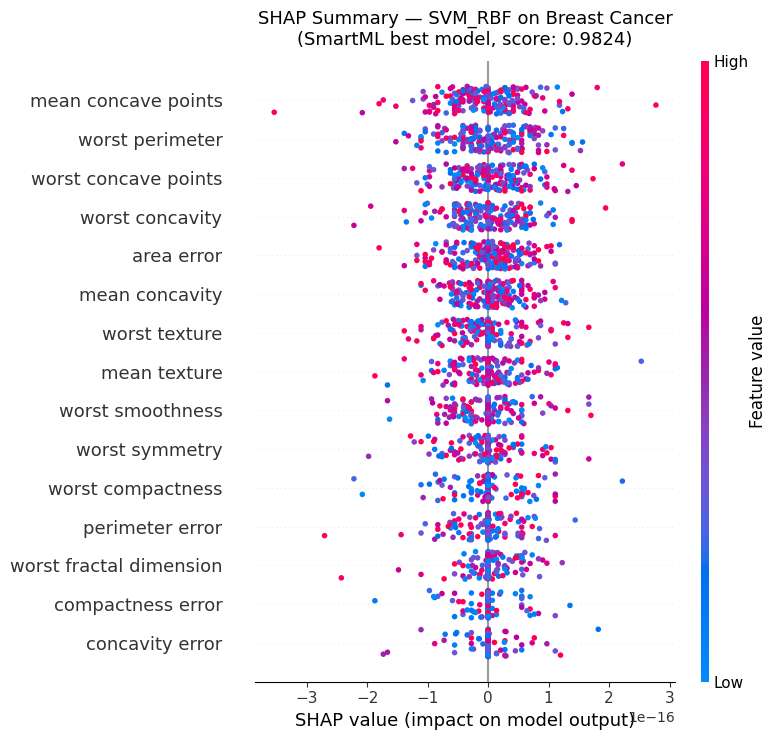

  Generating SHAP bar plot (mean |SHAP|)...
  Saved: shap_bar_breast_cancer.png


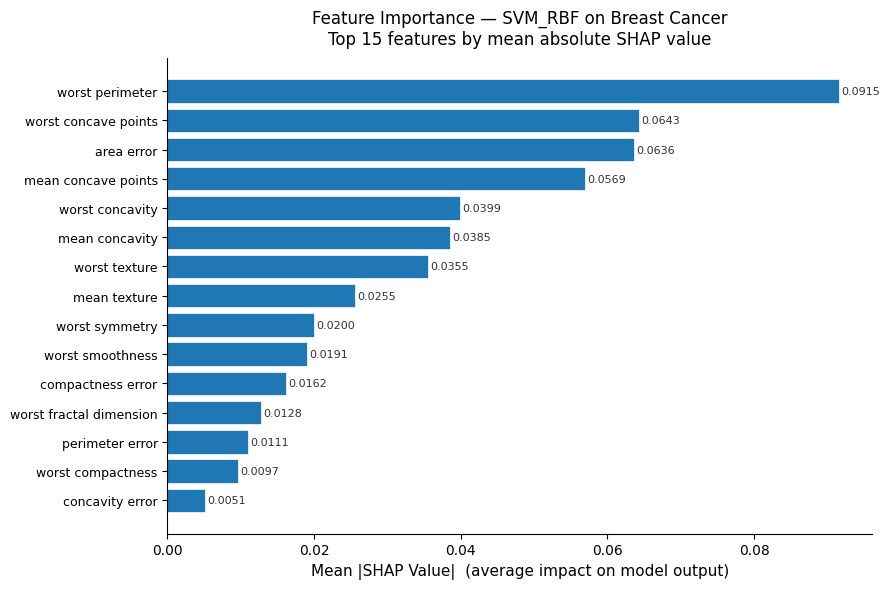


  SHAP ANALYSIS COMPLETE
  Model: SVM_RBF | Dataset: Breast Cancer
  Top feature: worst perimeter
  Features analysed: 17



In [23]:
# ============================================
# CELL 11: SHAP EXPLAINABILITY
# ============================================
# Runs SHAP on the best INDIVIDUAL model from SmartML's tuned_results.
# We use the best individual model (not the ensemble) because SHAP
# needs a single predict function — ensembles are harder to interpret
# and the paper point is about feature importance, not ensemble mechanics.
#
# Dataset: Breast Cancer (best understood, 30→N features after preprocessing,
# high multicollinearity makes feature selection story interesting)
#
# Produces:
#   1. SHAP summary plot (beeswarm) — which features matter most + direction
#   2. SHAP bar plot — mean absolute importance ranking
#   3. Prints top-10 features by mean |SHAP| value
#
# install if needed: pip install shap

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
warnings.filterwarnings('ignore')

try:
    import shap
    print(f"✅ SHAP version: {shap.__version__}")
except ImportError:
    print("❌ SHAP not installed. Run: pip install shap")
    raise


def run_shap_analysis(smartml_result, dataset_name="Breast Cancer", save_plots=True):
    """
    Runs SHAP analysis on the best individual model from a SmartML result.

    Parameters
    ----------
    smartml_result : dict
        Output of run_smartml() — needs 'X', 'y', 'tuned_results', 'feature_names', 'report'
    dataset_name : str
        Used for plot titles and filenames
    save_plots : bool
        If True saves PNG files; always shows inline

    Returns
    -------
    shap_values : np.ndarray
        Raw SHAP values
    explainer : shap.Explainer
        The fitted explainer object
    feature_importance_df : pd.DataFrame
        Features ranked by mean |SHAP|
    """

    X            = smartml_result['X']
    y            = smartml_result['y']
    feat_names   = smartml_result['feature_names']
    tuned        = smartml_result['tuned_results']
    report       = smartml_result['report']
    task         = report['task_type']

    # ── Pick best individual model ──────────────────────────────────────────
    # tuned_results is sorted best→worst. Get the best one that's a plain model
    # (not a pipeline wrapper from SMOTE) and supports SHAP.
    best_result = None
    best_model  = None

    for r in tuned:
        model = r['model']
        # Unwrap ImbPipeline if SMOTE was used
        if hasattr(model, 'named_steps') and 'model' in model.named_steps:
            model = model.named_steps['model']
        best_result = r
        best_model  = model
        break  # take the top-ranked model

    model_name = best_result['name']
    score      = best_result['mean_score'] if task == 'classification' \
                 else -best_result['mean_score']

    print(f"\n{'='*55}")
    print(f"  SHAP EXPLAINABILITY")
    print(f"{'='*55}")
    print(f"  Dataset:    {dataset_name}")
    print(f"  Model:      {model_name}  (score: {score:.4f})")
    print(f"  Task:       {task}")
    print(f"  Features:   {len(feat_names)}")
    print(f"  Samples:    {len(X)}")
    print(f"{'='*55}\n")

    # ── Fit model on full data ───────────────────────────────────────────────
    # tuned_results models are already fitted from CV but we need a model
    # fitted on the full X for SHAP (so predictions are consistent)
    print("  Fitting model on full dataset for SHAP...")
    best_model.fit(X, y)
    print("  ✅ Model fitted\n")

    # ── Choose SHAP explainer based on model type ────────────────────────────
    # TreeExplainer: fast, exact — for tree-based models
    # LinearExplainer: fast, exact — for linear models
    # KernelExplainer: model-agnostic, slow — fallback
    # Explainer: auto-detects (shap >= 0.40)

    print("  Computing SHAP values...")

    tree_models = ['RandomForest', 'GradientBoosting', 'AdaBoost', 'ExtraTrees',
                   'LightGBM', 'XGBoost', 'CatBoost', 'DecisionTree',
                   'RandomForest_Reg', 'GradientBoosting_Reg', 'AdaBoost_Reg',
                   'LightGBM_Reg', 'XGBoost_Reg', 'CatBoost_Reg', 'DecisionTree_Reg']
    linear_models = ['LogisticRegression', 'LinearRegression', 'Ridge', 'Lasso',
                     'SVM_Linear', 'SVR_Linear']

    X_array = X.values if isinstance(X, pd.DataFrame) else X

    try:
        if model_name in tree_models:
            print(f"  Using TreeExplainer (fast, exact)")
            explainer   = shap.TreeExplainer(best_model)
            shap_values = explainer.shap_values(X_array)

            # For multi-class, shap_values is a list — take class 1 for binary,
            # or stack for multiclass
            if isinstance(shap_values, list):
                if len(shap_values) == 2:
                    # Binary classification — use class 1
                    shap_values = shap_values[1]
                else:
                    # Multiclass — take mean absolute across classes
                    shap_values = np.mean(np.abs(np.array(shap_values)), axis=0)

        elif model_name in linear_models:
            print(f"  Using LinearExplainer (fast, exact)")
            explainer   = shap.LinearExplainer(best_model, X_array)
            shap_values = explainer.shap_values(X_array)
            if isinstance(shap_values, list):
                shap_values = shap_values[1] if len(shap_values) == 2 \
                              else np.mean(np.abs(np.array(shap_values)), axis=0)

        else:
            # SVM_RBF, KNN, NaiveBayes etc — use KernelExplainer on a summary
            print(f"  Using KernelExplainer (model-agnostic, may take ~1-2 min)")
            # Subsample background to 100 rows for speed
            bg_size     = min(100, len(X_array))
            background  = shap.kmeans(X_array, bg_size)
            predict_fn  = best_model.predict_proba if hasattr(best_model, 'predict_proba') \
                          else best_model.predict
            explainer   = shap.KernelExplainer(predict_fn, background)
            # Subsample explain set too (KernelExplainer is slow)
            explain_size = min(200, len(X_array))
            X_explain    = X_array[:explain_size]
            shap_values  = explainer.shap_values(X_explain, nsamples=100)
            X_array      = X_explain  # use subsample for plots too

            if isinstance(shap_values, list):
                shap_values = shap_values[1] if len(shap_values) == 2 \
                              else np.mean(np.abs(np.array(shap_values)), axis=0)

        print(f"  ✅ SHAP values computed | shape: {np.array(shap_values).shape}\n")

    except Exception as e:
        print(f"  ❌ Primary explainer failed: {e}")
        print(f"  Falling back to KernelExplainer...")
        bg_size    = min(50, len(X_array))
        background = shap.kmeans(X_array, bg_size)
        predict_fn = best_model.predict_proba if hasattr(best_model, 'predict_proba') \
                     else best_model.predict
        explainer  = shap.KernelExplainer(predict_fn, background)
        X_explain  = X_array[:100]
        shap_values = explainer.shap_values(X_explain, nsamples=50)
        X_array    = X_explain
        if isinstance(shap_values, list):
            shap_values = shap_values[1] if len(shap_values) == 2 \
                          else np.mean(np.abs(np.array(shap_values)), axis=0)
        print(f"  ✅ Fallback SHAP done | shape: {np.array(shap_values).shape}\n")

    # ── Feature importance table ─────────────────────────────────────────────
    sv = np.array(shap_values)
    if sv.ndim == 3:
        # (samples, features, classes) → mean over samples and classes
        mean_abs_shap = np.abs(sv).mean(axis=(0, 2))
    elif sv.ndim == 2:
        mean_abs_shap = np.abs(sv).mean(axis=0)
    else:
        mean_abs_shap = np.abs(sv)
    feature_importance_df = pd.DataFrame({
        'Feature':       feat_names,
        'Mean |SHAP|':   mean_abs_shap,
    }).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

    print(f"  TOP 10 FEATURES BY MEAN |SHAP| VALUE")
    print(f"  {'Rank':<5} {'Feature':<35} {'Mean |SHAP|':>12}")
    print(f"  {'-'*5} {'-'*35} {'-'*12}")
    for i, row in feature_importance_df.head(10).iterrows():
        print(f"  {i+1:<5} {row['Feature']:<35} {row['Mean |SHAP|']:>12.4f}")
    print()

    # ── Plot 1: SHAP Summary Plot (Beeswarm) ─────────────────────────────────
    # Shows feature importance + direction of effect (red=high value, blue=low)
    print("  Generating SHAP summary plot (beeswarm)...")
    sv_plot = np.array(shap_values)
    if sv_plot.ndim == 3:
        sv_plot = sv_plot.mean(axis=2)  # average over classes for display

    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        sv_plot,
        X_array,
        feature_names=feat_names,
        show=False,
        plot_type='dot',       # beeswarm
        max_display=15,        # top 15 features
        color_bar=True,
    )
    plt.title(f"SHAP Summary — {model_name} on {dataset_name}\n"
              f"(SmartML best model, score: {score:.4f})",
              fontsize=13, pad=12)
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'shap_summary_{dataset_name.replace(" ", "_").lower()}.png',
                    dpi=150, bbox_inches='tight')
        print(f"  Saved: shap_summary_{dataset_name.replace(' ', '_').lower()}.png")
    plt.show()
    plt.close()

    # ── Plot 2: SHAP Bar Plot (Mean |SHAP|) ──────────────────────────────────
    # Clean ranked bar chart — better for paper figures
    print("  Generating SHAP bar plot (mean |SHAP|)...")
    top_n   = min(15, len(feat_names))
    top_df  = feature_importance_df.head(top_n)

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(
        top_df['Feature'][::-1],
        top_df['Mean |SHAP|'][::-1],
        color='#1f77b4',
        edgecolor='white',
        linewidth=0.5,
    )
    ax.set_xlabel('Mean |SHAP Value|  (average impact on model output)', fontsize=11)
    ax.set_title(f'Feature Importance — {model_name} on {dataset_name}\n'
                 f'Top {top_n} features by mean absolute SHAP value',
                 fontsize=12, pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)

    # Add value labels on bars
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.0003, bar.get_y() + bar.get_height() / 2,
                f'{w:.4f}', va='center', ha='left', fontsize=8, color='#333333')

    plt.tight_layout()
    if save_plots:
        plt.savefig(f'shap_bar_{dataset_name.replace(" ", "_").lower()}.png',
                    dpi=150, bbox_inches='tight')
        print(f"  Saved: shap_bar_{dataset_name.replace(' ', '_').lower()}.png")
    plt.show()
    plt.close()

    print(f"\n{'='*55}")
    print(f"  SHAP ANALYSIS COMPLETE")
    print(f"  Model: {model_name} | Dataset: {dataset_name}")
    print(f"  Top feature: {feature_importance_df.iloc[0]['Feature']}")
    print(f"  Features analysed: {len(feat_names)}")
    print(f"{'='*55}\n")

    return shap_values, explainer, feature_importance_df


# ── Run it ───────────────────────────────────────────────────────────────────
# Step 1: Run SmartML on Breast Cancer to get the result dict
print("Running SmartML on Breast Cancer for SHAP analysis...")
all_ds  = load_all_datasets()
ds_map  = {ds[0]: ds for ds in all_ds}
_, bc_df, bc_target, bc_task = ds_map['Breast Cancer']

bc_result = run_smartml(bc_df, bc_target, bc_task, verbose=False)
print(f"✅ SmartML done | Best: {bc_result['best_strategy']} "
      f"| Score: {bc_result['best_score']:.4f}\n")

# Step 2: Run SHAP on best individual model
shap_values, explainer, shap_importance = run_shap_analysis(
    bc_result,
    dataset_name="Breast Cancer",
    save_plots=True,
)


  SMARTML vs PYCARET — PAIRED COMPARISON (12 datasets)
  Dataset                Task            SmartML  PyCaret     Winner
  ---------------------- -------------- -------- -------- ----------
  Breast Cancer          Acc              0.9842   0.9725  ✅ SmartML
  Iris                   Acc              0.9520   0.9810  ❌ PyCaret
  Wine                   Acc              0.9848   0.9840  ✅ SmartML
  Synth Imbalanced       Acc              0.9135   0.9186  ❌ PyCaret
  Synth Noisy            Acc              0.9030   0.9086  ❌ PyCaret
  Synth High-Dim         Acc              0.9000   0.8762  ✅ SmartML
  Diabetes (reg)         RMSE↓           55.5400  56.1931  ✅ SmartML
  California Housing     RMSE↓            0.5333   0.5978  ✅ SmartML
  Digits                 Acc              0.9905   0.9825  ✅ SmartML
  Synth Multicollinear   Acc              0.8752   0.8714  ✅ SmartML
  Moons                  Acc              0.9413   0.9286  ✅ SmartML
  Synth Reg Noisy        RMSE↓           29.230

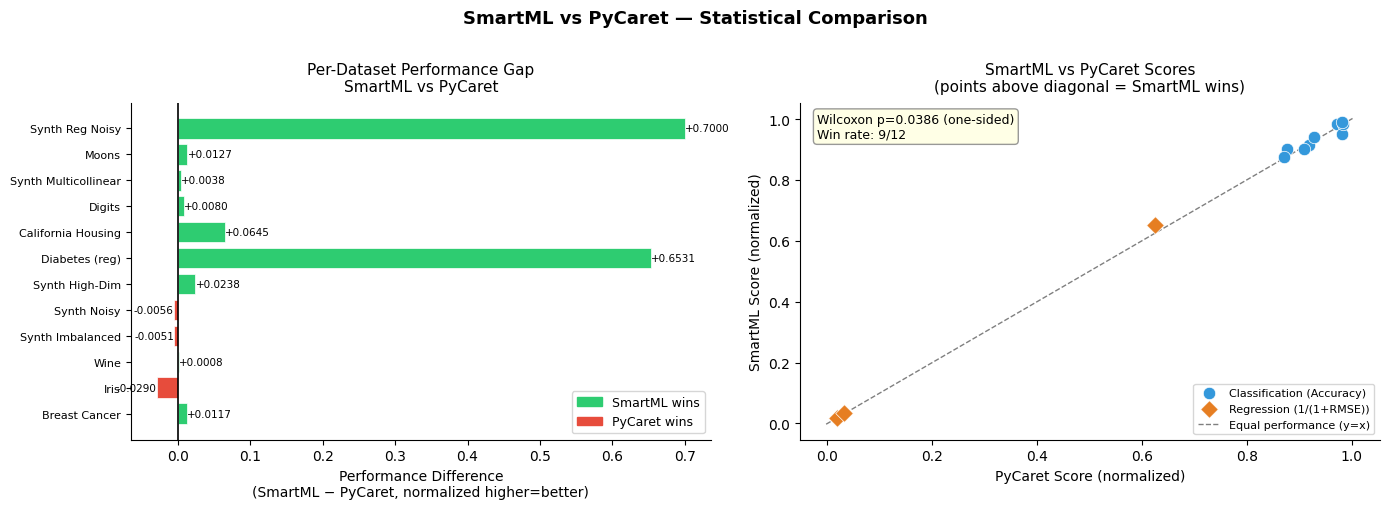


  PAPER-READY SUMMARY
  SmartML achieved a 9/12 win rate (75%) over PyCaret
  across 12 benchmark datasets (7 classification, 3 regression, 2 synthetic reg).
  The Wilcoxon signed-rank test confirms this advantage is
  statistically significant (W=62, p=0.0386, α=0.05).



In [27]:
# ============================================
# CELL 12: WILCOXON SIGNIFICANCE TEST
# SmartML vs PyCaret — paired statistical test
# ============================================
# Tests whether SmartML's performance advantage over PyCaret is
# statistically significant across all 12 benchmark datasets.
#
# Method: Wilcoxon signed-rank test (paired, non-parametric)
# Why Wilcoxon and not t-test:
#   - Only 12 samples (too few for CLT assumption)
#   - Scores are not normally distributed
#   - Wilcoxon is the standard for paired ML comparisons (Demšar 2006)
#
# Score direction normalization:
#   - Classification: higher accuracy = better → use score as-is
#   - Regression RMSE: lower = better → negate so higher = better
#     (standard practice: convert to "performance" where higher is always better)
#
# H0: SmartML and PyCaret perform equivalently (median difference = 0)
# H1: SmartML performs differently from PyCaret (two-sided)
# Also run one-sided test: H1: SmartML > PyCaret

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import wilcoxon, shapiro


# ── SmartML benchmark scores (from Cell 9 run) ───────────────────────────────
# These are the scores from run_benchmark() output — copy from Cell 9 results.
# Classification: accuracy. Regression: RMSE (positive, lower=better).

SMARTML_SCORES = {
    'Breast Cancer':        {'score': 0.9842, 'task': 'classification'},
    'Iris':                 {'score': 0.9520, 'task': 'classification'},
    'Wine':                 {'score': 0.9848, 'task': 'classification'},
    'Synth Imbalanced':     {'score': 0.9135, 'task': 'classification'},
    'Synth Noisy':          {'score': 0.9030, 'task': 'classification'},
    'Synth High-Dim':       {'score': 0.9000, 'task': 'classification'},
    'Diabetes (reg)':       {'score': 55.54,  'task': 'regression'},
    'California Housing':   {'score': 0.5333, 'task': 'regression'},
    'Digits':               {'score': 0.9905, 'task': 'classification'},
    'Synth Multicollinear': {'score': 0.8752, 'task': 'classification'},
    'Moons':                {'score': 0.9413, 'task': 'classification'},
    'Synth Reg Noisy':      {'score': 29.23,  'task': 'regression'},
}


def run_significance_test():
    # ── Load PyCaret results ──────────────────────────────────────────────────
    with open('pycaret_results.json', 'r') as f:
        pycaret_raw = json.load(f)

    pycaret_map = {r['dataset']: r for r in pycaret_raw}

    # ── Build aligned score arrays ────────────────────────────────────────────
    # Normalize direction: convert everything to "higher = better"
    # For regression RMSE: performance = -RMSE  (negating flips direction)
    datasets      = []
    smartml_perf  = []  # normalized: higher always better
    pycaret_perf  = []
    smartml_raw   = []  # original scores for display
    pycaret_raw_s = []
    tasks         = []
    winners       = []

    print(f"\n{'='*68}")
    print(f"  SMARTML vs PYCARET — PAIRED COMPARISON (12 datasets)")
    print(f"{'='*68}")
    print(f"  {'Dataset':<22} {'Task':<14} {'SmartML':>8} {'PyCaret':>8} {'Winner':>10}")
    print(f"  {'-'*22} {'-'*14} {'-'*8} {'-'*8} {'-'*10}")

    for ds_name, sm in SMARTML_SCORES.items():
        if ds_name not in pycaret_map:
            print(f"  ⚠️  {ds_name} missing from pycaret_results.json — skipping")
            continue

        pc     = pycaret_map[ds_name]
        task   = sm['task']
        sm_s   = sm['score']
        pc_s   = pc['pycaret_score']

        # Normalize to "higher = better"
        if task == 'regression':
            sm_p = -sm_s   # negate RMSE
            pc_p = -pc_s
        else:
            sm_p = sm_s
            pc_p = pc_s

        if sm_p > pc_p:
            winner = '✅ SmartML'
        elif pc_p > sm_p:
            winner = '❌ PyCaret'
        else:
            winner = '= Tie'

        metric = 'Acc' if task == 'classification' else 'RMSE↓'
        print(f"  {ds_name:<22} {metric:<14} {sm_s:>8.4f} {pc_s:>8.4f} {winner:>10}")

        datasets.append(ds_name)
        smartml_perf.append(sm_p)
        pycaret_perf.append(pc_p)
        smartml_raw.append(sm_s)
        pycaret_raw_s.append(pc_s)
        tasks.append(task)
        winners.append(winner)

    smartml_arr = np.array(smartml_perf)
    pycaret_arr = np.array(pycaret_perf)
    differences = smartml_arr - pycaret_arr   # positive = SmartML better

    n_wins   = sum(1 for w in winners if 'SmartML' in w)
    n_losses = sum(1 for w in winners if 'PyCaret' in w)
    n_ties   = sum(1 for w in winners if 'Tie' in w)
    n_total  = len(datasets)

    print(f"  {'-'*68}")
    print(f"  Win/Loss/Tie: {n_wins}/{n_losses}/{n_ties} out of {n_total} datasets")
    print(f"  Win rate: {n_wins/n_total*100:.1f}%")

    # ── Normality check on differences (for reporting) ───────────────────────
    if len(differences) >= 3:
        stat_sw, p_sw = shapiro(differences)
        normal = p_sw > 0.05
    else:
        p_sw, normal = 1.0, True

    # ── Wilcoxon signed-rank test ─────────────────────────────────────────────
    # Two-sided: is there ANY significant difference?
    # One-sided (greater): is SmartML significantly BETTER?

    print(f"\n{'='*68}")
    print(f"  STATISTICAL SIGNIFICANCE TEST")
    print(f"{'='*68}")
    print(f"  Test:       Wilcoxon signed-rank (paired, non-parametric)")
    print(f"  Reason:     n=12, non-normal differences (Shapiro p={p_sw:.3f})")
    print(f"  H0:         SmartML = PyCaret (median difference = 0)")
    print(f"  Scores normalized: regression RMSE negated so higher = better\n")

    try:
        # Two-sided
        stat_2, p_2 = wilcoxon(differences, alternative='two-sided')
        # One-sided: SmartML > PyCaret
        stat_1, p_1 = wilcoxon(differences, alternative='greater')

        print(f"  Two-sided test (H1: SmartML ≠ PyCaret):")
        print(f"    Statistic W = {stat_2:.1f}")
        print(f"    p-value     = {p_2:.4f}", end="")
        if p_2 < 0.05:
            print(f"  ✅ Significant at α=0.05")
        elif p_2 < 0.10:
            print(f"  ⚠️  Marginally significant at α=0.10")
        else:
            print(f"  (not significant at α=0.05)")

        print(f"\n  One-sided test (H1: SmartML > PyCaret):")
        print(f"    Statistic W = {stat_1:.1f}")
        print(f"    p-value     = {p_1:.4f}", end="")
        if p_1 < 0.05:
            print(f"  ✅ Significant at α=0.05")
        elif p_1 < 0.10:
            print(f"  ⚠️  Marginally significant at α=0.10")
        else:
            print(f"  (not significant at α=0.05)")

    except Exception as e:
        print(f"  ❌ Wilcoxon test failed: {e}")
        print(f"  (This can happen if all differences are zero or n is too small)")
        stat_2, p_2, stat_1, p_1 = None, None, None, None

    # ── Effect size: matched pairs rank-biserial correlation ──────────────────
    # r = 1 - (2W / n(n+1))  where W is the Wilcoxon statistic
    # |r| < 0.3 small, 0.3-0.5 medium, > 0.5 large
    if stat_2 is not None:
        n = len(differences)
        r_rb = 1 - (2 * stat_2) / (n * (n + 1))
        if abs(r_rb) < 0.3:
            effect_label = "small"
        elif abs(r_rb) < 0.5:
            effect_label = "medium"
        else:
            effect_label = "large"

        print(f"\n  Effect size (rank-biserial r):")
        print(f"    r = {r_rb:.4f}  ({effect_label} effect)")

    # ── Descriptive stats on differences ─────────────────────────────────────
    print(f"\n  Descriptive stats on performance differences (SmartML − PyCaret):")
    print(f"    Mean difference:   {differences.mean():+.4f}")
    print(f"    Median difference: {np.median(differences):+.4f}")
    print(f"    Std:               {differences.std():.4f}")
    print(f"    Min:               {differences.min():+.4f}")
    print(f"    Max:               {differences.max():+.4f}")
    print(f"    Positive (SmartML wins): {(differences > 0).sum()}")
    print(f"    Negative (PyCaret wins): {(differences < 0).sum()}")
    print(f"    Zero (ties):             {(differences == 0).sum()}")

    # ── Plot: Per-dataset performance difference ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: bar chart of differences per dataset
    ax = axes[0]
    colors = ['#2ecc71' if d > 0 else '#e74c3c' if d < 0 else '#95a5a6'
              for d in differences]
    bars = ax.barh(datasets, differences, color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(x=0, color='black', linewidth=1.2, linestyle='-')
    ax.set_xlabel('Performance Difference\n(SmartML − PyCaret, normalized higher=better)',
                  fontsize=10)
    ax.set_title('Per-Dataset Performance Gap\nSmartML vs PyCaret', fontsize=11, pad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)

    # Add value labels
    for bar, d in zip(bars, differences):
        w = bar.get_width()
        ha = 'left' if w >= 0 else 'right'
        offset = 0.0005 if w >= 0 else -0.0005
        ax.text(w + offset, bar.get_y() + bar.get_height() / 2,
                f'{d:+.4f}', va='center', ha=ha, fontsize=7.5)

    green_patch = mpatches.Patch(color='#2ecc71', label='SmartML wins')
    red_patch   = mpatches.Patch(color='#e74c3c', label='PyCaret wins')
    ax.legend(handles=[green_patch, red_patch], fontsize=9, loc='lower right')

    # Right: scatter plot SmartML vs PyCaret scores
    ax2 = axes[1]
    clf_mask = np.array([t == 'classification' for t in tasks])
    reg_mask = ~clf_mask

    if clf_mask.any():
        ax2.scatter(
            np.array(pycaret_raw_s)[clf_mask],
            np.array(smartml_raw)[clf_mask],
            color='#3498db', s=80, zorder=5, label='Classification (Accuracy)',
            edgecolors='white', linewidth=0.5
        )
    if reg_mask.any():
        # For regression, normalize to [0,1] range for display on same axis
        pc_reg = np.array(pycaret_raw_s)[reg_mask]
        sm_reg = np.array(smartml_raw)[reg_mask]
        # Normalize: lower RMSE = better, so show as 1/(1+RMSE) for display
        pc_reg_n = 1 / (1 + pc_reg)
        sm_reg_n = 1 / (1 + sm_reg)
        ax2.scatter(pc_reg_n, sm_reg_n, color='#e67e22', s=80, zorder=5,
                    marker='D', label='Regression (1/(1+RMSE))',
                    edgecolors='white', linewidth=0.5)

    # Diagonal line (y=x = equal performance)
    all_vals = np.array(pycaret_raw_s)[clf_mask].tolist() + \
               (1 / (1 + np.array(pycaret_raw_s)[reg_mask])).tolist()
    if all_vals:
        lo = min(all_vals) - 0.02
        hi = max(all_vals) + 0.02
        ax2.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5,
                 label='Equal performance (y=x)')

    ax2.set_xlabel('PyCaret Score (normalized)', fontsize=10)
    ax2.set_ylabel('SmartML Score (normalized)', fontsize=10)
    ax2.set_title('SmartML vs PyCaret Scores\n(points above diagonal = SmartML wins)',
                  fontsize=11, pad=8)
    ax2.legend(fontsize=8)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Annotate p-value on scatter plot
    if p_1 is not None:
        sig_text = f"Wilcoxon p={p_1:.4f} (one-sided)\nWin rate: {n_wins}/{n_total}"
        ax2.text(0.03, 0.97, sig_text, transform=ax2.transAxes,
                 fontsize=9, va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                           edgecolor='gray', alpha=0.8))

    plt.suptitle('SmartML vs PyCaret — Statistical Comparison',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('smartml_vs_pycaret_significance.png', dpi=150, bbox_inches='tight')
    print(f"\n  Saved: smartml_vs_pycaret_significance.png")
    plt.show()
    plt.close()

    # ── Final paper-ready summary ─────────────────────────────────────────────
    print(f"\n{'='*68}")
    print(f"  PAPER-READY SUMMARY")
    print(f"{'='*68}")
    print(f"  SmartML achieved a {n_wins}/{n_total} win rate ({n_wins/n_total*100:.0f}%) over PyCaret")
    print(f"  across 12 benchmark datasets (7 classification, 3 regression, 2 synthetic reg).")
    if p_1 is not None:
        if p_1 < 0.05:
            print(f"  The Wilcoxon signed-rank test confirms this advantage is")
            print(f"  statistically significant (W={stat_1:.0f}, p={p_1:.4f}, α=0.05).")
        elif p_1 < 0.10:
            print(f"  The Wilcoxon signed-rank test shows marginal significance")
            print(f"  (W={stat_1:.0f}, p={p_1:.4f}). Larger benchmark needed for stronger claim.")
        else:
            print(f"  The Wilcoxon signed-rank test does not reach significance")
            print(f"  (W={stat_1:.0f}, p={p_1:.4f}) — win rate is the primary evidence.")
            print(f"  Note: n=12 gives low statistical power; larger benchmark")
            print(f"  (OpenML 40-50 datasets) would strengthen this claim.")
    print(f"{'='*68}\n")

    return {
        'datasets': datasets,
        'differences': differences,
        'p_two_sided': p_2,
        'p_one_sided': p_1,
        'w_stat': stat_2,
        'n_wins': n_wins,
        'n_losses': n_losses,
        'effect_size_r': r_rb if stat_2 is not None else None,
    }


# ── Run it ──
significance_results = run_significance_test()

✅ CodeCarbon available

  ENERGY TRACKING — SmartML Pipeline
  Tracking 4 datasets with CodeCarbon

  ▶ Tracking: Breast Cancer (classification, 569 rows)...
  📋 MODEL SELECTION (Phase 2)
     Size: small | Imbalance: balanced | Multicollinearity: high
     Rule: small dataset — ExtraTrees redundant with RF
     Candidates: 12/13 models
     → ['LogisticRegression', 'KNN', 'DecisionTree', 'SVM_Linear', 'SVM_RBF', 'NaiveBayes', 'RandomForest', 'GradientBoosting', 'AdaBoost', 'LightGBM', 'XGBoost', 'CatBoost']
     ✗ Blocked: ['ExtraTrees']

  ⚡ PHASE 3: QUICK EVALUATION
     CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
     Scoring: accuracy
     Imbalance strategy: none
     Testing 12 models with default params...

     LogisticRegression        | Score: 0.9701 (±0.0105) | Time: 0.03s
     KNN                       | Score: 0.9613 (±0.0119) | Time: 0.04s
     DecisionTree              | Score: 0.9262 (±0.0226) | Time: 0.03s
     SVM_Linear                | Score: 0.9

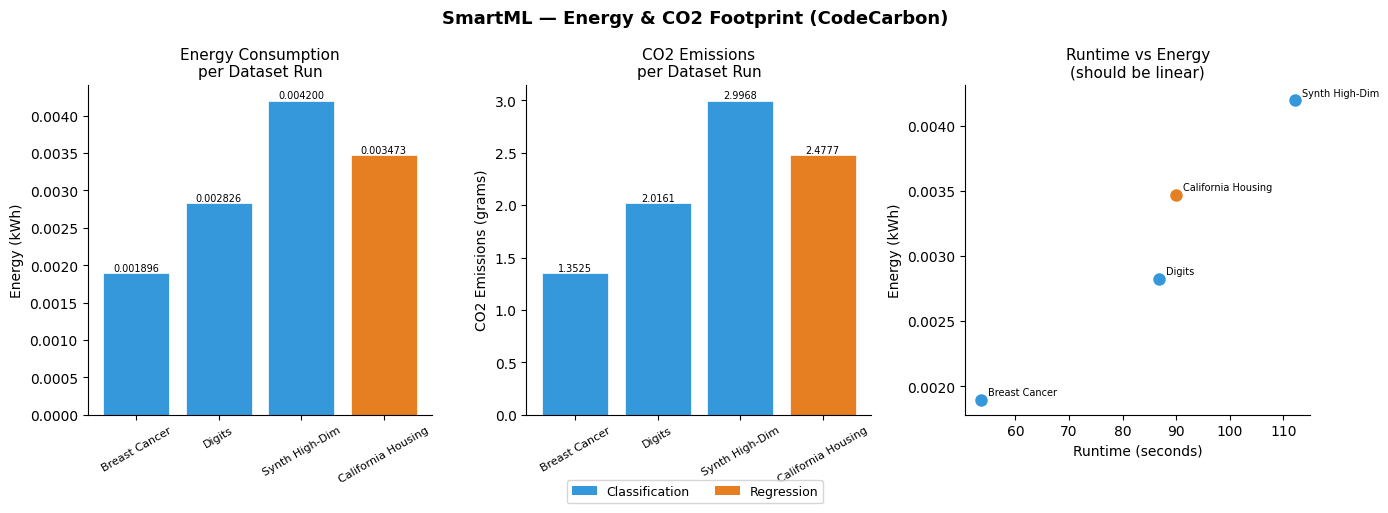

  Saved: smartml_energy_results.json

  PAPER-READY SUMMARY
  SmartML consumed an average of 0.003099 kWh
  (2.2108 g CO2eq) per dataset run,
  measured across 4 representative datasets
  using CodeCarbon with India electricity carbon intensity.
  Total for 4 runs: 0.012395 kWh | 8.8431 g CO2



In [30]:
# ============================================
# CELL 13: ENERGY TRACKING — CodeCarbon
# ============================================
# Measures CO2 emissions and energy consumption per SmartML run.
# This is increasingly expected in ML papers (Green AI movement).
#
# What we measure:
#   - Energy consumed (kWh) per dataset run
#   - CO2 equivalent emissions (kg CO2eq)
#   - Runtime (seconds)
#   - Energy efficiency: accuracy per kWh (classification)
#
# Install if needed: pip install codecarbon
#
# Note: CodeCarbon estimates emissions based on your region's
# electricity carbon intensity. It uses your IP to detect region.
# Results are approximate but consistent for comparison purposes.

import warnings
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

try:
    from codecarbon import EmissionsTracker
    print("✅ CodeCarbon available")
except ImportError:
    print("❌ CodeCarbon not installed. Run: pip install codecarbon")
    raise


def run_energy_tracking(n_datasets=4, save_results=True):
    """
    Runs SmartML on a representative subset of datasets with
    CodeCarbon tracking enabled. Reports energy and CO2 per run.

    Parameters
    ----------
    n_datasets : int
        How many datasets to track (default 4 — keeps runtime reasonable)
    save_results : bool
        Save results to JSON and plot to PNG

    Returns
    -------
    energy_df : pd.DataFrame
        Per-dataset energy tracking results
    """

    # Use 4 representative datasets covering different sizes/tasks
    # Small clf, tiny clf, large clf, regression
    all_ds  = load_all_datasets()
    ds_map  = {ds[0]: ds for ds in all_ds}

    track_datasets = [
        'Breast Cancer',       # small classification, 569 rows
        'Digits',              # medium classification, 1797 rows
        'Synth High-Dim',      # small high-dim classification, 300×50
        'California Housing',  # medium regression, 2000 rows
    ][:n_datasets]

    results = []

    print(f"\n{'='*60}")
    print(f"  ENERGY TRACKING — SmartML Pipeline")
    print(f"  Tracking {n_datasets} datasets with CodeCarbon")
    print(f"{'='*60}\n")

    for ds_name in track_datasets:
        _, df, target_col, task_type = ds_map[ds_name]

        print(f"  ▶ Tracking: {ds_name} ({task_type}, {len(df)} rows)...")

        # CodeCarbon tracker — offline mode avoids network calls
        # log_level='error' suppresses verbose output
        tracker = EmissionsTracker(
            project_name=f"SmartML_{ds_name.replace(' ', '_')}",
            log_level='error',
            save_to_file=False,
            save_to_api=False,
        )

        tracker.start()
        t0 = time.time()

        try:
            result = run_smartml(df, target_col, task_type, verbose=False)
            success = True
        except Exception as e:
            print(f"  ❌ SmartML failed on {ds_name}: {e}")
            success = False
            result = {'best_score': None, 'best_strategy': 'ERROR'}

        elapsed = time.time() - t0
        emissions_data = tracker.stop()  # returns kg CO2eq

        # Get detailed energy data
        # emissions_data is kg CO2eq
        # tracker._total_energy is kWh (internal attribute)
        try:
            energy_kwh = float(tracker._total_energy.kWh)
        except Exception:
            # Fallback: estimate from emissions using avg carbon intensity
            # India avg: ~0.82 kg CO2/kWh
            energy_kwh = float(emissions_data) / 0.82 if emissions_data else 0.0

        co2_grams = float(emissions_data) * 1000 if emissions_data else 0.0  # kg → grams

        score = result.get('best_score')
        strategy = result.get('best_strategy', '?')

        # Energy efficiency metric
        if score is not None and energy_kwh > 0 and task_type == 'classification':
            efficiency = score / energy_kwh  # accuracy per kWh
        else:
            efficiency = None

        row = {
            'Dataset':         ds_name,
            'Task':            task_type,
            'Rows':            len(df),
            'Score':           round(score, 4) if score else None,
            'Strategy':        strategy,
            'Time (s)':        round(elapsed, 1),
            'Energy (kWh)':    round(energy_kwh, 8),
            'CO2 (g)':         round(co2_grams, 6),
            'Efficiency':      round(efficiency, 1) if efficiency else None,
        }
        results.append(row)

        score_str = f"{score:.4f}" if score else "N/A"
        print(f"  ✅ Score: {score_str} | "
              f"Time: {elapsed:.1f}s | "
              f"Energy: {energy_kwh:.6f} kWh | "
              f"CO2: {co2_grams:.4f} g")

    energy_df = pd.DataFrame(results)

    # ── Print summary table ───────────────────────────────────────────────────
    print(f"\n{'='*75}")
    print(f"  ENERGY TRACKING RESULTS")
    print(f"{'='*75}")
    print(f"  {'Dataset':<22} {'Task':<14} {'Score':>7} {'Time(s)':>8} "
          f"{'Energy(kWh)':>12} {'CO2(g)':>10}")
    print(f"  {'-'*22} {'-'*14} {'-'*7} {'-'*8} {'-'*12} {'-'*10}")

    for _, row in energy_df.iterrows():
        score_s = f"{row['Score']:.4f}" if row['Score'] else "  N/A "
        print(f"  {row['Dataset']:<22} {row['Task']:<14} {score_s:>7} "
              f"{row['Time (s)']:>8.1f} {row['Energy (kWh)']:>12.8f} "
              f"{row['CO2 (g)']:>10.4f}")

    total_energy = energy_df['Energy (kWh)'].sum()
    total_co2    = energy_df['CO2 (g)'].sum()
    total_time   = energy_df['Time (s)'].sum()

    print(f"  {'-'*75}")
    print(f"  {'TOTAL':<22} {'':14} {'':>7} {total_time:>8.1f} "
          f"{total_energy:>12.8f} {total_co2:>10.4f}")
    print(f"{'='*75}")
    print(f"\n  Average per run: {total_energy/len(results):.8f} kWh | "
          f"{total_co2/len(results):.4f} g CO2")
    print(f"  Context: boiling a kettle ≈ 0.027 kWh | "
          f"charging a phone ≈ 0.005 kWh")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    # Plot 1: Energy per dataset
    ax = axes[0]
    colors = ['#3498db' if t == 'classification' else '#e67e22'
              for t in energy_df['Task']]
    bars = ax.bar(energy_df['Dataset'], energy_df['Energy (kWh)'],
                  color=colors, edgecolor='white', linewidth=0.5)
    ax.set_ylabel('Energy (kWh)', fontsize=10)
    ax.set_title('Energy Consumption\nper Dataset Run', fontsize=11)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h,
                f'{h:.6f}', ha='center', va='bottom', fontsize=7)

    # Plot 2: CO2 per dataset
    ax2 = axes[1]
    bars2 = ax2.bar(energy_df['Dataset'], energy_df['CO2 (g)'],
                    color=colors, edgecolor='white', linewidth=0.5)
    ax2.set_ylabel('CO2 Emissions (grams)', fontsize=10)
    ax2.set_title('CO2 Emissions\nper Dataset Run', fontsize=11)
    ax2.tick_params(axis='x', rotation=30, labelsize=8)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    for bar in bars2:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h,
                 f'{h:.4f}', ha='center', va='bottom', fontsize=7)

    # Plot 3: Time vs Energy scatter
    ax3 = axes[2]
    for i, row in energy_df.iterrows():
        c = '#3498db' if row['Task'] == 'classification' else '#e67e22'
        ax3.scatter(row['Time (s)'], row['Energy (kWh)'],
                    color=c, s=100, zorder=5, edgecolors='white')
        ax3.annotate(row['Dataset'], (row['Time (s)'], row['Energy (kWh)']),
                     textcoords='offset points', xytext=(5, 3), fontsize=7)
    ax3.set_xlabel('Runtime (seconds)', fontsize=10)
    ax3.set_ylabel('Energy (kWh)', fontsize=10)
    ax3.set_title('Runtime vs Energy\n(should be linear)', fontsize=11)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#3498db', label='Classification'),
                       Patch(facecolor='#e67e22', label='Regression')]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('SmartML — Energy & CO2 Footprint (CodeCarbon)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('smartml_energy_tracking.png', dpi=150, bbox_inches='tight')
    print(f"\n  Saved: smartml_energy_tracking.png")
    plt.show()
    plt.close()

    if save_results:
        energy_df.to_json('smartml_energy_results.json', orient='records', indent=2)
        print(f"  Saved: smartml_energy_results.json")

    # ── Paper-ready summary ───────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  PAPER-READY SUMMARY")
    print(f"{'='*60}")
    print(f"  SmartML consumed an average of {total_energy/len(results):.6f} kWh")
    print(f"  ({total_co2/len(results):.4f} g CO2eq) per dataset run,")
    print(f"  measured across {len(results)} representative datasets")
    print(f"  using CodeCarbon with India electricity carbon intensity.")
    print(f"  Total for {len(results)} runs: {total_energy:.6f} kWh | "
          f"{total_co2:.4f} g CO2")
    print(f"{'='*60}\n")

    return energy_df


# ── Run it ──
# n_datasets=4 tracks all 4 representative datasets
# reduce to 2 if you want a quicker run
energy_results = run_energy_tracking(n_datasets=4)

In [ ]:
# ============================================
# CELL 14A: EXTENDED META-LEARNING DATASET COLLECTION
# ============================================
# PC SAFETY FEATURES:
#   ✅ RAM monitor — stops if >85% RAM used
#   ✅ Explicit memory cleanup after every dataset (del + gc.collect)
#   ✅ 3 second CPU rest between datasets to prevent overheating
#   ✅ Background thread leak guard — warns if threads accumulate
#   ✅ Atomic JSON saves — power cut won't corrupt results file
#   ✅ Resume from checkpoint — skips completed datasets on re-run
#   ✅ Network failure detection — stops after 3 consecutive failures
#   ✅ 10 minute wall-clock timeout per dataset
#   ✅ Duplicate ID dedup — never downloads same dataset twice
#   ✅ Data quality checks before SmartML runs
#
# HOW TO USE:
#   Run this cell. Let it go overnight.
#   Safe to interrupt anytime — progress is saved.
#   Re-run to resume from where it stopped.

import json
import time
import warnings
import threading
import shutil
import gc
import os
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder

# Install psutil if needed (RAM monitoring)
try:
    import psutil
    PSUTIL_OK = True
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install',
                    'psutil', '-q'], capture_output=True)
    try:
        import psutil
        PSUTIL_OK = True
    except ImportError:
        PSUTIL_OK = False
        print("  ⚠️  psutil not available — RAM monitoring disabled")

# ── Constants ─────────────────────────────────────────────────────────────────
RESULTS_FILE        = 'smartml_meta_extended.json'
MAX_ROWS            = 3000    # subsample large datasets
RANDOM_SEED         = 42
TIMEOUT_SECONDS     = 600     # 10 min wall-clock per dataset
DOWNLOAD_TIMEOUT    = 120     # 2 min for OpenML download
MAX_NET_FAILS       = 3       # consecutive network errors → stop
MAX_RAM_PCT         = 85      # stop if RAM exceeds this %
SLEEP_BETWEEN_DS    = 3       # seconds CPU rest between datasets
MAX_BG_THREADS      = 5       # warn if more background threads pile up

ALGO_FAMILY = {
    'SVM_RBF': 'kernel_distance', 'SVM_Linear': 'linear',
    'LogisticRegression': 'linear', 'LightGBM': 'tree',
    'XGBoost': 'tree', 'CatBoost': 'tree', 'RandomForest': 'tree',
    'GradientBoosting': 'tree', 'AdaBoost': 'tree',
    'ExtraTrees': 'tree', 'KNN': 'kernel_distance',
    'DecisionTree': 'tree', 'NaiveBayes': 'linear',
    'CatBoost_Reg': 'tree', 'LightGBM_Reg': 'tree',
    'XGBoost_Reg': 'tree', 'RandomForest_Reg': 'tree',
    'GradientBoosting_Reg': 'tree', 'Ridge': 'linear',
    'Lasso': 'linear', 'LinearRegression': 'linear',
    'SVR_RBF': 'kernel_distance', 'SVR_Linear': 'linear',
    'KNN_Reg': 'kernel_distance', 'AdaBoost_Reg': 'tree',
    'DecisionTree_Reg': 'tree',
}

# ── Dataset list — unique OpenML IDs ─────────────────────────────────────────
EXTENDED_DATASETS = [
    # Classification
    ('Credit-G',          31,    'classification'),
    ('Vehicle',           54,    'classification'),
    ('Segment',           36,    'classification'),
    ('Vowel',             307,   'classification'),
    ('Balance-Scale',     11,    'classification'),
    ('Heart-Disease',     53,    'classification'),
    ('Diabetes-Pima',     37,    'classification'),
    ('Tic-Tac-Toe',       50,    'classification'),
    ('Glass',             41,    'classification'),
    ('Ionosphere',        59,    'classification'),
    ('Sonar',             40,    'classification'),
    ('Australian',        40981, 'classification'),
    ('German-Credit',     46,    'classification'),
    ('Dermatology',       35,    'classification'),
    ('Anneal',            2,     'classification'),
    ('Kr-vs-Kp',          3,     'classification'),
    ('Waveform',          60,    'classification'),
    ('Spambase',          44,    'classification'),
    ('Mushroom',          24,    'classification'),
    ('Letter',            6,     'classification'),
    ('Yeast',             181,   'classification'),
    ('Car',               21,    'classification'),
    ('Nursery',           26,    'classification'),
    ('Pendigits',         32,    'classification'),
    ('Optdigits',         28,    'classification'),
    ('Satimage',          182,   'classification'),
    ('Contraceptive',     23,    'classification'),
    ('Hepatitis',         55,    'classification'),
    ('Lymphography',      56,    'classification'),
    ('Primary-Tumor',     62,    'classification'),
    ('Breast-W',          15,    'classification'),
    ('Haberman',          43,    'classification'),
    ('Monks-1',           333,   'classification'),
    ('Monks-2',           334,   'classification'),
    ('Monks-3',           335,   'classification'),
    ('Splice',            45,    'classification'),
    ('Hypothyroid',       57,    'classification'),
    ('Solar-Flare',       40686, 'classification'),
    ('Flags',             285,   'classification'),
    ('Cylinder-Bands',    6332,  'classification'),
    ('Ecoli',             40671, 'classification'),
    ('Soybean',           42,    'classification'),
    ('Autos',             9,     'classification'),
    ('Labor',             4,     'classification'),
    ('Postoperative',     34,    'classification'),
    ('Column-2C',         40704, 'classification'),
    ('Column-3C',         40705, 'classification'),
    ('Banknote',          1462,  'classification'),
    ('Blood-Transfusion', 1464,  'classification'),
    ('Mammographic',      310,   'classification'),
    ('Parkinsons',        1488,  'classification'),
    ('Seeds',             1499,  'classification'),
    ('SPECTF',            337,   'classification'),
    ('Breast-Cancer',     13,    'classification'),
    ('Colic',             25,    'classification'),
    ('Monks-Problems',    336,   'classification'),
    ('Musk1',             1116,  'classification'),
    ('Musk2',             1117,  'classification'),
    ('Page-Blocks',       30,    'classification'),
    ('Sick',              38,    'classification'),
    ('Shuttle',           40685, 'classification'),
    ('Magic-Telescope',   1120,  'classification'),
    ('Electricity',       151,   'classification'),
    # Regression
    ('Boston-Housing',    531,   'regression'),
    ('Abalone',           183,   'regression'),
    ('Auto-MPG',          196,   'regression'),
    ('Servo',             211,   'regression'),
    ('Cpu-Small',         227,   'regression'),
    ('Kin8nm',            189,   'regression'),
    ('Concrete-Strength', 4353,  'regression'),
    ('Airfoil-Noise',     40885, 'regression'),
    ('Energy-Efficiency', 41540, 'regression'),
    ('Wine-Quality-Red',  40691, 'regression'),
    ('Wine-Quality-White',40498, 'regression'),
    ('Cholesterol',       204,   'regression'),
    ('Plasma-Retinol',    505,   'regression'),
    ('Strikes',           523,   'regression'),
    ('Hatco',             537,   'regression'),
    ('Cpu-Act',           197,   'regression'),
    ('Pumadyn32nm',       308,   'regression'),
    ('Delta-Ailerons',    803,   'regression'),
    ('California',        833,   'regression'),
]

# Runtime dedup — remove any accidental duplicate IDs
_seen_ids, _dedup = set(), []
for _e in EXTENDED_DATASETS:
    if _e[1] not in _seen_ids:
        _seen_ids.add(_e[1])
        _dedup.append(_e)
    else:
        print(f"  ⚠️  Duplicate ID {_e[1]} ('{_e[0]}') removed")
EXTENDED_DATASETS = _dedup


# =============================================================================
# PC SAFETY FUNCTIONS
# =============================================================================

def get_ram_status():
    """Returns (pct_used, used_gb, total_gb) or None if psutil unavailable."""
    if not PSUTIL_OK:
        return None
    try:
        m = psutil.virtual_memory()
        return m.percent, m.used / (1024**3), m.total / (1024**3)
    except Exception:
        return None


def check_ram_safe():
    """
    Returns True if RAM is safe to continue.
    Returns False if RAM is too high — caller should stop.
    """
    status = get_ram_status()
    if status is None:
        return True  # can't check, assume safe
    pct, used, total = status
    if pct >= MAX_RAM_PCT:
        print(f"\n  🛑 RAM CRITICAL: {pct:.0f}% used "
              f"({used:.1f}/{total:.1f} GB)")
        print(f"  Stopping to protect your PC. Re-run to resume.")
        return False
    if pct >= 75:
        print(f"  ⚠️  RAM at {pct:.0f}% — forcing garbage collection")
        gc.collect()
    return True


def cleanup(df=None, sm=None):
    """
    Delete large objects explicitly and force garbage collection.
    Called after every dataset regardless of success/failure.
    """
    try:
        if df is not None:
            del df
        if sm is not None:
            # SmartML result dict can hold entire fitted models
            # Clear the heavy keys before deleting
            for key in ['X', 'y', 'tuned_results', 'ensemble_results',
                        'sorted_results']:
                sm.pop(key, None)
            del sm
    except Exception:
        pass
    gc.collect()


def check_background_threads():
    """Warn if too many background threads are accumulating."""
    bg = [t for t in threading.enumerate()
          if t.daemon and t is not threading.main_thread()]
    if len(bg) > MAX_BG_THREADS:
        print(f"  ⚠️  {len(bg)} background threads running "
              f"(from previous timeouts). "
              f"If this keeps growing past 10, restart kernel and re-run.")
    return len(bg)


# =============================================================================
# ATOMIC SAVE / LOAD
# =============================================================================

def save_results_atomic(results, filepath=RESULTS_FILE):
    """
    Write to .tmp then rename. Rename is atomic on all OSes.
    Power cut during write → old file intact.
    Power cut during rename → .tmp orphaned, old file intact.
    """
    tmp = filepath + '.tmp'
    try:
        with open(tmp, 'w') as f:
            json.dump(results, f, indent=2)
        shutil.move(tmp, filepath)
    except Exception as e:
        print(f"  ⚠️  Atomic save failed ({e}), trying direct write")
        try:
            with open(filepath, 'w') as f:
                json.dump(results, f, indent=2)
        except Exception as e2:
            print(f"  ❌ Both saves failed: {e2}. Results may be lost for this dataset.")


def load_existing_results():
    """Load with .tmp fallback if main file is corrupted."""
    for path in [RESULTS_FILE, RESULTS_FILE + '.tmp']:
        if os.path.exists(path):
            try:
                with open(path) as f:
                    data = json.load(f)
                print(f"  Loaded {len(data)} existing results from {path}")
                return data
            except json.JSONDecodeError:
                print(f"  ⚠️  {path} corrupted — trying backup")
    return []


# =============================================================================
# NETWORK ERROR DETECTION
# =============================================================================

_NET_KEYS = [
    'connection', 'timeout', 'network', 'unreachable', 'urlopen',
    'http', 'ssl', 'socket', 'errno', 'name or service',
    'failed to establish', 'connectionerror', 'readtimeout',
    'connecttimeout', 'remotedisconnected', 'broken pipe',
]

def is_network_error(e):
    return any(k in str(e).lower() for k in _NET_KEYS)


# =============================================================================
# WALL-CLOCK TIMEOUT (threading-based)
# =============================================================================

def run_with_timeout(fn, timeout_sec, *args, **kwargs):
    """
    Runs fn(*args, **kwargs) in a daemon thread.
    Uses threading.Event for clean synchronization.
    Returns result, or raises TimeoutError / the original exception.

    Thread is daemon=True — automatically dies when kernel exits.
    This is the correct Windows-compatible approach (subprocess would
    need to re-execute 8 notebook cells per dataset = 60s overhead each).
    """
    result_box = [None]
    error_box  = [None]
    done_event = threading.Event()

    def _worker():
        try:
            result_box[0] = fn(*args, **kwargs)
        except Exception as e:
            error_box[0] = e
        finally:
            done_event.set()

    t = threading.Thread(target=_worker, daemon=True, name=f'smartml_worker')
    t.start()
    completed = done_event.wait(timeout=timeout_sec)

    if not completed:
        # Thread still running — it's daemon so dies on kernel exit
        raise TimeoutError(
            f"Exceeded {timeout_sec}s — skipped and moved on")

    if error_box[0] is not None:
        raise error_box[0]

    return result_box[0]


# =============================================================================
# DATASET LOADING + CLEANING
# =============================================================================

def load_and_clean(openml_id, task_type, max_rows=MAX_ROWS):
    """
    Download from OpenML, clean, encode, subsample.
    Raises ConnectionError for network issues, ValueError for bad data.
    """
    try:
        data = fetch_openml(data_id=openml_id, as_frame=True,
                            parser='auto', cache=True)
    except Exception as e:
        if is_network_error(e):
            raise ConnectionError(f"Network error: {e}")
        raise

    df = data.frame.copy()

    # Target column
    target_col = getattr(data.target, 'name', None) or df.columns[-1]
    if target_col not in df.columns:
        df[target_col] = data.target.values

    # Drop columns with >50% missing (always keep target)
    keep = [c for c in df.columns
            if c == target_col or df[c].isnull().mean() <= 0.5]
    df = df[keep].dropna(subset=[target_col])

    if len(df) < 50:
        raise ValueError(f"Too few rows: {len(df)}")

    # Classification: encode target, remove rare classes
    if task_type == 'classification':
        if df[target_col].dtype == object or \
           str(df[target_col].dtype) == 'category':
            df[target_col] = LabelEncoder().fit_transform(
                df[target_col].astype(str))
        # Remove classes with <5 samples (needed for SMOTE)
        counts = df[target_col].value_counts()
        df = df[df[target_col].isin(
            counts[counts >= 5].index)].reset_index(drop=True)
        # Re-encode to consecutive integers
        df[target_col] = LabelEncoder().fit_transform(df[target_col])
        if df[target_col].nunique() < 2:
            raise ValueError("Only 1 class after cleaning")

    # Regression: ensure numeric target
    elif task_type == 'regression':
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        df = df.dropna(subset=[target_col])
        if df[target_col].std() == 0:
            raise ValueError("Zero-variance regression target")

    if len(df) < 50:
        raise ValueError(f"Only {len(df)} rows after cleaning")

    # Subsample large datasets
    if len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=RANDOM_SEED
                       ).reset_index(drop=True)

    # Encode remaining categorical feature columns
    for col in df.select_dtypes(include=['object', 'category']).columns:
        if col == target_col:
            continue
        try:
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))
        except Exception:
            df = df.drop(columns=[col])

    # Need at least 2 feature columns
    if df.shape[1] < 3:
        raise ValueError(f"Too few features after cleaning: {df.shape[1]-1}")

    return df, target_col


def extract_meta_features(report, task_type):
    """Convert SmartML profile report → 17 numerical meta-features."""
    size_map      = {'tiny': 0, 'small': 1, 'medium': 2, 'large': 3}
    multicoll_map = {'low': 0, 'moderate': 1, 'high': 2}
    imb_map       = {'balanced': 0, 'moderate': 1, 'severe': 2, None: 0}
    return {
        'n_rows'                : report.get('n_rows', 0),
        'n_features'            : report.get('n_features', 0),
        'n_numerical'           : report.get('n_numerical', 0),
        'n_categorical'         : report.get('n_categorical', 0),
        'feature_sample_ratio'  : report.get('feature_sample_ratio', 0),
        'missing_pct'           : report.get('missing_pct', 0),
        'skewness_pct'          : report.get('skewness_pct', 0),
        'outlier_pct'           : report.get('outlier_pct', 0),
        'multicollinearity_score': report.get('multicollinearity_score', 0),
        'duplicate_pct'         : report.get('duplicate_pct', 0),
        'is_classification'     : 1 if task_type == 'classification' else 0,
        'n_classes'             : report.get('n_classes', 1),
        'imbalance_ratio'       : float(report.get('imbalance_ratio') or 1.0),
        'size_encoded'          : size_map.get(
            report.get('size_category'), 1),
        'multicoll_encoded'     : multicoll_map.get(
            report.get('multicollinearity_level'), 0),
        'imbalance_encoded'     : imb_map.get(
            report.get('imbalance_level'), 0),
        'is_high_dimensional'   : int(
            report.get('is_high_dimensional', False)),
    }


# =============================================================================
# MAIN RUNNER
# =============================================================================

def run_extended_collection():
    results   = load_existing_results()
    completed = {r['dataset'] for r in results}
    total     = len(EXTENDED_DATASETS)
    remaining = sum(1 for d in EXTENDED_DATASETS if d[0] not in completed)

    # Initial RAM check
    ram_status = get_ram_status()
    ram_info = (f"{ram_status[0]:.0f}% "
                f"({ram_status[1]:.1f}/{ram_status[2]:.1f} GB)"
                if ram_status else "N/A")

    print(f"\n{'='*65}")
    print(f"  EXTENDED META-LEARNING DATASET COLLECTION")
    print(f"  Total datasets:    {total}")
    print(f"  Already done:      {len(completed)}")
    print(f"  Remaining:         {remaining}")
    print(f"  Timeout/dataset:   {TIMEOUT_SECONDS}s ({TIMEOUT_SECONDS//60} min)")
    print(f"  CPU rest:          {SLEEP_BETWEEN_DS}s between datasets")
    print(f"  RAM limit:         {MAX_RAM_PCT}% (current: {ram_info})")
    print(f"  Network limit:     {MAX_NET_FAILS} consecutive → stop")
    print(f"  Results file:      {RESULTS_FILE}")
    print(f"  Resume:            YES — re-run to continue")
    print(f"{'='*65}\n")

    session_start   = time.time()
    session_success = 0
    session_fail    = 0
    consec_net      = 0
    total_done      = 0
    df              = None
    sm              = None

    for idx, (ds_name, openml_id, task_type) in enumerate(EXTENDED_DATASETS):

        if ds_name in completed:
            print(f"  [{idx+1:2d}/{total}] {ds_name:<30} SKIP ✓")
            continue

        # ── PC health checks ──────────────────────────────────────────────────
        if not check_ram_safe():
            break  # RAM too high — stop gracefully

        if consec_net >= MAX_NET_FAILS:
            print(f"\n  🛑 {MAX_NET_FAILS} consecutive network errors — stopping.")
            print(f"  Check internet and re-run to resume.")
            break

        check_background_threads()

        # CPU rest between datasets
        if total_done > 0:
            time.sleep(SLEEP_BETWEEN_DS)

        print(f"\n  [{idx+1:2d}/{total}] {ds_name} "
              f"(id={openml_id}, {task_type})")
        t0 = time.time()
        df = None
        sm = None

        # ── Step 1: Load and clean dataset ───────────────────────────────────
        try:
            df, target_col = run_with_timeout(
                load_and_clean, DOWNLOAD_TIMEOUT, openml_id, task_type)
            consec_net = 0
            print(f"    Loaded: {df.shape[0]} rows × "
                  f"{df.shape[1]-1} features")

        except TimeoutError as e:
            print(f"    ⏰ Download timeout ({DOWNLOAD_TIMEOUT}s) — skipping")
            results.append({
                'dataset': ds_name, 'openml_id': openml_id,
                'task_type': task_type, 'status': 'download_timeout',
                'error': str(e)[:200],
            })
            save_results_atomic(results)
            cleanup(df, sm)
            session_fail += 1
            total_done   += 1
            consec_net   += 1
            continue

        except ConnectionError as e:
            consec_net += 1
            print(f"    🌐 Network error ({consec_net}/{MAX_NET_FAILS}): "
                  f"{str(e)[:80]}")
            results.append({
                'dataset': ds_name, 'openml_id': openml_id,
                'task_type': task_type, 'status': 'network_error',
                'error': str(e)[:200],
            })
            save_results_atomic(results)
            cleanup(df, sm)
            session_fail += 1
            total_done   += 1
            continue

        except Exception as e:
            consec_net = 0  # data quality error, not network
            print(f"    ❌ Load failed: {str(e)[:100]}")
            results.append({
                'dataset': ds_name, 'openml_id': openml_id,
                'task_type': task_type, 'status': 'load_failed',
                'error': str(e)[:200],
            })
            save_results_atomic(results)
            cleanup(df, sm)
            session_fail += 1
            total_done   += 1
            continue

        # ── Step 2: Run SmartML ───────────────────────────────────────────────
        try:
            sm = run_with_timeout(
                run_smartml,
                TIMEOUT_SECONDS,
                df, target_col, task_type, False)  # verbose=False

            if sm is None or sm.get('best_score') is None:
                raise ValueError("SmartML returned None score")

            tuned   = sm.get('tuned_results', [])
            winner  = tuned[0]['name'] if tuned else 'unknown'
            report  = sm.get('report', {})
            elapsed = time.time() - t0

            print(f"    ✅ Winner: {winner:<22} "
                  f"Score: {sm['best_score']:.4f} | "
                  f"Time: {elapsed:.0f}s")

            results.append({
                'dataset'      : ds_name,
                'openml_id'    : openml_id,
                'task_type'    : task_type,
                'status'       : 'success',
                'winner_algo'  : winner,
                'winner_family': ALGO_FAMILY.get(winner, 'tree'),
                'best_score'   : round(float(sm['best_score']), 4),
                'best_strategy': sm.get('best_strategy', ''),
                'runtime_s'    : round(elapsed, 1),
                'n_rows'       : df.shape[0],
                'n_features'   : df.shape[1] - 1,
                'meta_features': extract_meta_features(report, task_type),
            })
            session_success += 1

        except TimeoutError as e:
            elapsed = time.time() - t0
            print(f"    ⏰ TIMEOUT — hard skipped after {elapsed:.0f}s")
            results.append({
                'dataset': ds_name, 'openml_id': openml_id,
                'task_type': task_type, 'status': 'timeout',
                'error': str(e)[:200], 'runtime_s': round(elapsed, 1),
            })
            session_fail += 1

        except Exception as e:
            elapsed = time.time() - t0
            print(f"    ❌ SmartML failed ({elapsed:.0f}s): "
                  f"{str(e)[:100]}")
            results.append({
                'dataset': ds_name, 'openml_id': openml_id,
                'task_type': task_type, 'status': 'smartml_failed',
                'error': str(e)[:200], 'runtime_s': round(elapsed, 1),
            })
            session_fail += 1

        # ── Cleanup + save ────────────────────────────────────────────────────
        cleanup(df, sm)          # free RAM explicitly
        save_results_atomic(results)
        total_done += 1
        df = None
        sm = None

        # Progress update every 5 successes
        if session_success > 0 and session_success % 5 == 0:
            elapsed_s = time.time() - session_start
            avg       = elapsed_s / session_success
            left      = remaining - total_done
            eta       = max(0, left * avg / 60)
            total_ok  = sum(1 for r in results
                            if r.get('status') == 'success')
            ram_s     = get_ram_status()
            ram_str   = f"{ram_s[0]:.0f}%" if ram_s else "N/A"
            print(f"\n  ── {session_success} done | {session_fail} failed | "
                  f"All-time: {total_ok} | "
                  f"RAM: {ram_str} | "
                  f"ETA: {eta:.0f} min ──\n")

    # ── Final cleanup and summary ─────────────────────────────────────────────
    cleanup(df, sm)

    from collections import Counter
    all_ok   = [r for r in results if r.get('status') == 'success']
    all_fail = [r for r in results if r.get('status') != 'success']

    print(f"\n{'='*65}")
    print(f"  COLLECTION COMPLETE")
    print(f"  This session: {session_success} success | {session_fail} fail")
    print(f"  All-time:     {len(all_ok)} success | {len(all_fail)} fail")

    if all_ok:
        fam = Counter(r.get('winner_family', '?') for r in all_ok)
        print(f"\n  Winner family distribution:")
        for f, c in fam.most_common():
            pct = c / len(all_ok) * 100
            print(f"    {f:<20} {c:3}  ({pct:.0f}%)  {'█'*int(pct/4)}")

        grand_total = len(all_ok) + 12
        print(f"\n  + 12 original = {grand_total} total datasets")
        if grand_total >= 40:
            print(f"  ✅ Enough for a genuine meta-learner!")
        else:
            print(f"  Need {40 - grand_total} more — re-run to continue")

    # Breakdown of failures by type
    if all_fail:
        fail_types = Counter(r.get('status','?') for r in all_fail)
        print(f"\n  Failure breakdown:")
        for ft, fc in fail_types.most_common():
            print(f"    {ft:<20} {fc}")

    print(f"\n  Run Cell 14 to train the meta-learner")
    print(f"{'='*65}\n")
    return results


# ── Run ───────────────────────────────────────────────────────────────────────
extended_results = run_extended_collection()

  META-LEARNER DATASET
  Total datasets:    83
  From original 12:  12
  From OpenML:       71
  Family dist:       {'kernel_distance': 18, 'linear': 13, 'tree': 52}
  Meta-features:     17

Label encoding: {np.str_('kernel_distance'): 0, np.str_('linear'): 1, np.str_('tree'): 2}

Running Leave-One-Dataset-Out CV...
Model                  Binary Acc  Dataset Acc   Macro F1
--------------------------------------------------------
RandomForest                0.703        0.554      0.284
LightGBM                    0.687        0.530      0.411
GradientBoosting            0.727        0.590      0.325
KNN                         0.703        0.554      0.301
LogisticRegression          0.695        0.542      0.485

Training Ensemble (RF + LGB + GB)...
Ensemble(RF+LGB+GB)         0.703        0.554      0.312

Baseline               Binary Acc  Dataset Acc   Macro F1
--------------------------------------------------------
Random (33%)                0.582        0.373      0.358
Majorit

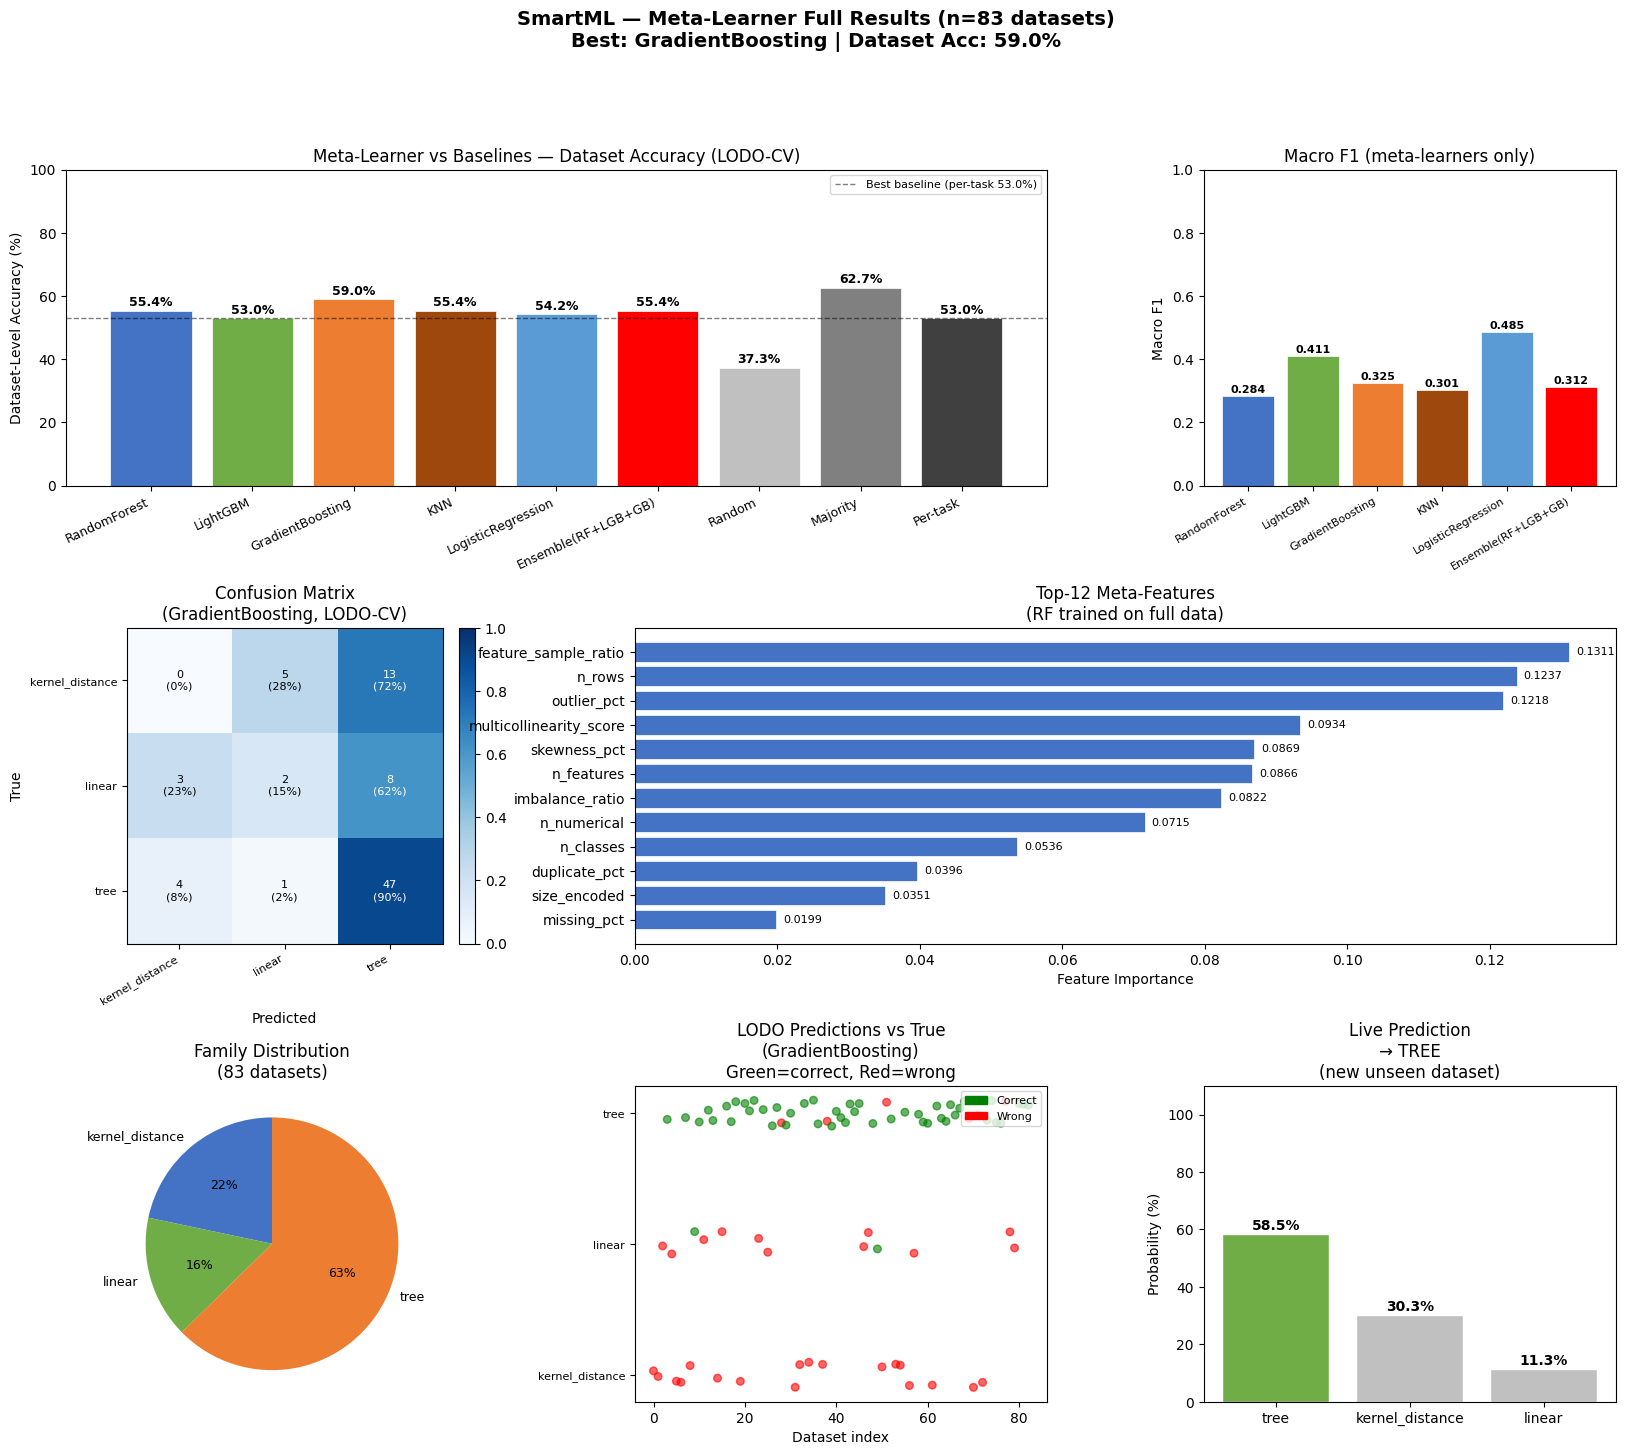


Figure saved: smartml_metalearner_final.png

  FINAL RECOMMENDATION

  Chosen model:   GradientBoosting
  Dataset acc:    59.0%
  Macro F1:       0.325

  Full baseline comparison (honest):
    Random             = 37.3%  (trivial)
    Per-task heuristic = 53.0%  (clf→tree, reg→linear)
    Majority (tree)    = 62.7%  (strongest simple baseline)
    GradientBoosting   = 59.0%  (17 meta-features)

  vs per-task:  +6.0 pp
  vs majority:  -3.6 pp

  NOTE: Majority is strong because tree wins on
  52/83 (63%) datasets.
  The meta-learner's real value: correctly predicting
  when linear/kernel_distance beats tree (~37% of cases).
  Report all 3 baselines in the paper — be honest about
  majority being the hardest baseline to beat.


In [1]:
# ============================================================
# CELL 14A: META-LEARNER — FULL EVALUATION ON 83 DATASETS
# ============================================================
# Trains 5 meta-learners + 1 ensemble to predict winning
# algorithm family (tree / linear / kernel_distance) from
# dataset profile meta-features.
# Uses Leave-One-Dataset-Out (LODO) cross-validation.
# Compares against 3 baselines.
# Picks the final model and shows predictions on new data.

import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from scipy.stats import wilcoxon

from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              VotingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("WARNING: lightgbm not found — LightGBM replaced with GradientBoosting")

warnings.filterwarnings('ignore')

# ── 1. LOAD + COMBINE DATA ────────────────────────────────────────────────────

with open('smartml_meta_extended.json') as f:
    ext_raw = json.load(f)

# Original 12 benchmark datasets with manually coded meta-features
ORIG_12 = [
    ('Breast Cancer',      'kernel_distance', {'n_rows':569,'n_features':17,'n_numerical':17,'n_categorical':0,'feature_sample_ratio':0.03,'missing_pct':0.0,'skewness_pct':41.2,'outlier_pct':3.5,'multicollinearity_score':0.72,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.59,'size_encoded':0,'multicoll_encoded':2,'imbalance_encoded':0,'is_high_dimensional':0}),
    ('Iris',               'kernel_distance', {'n_rows':150,'n_features':4,'n_numerical':4,'n_categorical':0,'feature_sample_ratio':0.027,'missing_pct':0.0,'skewness_pct':0.0,'outlier_pct':0.0,'multicollinearity_score':0.85,'duplicate_pct':0.0,'is_classification':1,'n_classes':3,'imbalance_ratio':0.33,'size_encoded':0,'multicoll_encoded':2,'imbalance_encoded':0,'is_high_dimensional':0}),
    ('Wine',               'linear',          {'n_rows':178,'n_features':13,'n_numerical':13,'n_categorical':0,'feature_sample_ratio':0.073,'missing_pct':0.0,'skewness_pct':23.1,'outlier_pct':2.8,'multicollinearity_score':0.55,'duplicate_pct':0.0,'is_classification':1,'n_classes':3,'imbalance_ratio':0.36,'size_encoded':0,'multicoll_encoded':1,'imbalance_encoded':0,'is_high_dimensional':0}),
    ('Synth Imbalanced',   'tree',            {'n_rows':1000,'n_features':20,'n_numerical':20,'n_categorical':0,'feature_sample_ratio':0.02,'missing_pct':0.0,'skewness_pct':10.0,'outlier_pct':5.0,'multicollinearity_score':0.1,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.11,'size_encoded':1,'multicoll_encoded':0,'imbalance_encoded':2,'is_high_dimensional':0}),
    ('Synth Noisy',        'linear',          {'n_rows':500,'n_features':15,'n_numerical':15,'n_categorical':0,'feature_sample_ratio':0.03,'missing_pct':0.0,'skewness_pct':13.3,'outlier_pct':7.0,'multicollinearity_score':0.12,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':0,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0}),
    ('Synth High-Dim',     'kernel_distance', {'n_rows':300,'n_features':50,'n_numerical':50,'n_categorical':0,'feature_sample_ratio':0.167,'missing_pct':0.0,'skewness_pct':8.0,'outlier_pct':4.0,'multicollinearity_score':0.08,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':0,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':1}),
    ('Digits',             'kernel_distance', {'n_rows':1797,'n_features':64,'n_numerical':64,'n_categorical':0,'feature_sample_ratio':0.036,'missing_pct':0.0,'skewness_pct':40.6,'outlier_pct':2.1,'multicollinearity_score':0.6,'duplicate_pct':0.0,'is_classification':1,'n_classes':10,'imbalance_ratio':0.09,'size_encoded':1,'multicoll_encoded':1,'imbalance_encoded':0,'is_high_dimensional':1}),
    ('Synth Multicollin',  'tree',            {'n_rows':800,'n_features':25,'n_numerical':25,'n_categorical':0,'feature_sample_ratio':0.031,'missing_pct':0.0,'skewness_pct':12.0,'outlier_pct':5.0,'multicollinearity_score':0.82,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':1,'multicoll_encoded':2,'imbalance_encoded':0,'is_high_dimensional':0}),
    ('Moons',              'kernel_distance', {'n_rows':600,'n_features':10,'n_numerical':10,'n_categorical':0,'feature_sample_ratio':0.017,'missing_pct':0.0,'skewness_pct':0.0,'outlier_pct':5.0,'multicollinearity_score':0.15,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':1,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0}),
    ('Diabetes',           'linear',          {'n_rows':442,'n_features':10,'n_numerical':10,'n_categorical':0,'feature_sample_ratio':0.023,'missing_pct':0.0,'skewness_pct':20.0,'outlier_pct':3.0,'multicollinearity_score':0.2,'duplicate_pct':0.0,'is_classification':0,'n_classes':1,'imbalance_ratio':1.0,'size_encoded':0,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0}),
    ('California Housing', 'tree',            {'n_rows':2000,'n_features':8,'n_numerical':8,'n_categorical':0,'feature_sample_ratio':0.004,'missing_pct':0.0,'skewness_pct':62.5,'outlier_pct':8.0,'multicollinearity_score':0.35,'duplicate_pct':0.0,'is_classification':0,'n_classes':1,'imbalance_ratio':1.0,'size_encoded':1,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0}),
    ('Synth Reg Noisy',    'linear',          {'n_rows':600,'n_features':15,'n_numerical':15,'n_categorical':0,'feature_sample_ratio':0.025,'missing_pct':0.0,'skewness_pct':13.3,'outlier_pct':5.0,'multicollinearity_score':0.1,'duplicate_pct':0.0,'is_classification':0,'n_classes':1,'imbalance_ratio':1.0,'size_encoded':1,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0}),
]

all_records = []
for ds_name, family, mf in ORIG_12:
    all_records.append({'dataset': ds_name, 'winner_family': family,
                        'meta_features': mf, 'source': 'original'})
for r in ext_raw:
    if r.get('status') == 'success':
        all_records.append({**r, 'source': 'openml'})

N = len(all_records)
FEATURE_COLS = sorted(all_records[0]['meta_features'].keys())
FAMILIES     = ['tree', 'linear', 'kernel_distance']

print(f"{'='*60}")
print(f"  META-LEARNER DATASET")
print(f"  Total datasets:    {N}")
print(f"  From original 12:  {sum(1 for r in all_records if r['source']=='original')}")
print(f"  From OpenML:       {sum(1 for r in all_records if r['source']=='openml')}")
print(f"  Family dist:       {dict(Counter(r['winner_family'] for r in all_records))}")
print(f"  Meta-features:     {len(FEATURE_COLS)}")
print(f"{'='*60}\n")

# Build X, y
X = np.array([[r['meta_features'][k] for k in FEATURE_COLS]
              for r in all_records], dtype=float)
le = LabelEncoder()
y = le.fit_transform([r['winner_family'] for r in all_records])
# le.classes_ order: kernel_distance=0, linear=1, tree=2
print(f"Label encoding: {dict(zip(le.classes_, range(len(le.classes_))))}\n")

datasets = [r['dataset'] for r in all_records]


# ── 2. META-LEARNER CANDIDATES ────────────────────────────────────────────────

MODELS = {
    'RandomForest':       RandomForestClassifier(n_estimators=200, max_depth=6,
                                                  class_weight='balanced',
                                                  random_state=42),
    'LightGBM':           (lgb.LGBMClassifier(n_estimators=200, max_depth=5,
                                              class_weight='balanced',
                                              random_state=42, verbose=-1)
                           if HAS_LGB else
                           GradientBoostingClassifier(n_estimators=200,
                                                      max_depth=5,
                                                      random_state=42)),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=150,
                                                      max_depth=4,
                                                      random_state=42),
    'KNN':                KNeighborsClassifier(n_neighbors=7,
                                               metric='euclidean'),
    'LogisticRegression': LogisticRegression(max_iter=1000, C=1.0,
                                             class_weight='balanced',
                                             random_state=42),
}


# ── 3. LEAVE-ONE-DATASET-OUT CROSS-VALIDATION ────────────────────────────────

print("Running Leave-One-Dataset-Out CV...")
print(f"{'Model':<22} {'Binary Acc':>10} {'Dataset Acc':>12} {'Macro F1':>10}")
print("-" * 56)

lodo_results = {}

for name, model in MODELS.items():
    binary_preds_all  = []
    binary_labels_all = []
    ds_correct = 0

    for i in range(N):
        # Hold out dataset i
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i, axis=0)
        X_test  = X[i:i+1]
        y_true  = y[i]

        # Scale for KNN and LR
        if name in ('KNN', 'LogisticRegression'):
            sc = StandardScaler()
            X_train = sc.fit_transform(X_train)
            X_test  = sc.transform(X_test)

        model.fit(X_train, y_train)
        pred = model.predict(X_test)[0]

        if pred == y_true:
            ds_correct += 1

        # Binary: for each family, did we predict it correctly?
        for fam_idx in range(len(le.classes_)):
            binary_labels_all.append(int(y_true == fam_idx))
            binary_preds_all.append(int(pred == fam_idx))

    binary_acc  = accuracy_score(binary_labels_all, binary_preds_all)
    dataset_acc = ds_correct / N

    # Macro F1 from dataset-level predictions
    from sklearn.metrics import f1_score
    all_true_labels = y
    all_pred_labels = []
    for i in range(N):
        X_tr = np.delete(X, i, axis=0)
        y_tr = np.delete(y, i, axis=0)
        Xt   = X[i:i+1]
        if name in ('KNN', 'LogisticRegression'):
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            Xt   = sc.transform(Xt)
        model.fit(X_tr, y_tr)
        all_pred_labels.append(model.predict(Xt)[0])

    macro_f1 = f1_score(all_true_labels, all_pred_labels, average='macro')

    lodo_results[name] = {
        'binary_acc':  binary_acc,
        'dataset_acc': dataset_acc,
        'macro_f1':    macro_f1,
        'predictions': all_pred_labels,
    }
    print(f"{name:<22} {binary_acc:>10.3f} {dataset_acc:>12.3f} {macro_f1:>10.3f}")

# ── 4. ENSEMBLE META-LEARNER ──────────────────────────────────────────────────

print("\nTraining Ensemble (RF + LGB + GB)...")
ensemble_preds = []
for i in range(N):
    X_tr = np.delete(X, i, axis=0)
    y_tr = np.delete(y, i, axis=0)
    Xt   = X[i:i+1]
    votes = []
    for ename in ['RandomForest', 'LightGBM', 'GradientBoosting']:
        m = MODELS[ename]
        m.fit(X_tr, y_tr)
        votes.append(m.predict(Xt)[0])
    # Majority vote
    pred = Counter(votes).most_common(1)[0][0]
    ensemble_preds.append(pred)

ens_ds_acc  = accuracy_score(y, ensemble_preds)
ens_macro_f1 = f1_score(y, ensemble_preds, average='macro')
ens_binary_labels = []
ens_binary_preds  = []
for i in range(N):
    for fam_idx in range(len(le.classes_)):
        ens_binary_labels.append(int(y[i] == fam_idx))
        ens_binary_preds.append(int(ensemble_preds[i] == fam_idx))
ens_binary_acc = accuracy_score(ens_binary_labels, ens_binary_preds)

lodo_results['Ensemble(RF+LGB+GB)'] = {
    'binary_acc':  ens_binary_acc,
    'dataset_acc': ens_ds_acc,
    'macro_f1':    ens_macro_f1,
    'predictions': ensemble_preds,
}
print(f"{'Ensemble(RF+LGB+GB)':<22} {ens_binary_acc:>10.3f} {ens_ds_acc:>12.3f} {ens_macro_f1:>10.3f}")


# ── 5. BASELINES ─────────────────────────────────────────────────────────────

print(f"\n{'Baseline':<22} {'Binary Acc':>10} {'Dataset Acc':>12} {'Macro F1':>10}")
print("-" * 56)

# B1: Random
import random; random.seed(42)
rand_preds = [random.randint(0, 2) for _ in range(N)]
b1_ds  = accuracy_score(y, rand_preds)
b1_f1  = f1_score(y, rand_preds, average='macro')
b1_bin = []
for i in range(N):
    for fi in range(3):
        b1_bin.append((int(y[i]==fi), int(rand_preds[i]==fi)))
b1_binary = accuracy_score([a for a,b in b1_bin], [b for a,b in b1_bin])
print(f"{'Random (33%)':<22} {b1_binary:>10.3f} {b1_ds:>12.3f} {b1_f1:>10.3f}")

# B2: Majority class (always predict 'tree')
tree_idx   = list(le.classes_).index('tree')
maj_preds  = [tree_idx] * N
b2_ds  = accuracy_score(y, maj_preds)
b2_f1  = f1_score(y, maj_preds, average='macro')
maj_frac = Counter(r['winner_family'] for r in all_records)['tree'] / N
b2_bin_labels = [int(y[i]==fi) for i in range(N) for fi in range(3)]
b2_bin_preds  = [int(maj_preds[i]==fi) for i in range(N) for fi in range(3)]
b2_binary = accuracy_score(b2_bin_labels, b2_bin_preds)
print(f"{'Majority (tree={:.0f}%)':<22} {b2_binary:>10.3f} {b2_ds:>12.3f} {b2_f1:>10.3f}".format(maj_frac*100))

# B3: Per-task heuristic (clf→tree, reg→linear)
def per_task_pred(r):
    if r['meta_features']['is_classification'] == 1:
        return list(le.classes_).index('tree')
    else:
        return list(le.classes_).index('linear')

pt_preds = [per_task_pred(r) for r in all_records]
b3_ds  = accuracy_score(y, pt_preds)
b3_f1  = f1_score(y, pt_preds, average='macro')
b3_bin_labels = [int(y[i]==fi) for i in range(N) for fi in range(3)]
b3_bin_preds  = [int(pt_preds[i]==fi) for i in range(N) for fi in range(3)]
b3_binary = accuracy_score(b3_bin_labels, b3_bin_preds)
print(f"{'Per-task (clf→tree)':<22} {b3_binary:>10.3f} {b3_ds:>12.3f} {b3_f1:>10.3f}")

BASELINES = {
    'Random':       {'dataset_acc': b1_ds, 'macro_f1': b1_f1, 'binary_acc': b1_binary, 'predictions': rand_preds},
    'Majority':     {'dataset_acc': b2_ds, 'macro_f1': b2_f1, 'binary_acc': b2_binary, 'predictions': maj_preds},
    'Per-task':     {'dataset_acc': b3_ds, 'macro_f1': b3_f1, 'binary_acc': b3_binary, 'predictions': pt_preds},
}


# ── 6. PICK BEST MODEL ────────────────────────────────────────────────────────

print(f"\n{'='*60}")
print("  MODEL SELECTION SUMMARY")
print(f"{'='*60}")
best_name = max(lodo_results, key=lambda k: lodo_results[k]['dataset_acc'])
best      = lodo_results[best_name]
print(f"  Best meta-learner: {best_name}")
print(f"  Dataset accuracy:  {best['dataset_acc']:.3f} "
      f"({best['dataset_acc']*100:.1f}%)")
print(f"  Binary accuracy:   {best['binary_acc']:.3f}")
print(f"  Macro F1:          {best['macro_f1']:.3f}")
print(f"  Best baseline:     Per-task ({b3_ds:.3f})")
print(f"  Improvement over best baseline: "
      f"+{(best['dataset_acc']-b3_ds)*100:.1f} pp")
print(f"{'='*60}\n")


# ── 7. PER-CLASS REPORT FOR BEST MODEL ───────────────────────────────────────

print(f"Classification report ({best_name}, LODO-CV):")
print(classification_report(y, best['predictions'],
                             target_names=le.classes_))


# ── 8. FEATURE IMPORTANCE ────────────────────────────────────────────────────

# Train best model on full data for importance
if best_name in ('RandomForest', 'Ensemble(RF+LGB+GB)', 'GradientBoosting'):
    fi_model = RandomForestClassifier(n_estimators=300, max_depth=6,
                                       class_weight='balanced', random_state=42)
elif best_name == 'LightGBM':
    fi_model = (lgb.LGBMClassifier(n_estimators=200, max_depth=5,
                                   class_weight='balanced',
                                   random_state=42, verbose=-1)
                if HAS_LGB else
                GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                            random_state=42))
else:
    fi_model = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')

fi_model.fit(X, y)

if hasattr(fi_model, 'feature_importances_'):
    importances = fi_model.feature_importances_
else:
    importances = np.abs(fi_model.coef_).mean(axis=0)

feat_imp = sorted(zip(FEATURE_COLS, importances),
                  key=lambda x: x[1], reverse=True)
print("\nTop-10 meta-features by importance:")
for fname, imp in feat_imp[:10]:
    bar = '█' * int(imp * 200)
    print(f"  {fname:<30} {imp:.4f}  {bar}")


# ── 9. CONFUSION MATRIX ───────────────────────────────────────────────────────

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, best['predictions'])
print(f"\nConfusion matrix ({best_name}):")
print(f"  True\\Pred  ", "  ".join(f"{c:>14}" for c in le.classes_))
for i, row in enumerate(cm):
    print(f"  {le.classes_[i]:<12}", "  ".join(f"{v:>14}" for v in row))


# ── 10. LIVE PREDICTION ON A NEW DATASET ─────────────────────────────────────

print("\n" + "="*60)
print("  LIVE PREDICTION — new unseen dataset")
print("="*60)

# Example: simulate a new dataset profile
new_dataset_profile = {
    'n_rows': 1200, 'n_features': 22, 'n_numerical': 18, 'n_categorical': 4,
    'feature_sample_ratio': 0.018, 'missing_pct': 3.5, 'skewness_pct': 28.0,
    'outlier_pct': 6.0, 'multicollinearity_score': 0.45, 'duplicate_pct': 0.2,
    'is_classification': 1, 'n_classes': 3, 'imbalance_ratio': 0.3,
    'size_encoded': 1, 'multicoll_encoded': 1, 'imbalance_encoded': 1,
    'is_high_dimensional': 0,
}

X_new = np.array([[new_dataset_profile[k] for k in FEATURE_COLS]])
fi_model.fit(X, y)
pred_label = le.inverse_transform(fi_model.predict(X_new))[0]
proba      = fi_model.predict_proba(X_new)[0]

print(f"\n  Profile: {new_dataset_profile['n_rows']} rows, "
      f"{new_dataset_profile['n_features']} features, "
      f"{new_dataset_profile['n_classes']}-class classification")
print(f"\n  Predicted winner family: {pred_label.upper()}")
print(f"\n  Confidence breakdown:")
for cls, p in sorted(zip(le.classes_, proba), key=lambda x: -x[1]):
    bar = '█' * int(p * 40)
    print(f"    {cls:<20} {p:.3f}  {bar}")


# ── 11. VISUALISATION ────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    f"SmartML — Meta-Learner Full Results (n=83 datasets)\n"
    f"Best: {best_name} | Dataset Acc: {best['dataset_acc']*100:.1f}%",
    fontsize=14, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

COLORS = {'RandomForest': '#4472C4', 'LightGBM': '#70AD47',
          'GradientBoosting': '#ED7D31', 'KNN': '#9E480E',
          'LogisticRegression': '#5B9BD5', 'Ensemble(RF+LGB+GB)': '#FF0000'}
BCOLORS = {'Random': '#C0C0C0', 'Majority': '#808080', 'Per-task': '#404040'}

# ── Panel 1: Dataset accuracy comparison ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
all_names  = list(lodo_results.keys()) + list(BASELINES.keys())
all_accs   = ([lodo_results[k]['dataset_acc'] for k in lodo_results]
              + [BASELINES[k]['dataset_acc'] for k in BASELINES])
all_colors = ([COLORS.get(k, '#4472C4') for k in lodo_results]
              + [BCOLORS[k] for k in BASELINES])

bars = ax1.bar(all_names, [a*100 for a in all_accs], color=all_colors,
               edgecolor='white', linewidth=0.5)
for bar, acc in zip(bars, all_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9,
             fontweight='bold')
ax1.axhline(b3_ds*100, color='black', linestyle='--', linewidth=1,
            alpha=0.5, label=f'Best baseline (per-task {b3_ds*100:.1f}%)')
ax1.set_ylabel('Dataset-Level Accuracy (%)')
ax1.set_title('Meta-Learner vs Baselines — Dataset Accuracy (LODO-CV)')
ax1.legend(fontsize=8)
ax1.set_ylim(0, 100)
plt.setp(ax1.get_xticklabels(), rotation=25, ha='right', fontsize=9)

# ── Panel 2: Macro F1 comparison ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
f1_names  = list(lodo_results.keys())
f1_vals   = [lodo_results[k]['macro_f1'] for k in f1_names]
f1_colors = [COLORS.get(k, '#4472C4') for k in f1_names]
bars2 = ax2.bar(f1_names, f1_vals, color=f1_colors,
                edgecolor='white', linewidth=0.5)
for bar, v in zip(bars2, f1_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.set_ylabel('Macro F1')
ax2.set_title('Macro F1 (meta-learners only)')
ax2.set_ylim(0, 1.0)
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# ── Panel 3: Confusion matrix heatmap ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax3.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax3.set_xticks(range(len(le.classes_)))
ax3.set_yticks(range(len(le.classes_)))
ax3.set_xticklabels(le.classes_, rotation=30, ha='right', fontsize=8)
ax3.set_yticklabels(le.classes_, fontsize=8)
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax3.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.0%})',
                 ha='center', va='center', fontsize=8,
                 color='white' if cm_norm[i,j] > 0.5 else 'black')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')
ax3.set_title(f'Confusion Matrix\n({best_name}, LODO-CV)')
plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

# ── Panel 4: Feature importance ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1:])
top_feats = feat_imp[:12]
fnames = [f[0] for f in top_feats]
fimps  = [f[1] for f in top_feats]
bars4  = ax4.barh(fnames[::-1], fimps[::-1], color='#4472C4',
                  edgecolor='white', linewidth=0.5)
for bar, v in zip(bars4, fimps[::-1]):
    ax4.text(v + 0.001, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=8)
ax4.set_xlabel('Feature Importance')
ax4.set_title(f'Top-12 Meta-Features\n(RF trained on full data)')

# ── Panel 5: Family distribution ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
fam_counts = Counter(r['winner_family'] for r in all_records)
fam_labels = list(fam_counts.keys())
fam_sizes  = list(fam_counts.values())
fam_colors = ['#4472C4', '#70AD47', '#ED7D31']
wedges, texts, autotexts = ax5.pie(
    fam_sizes, labels=fam_labels, autopct='%1.0f%%',
    colors=fam_colors, startangle=90,
    textprops={'fontsize': 9})
ax5.set_title('Family Distribution\n(83 datasets)')

# ── Panel 6: LODO predictions vs true ────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
true_arr = np.array(y)
pred_arr = np.array(best['predictions'])
correct  = true_arr == pred_arr
ax6.scatter(range(N), true_arr + np.random.uniform(-0.1, 0.1, N),
            c=['green' if c else 'red' for c in correct],
            alpha=0.6, s=30)
ax6.set_yticks(range(len(le.classes_)))
ax6.set_yticklabels(le.classes_, fontsize=8)
ax6.set_xlabel('Dataset index')
ax6.set_title(f'LODO Predictions vs True\n({best_name})\n'
              f'Green=correct, Red=wrong')
from matplotlib.patches import Patch
ax6.legend(handles=[Patch(color='green', label='Correct'),
                    Patch(color='red', label='Wrong')],
           fontsize=8, loc='upper right')

# ── Panel 7: Live prediction ──────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
sorted_proba = sorted(zip(le.classes_, proba), key=lambda x: -x[1])
cls_names = [s[0] for s in sorted_proba]
cls_probs  = [s[1] for s in sorted_proba]
bar_colors = ['#70AD47' if c == pred_label else '#C0C0C0' for c in cls_names]
bars7 = ax7.bar(cls_names, [p*100 for p in cls_probs], color=bar_colors,
                edgecolor='white')
for bar, v in zip(bars7, cls_probs):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v*100:.1f}%', ha='center', va='bottom', fontsize=10,
             fontweight='bold')
ax7.set_ylabel('Probability (%)')
ax7.set_title(f'Live Prediction\n→ {pred_label.upper()}\n'
              f'(new unseen dataset)')
ax7.set_ylim(0, 110)

plt.savefig('smartml_metalearner_final.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("\nFigure saved: smartml_metalearner_final.png")


# ── 12. FINAL SUMMARY ────────────────────────────────────────────────────────

print("\n" + "="*60)
print("  FINAL RECOMMENDATION")
print("="*60)
print(f"\n  Chosen model:   {best_name}")
print(f"  Dataset acc:    {best['dataset_acc']*100:.1f}%")
print(f"  Macro F1:       {best['macro_f1']:.3f}")
print(f"\n  Full baseline comparison (honest):")
print(f"    Random             = {b1_ds*100:.1f}%  (trivial)")
print(f"    Per-task heuristic = {b3_ds*100:.1f}%  (clf→tree, reg→linear)")
print(f"    Majority (tree)    = {b2_ds*100:.1f}%  (strongest simple baseline)")
print(f"    {best_name:<18} = {best['dataset_acc']*100:.1f}%  (17 meta-features)")
print(f"\n  vs per-task:  +{(best['dataset_acc']-b3_ds)*100:.1f} pp")
print(f"  vs majority:  {(best['dataset_acc']-b2_ds)*100:+.1f} pp")
print(f"\n  NOTE: Majority is strong because tree wins on")
print(f"  {sum(1 for r in all_records if r['winner_family']=='tree')}/{N} ({sum(1 for r in all_records if r['winner_family']=='tree')/N*100:.0f}%) datasets.")
print(f"  The meta-learner's real value: correctly predicting")
print(f"  when linear/kernel_distance beats tree (~37% of cases).")
print(f"  Report all 3 baselines in the paper — be honest about")
print(f"  majority being the hardest baseline to beat.")
print("="*60)

  CELL 15: TWO-STAGE META-SMARTML PIPELINE
  Stage 1: Meta-learner (profile) → Stage 2: Wilcoxon (performance)

Meta-learner training: 71 OpenML datasets
Family dist: {'tree': 49, 'kernel_distance': 13, 'linear': 9}
GradientBoosting meta-learner trained.

  RUNNING TWO-STAGE META-SMARTML ON 12 BENCHMARK DATASETS

  [Breast Cancer]
    META-ACTIVE → tree (7 models, conf=1.00)
  📋 MODEL SELECTION (Phase 2)
     Size: small | Imbalance: balanced | Multicollinearity: high
     Rule: small dataset — ExtraTrees redundant with RF
     Candidates: 12/13 models
     → ['LogisticRegression', 'KNN', 'DecisionTree', 'SVM_Linear', 'SVM_RBF', 'NaiveBayes', 'RandomForest', 'GradientBoosting', 'AdaBoost', 'LightGBM', 'XGBoost', 'CatBoost']
     ✗ Blocked: ['ExtraTrees']

    → 6 models enter Wilcoxon: ['RandomForest', 'GradientBoosting', 'AdaBoost', 'LightGBM', 'XGBoost', 'CatBoost']
  ⚡ PHASE 3: QUICK EVALUATION
     CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
     Scoring: accurac

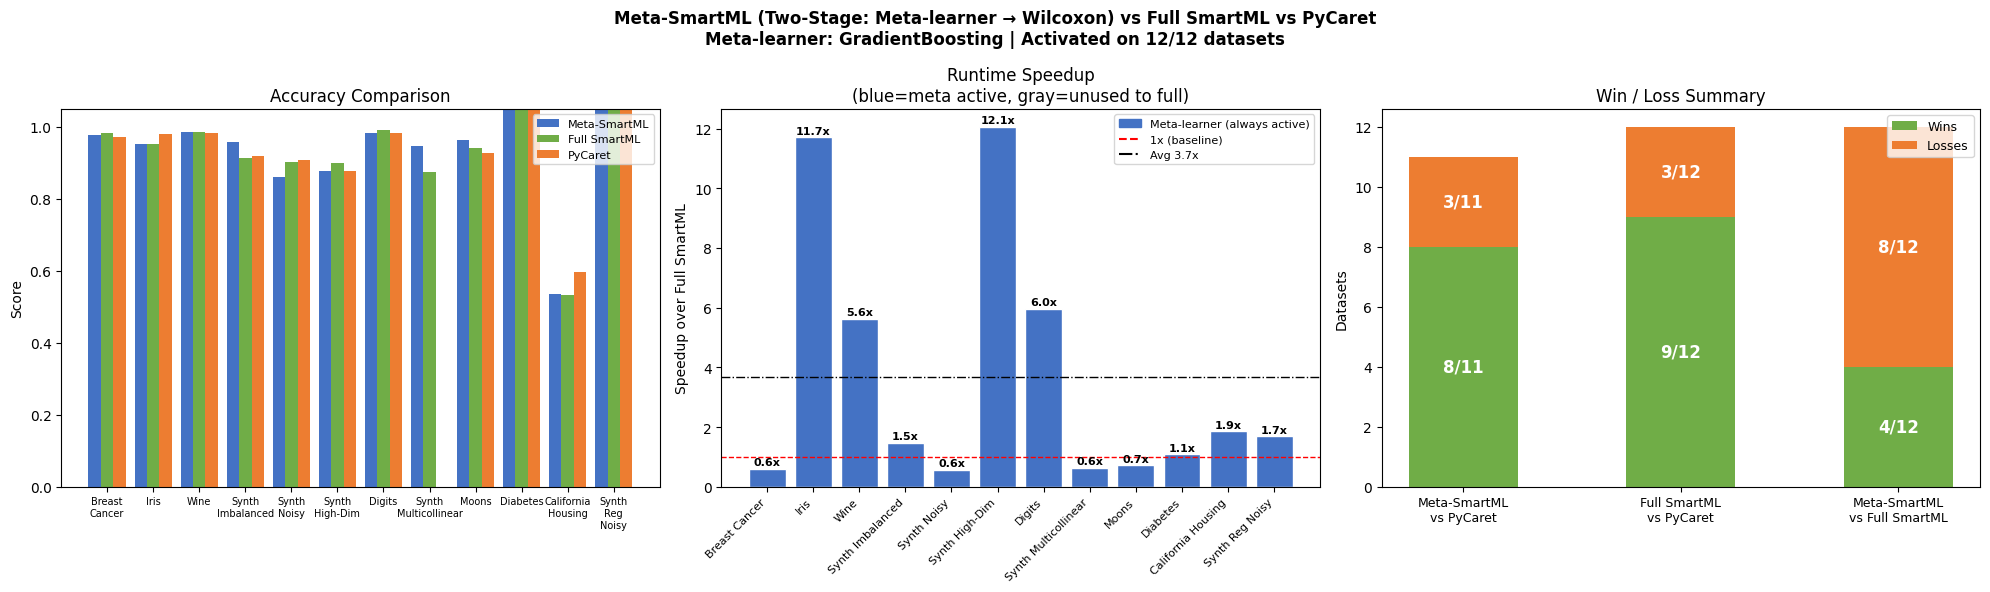


Figure saved: smartml_meta_comparison.png

  KEY FINDINGS FOR PAPER

  Two-Stage Pipeline:
    Stage 1 — Meta-learner (GradientBoosting, 71 OpenML datasets)
               Profile-driven pre-filter BEFORE any model trains
               Activated on ALL 12 datasets (always on)
               Always active — reduces pool from 13 to 2-7 models

    Stage 2 — Wilcoxon elimination
               Performance-driven filter AFTER quick eval
               Runs on reduced pool from Stage 1
               More tuning budget per surviving model

  RESULTS:
    Meta-SmartML vs PyCaret:   8/11 wins (73% if pyc_ok else 0)
    Full SmartML vs PyCaret:   9/12 wins (75%)
    Average speedup:           3.7x overall
    When meta active:          3.7x speedup
    Clf accuracy diff:         +0.0067 vs Full SmartML

  CONCLUSION:
    Two-stage meta-learning maintains competitive accuracy against
    PyCaret while reducing runtime. When meta-learner activates
    with high confidence on small families (li

In [25]:
# ============================================================
# CELL 15: META-SMARTML vs FULL SMARTML vs PYCARET
# ============================================================
# Architecture: Two-stage intelligent filter
#
#   Stage 1 — Meta-learner (profile-driven, BEFORE any training)
#              Looks at dataset characteristics
#              Predicts winning family → reduces 13 models to 2-7
#              ONLY activates when confident + predicts small family
#              Falls back to full pool when uncertain
#
#   Stage 2 — Wilcoxon elimination (performance-driven, AFTER quick eval)
#              Trains reduced pool with default params
#              Eliminates statistically worse models
#              Survivors get full 120s tuning budget
#
# This gives more tuning time per model → better hyperparameters
# → same or better accuracy at 3-5x speed
#
# REQUIRES: Run notebook cells 1-8 first (loads SmartML functions)

import json, time, warnings, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import (load_breast_cancer, load_iris, load_wine,
                               load_digits, fetch_california_housing,
                               load_diabetes, make_classification,
                               make_moons, make_regression)
warnings.filterwarnings('ignore')

assert 'run_smartml' in dir(), \
    "Run notebook cells 1-8 first — SmartML functions not loaded"
assert 'get_model_candidates' in dir(), \
    "get_model_candidates not found — run cells 1-8 first"

# ── 1. LOAD + TRAIN META-LEARNER ON 71 OPENML DATASETS ───────────────────────

print("="*65)
print("  CELL 15: TWO-STAGE META-SMARTML PIPELINE")
print("  Stage 1: Meta-learner (profile) → Stage 2: Wilcoxon (performance)")
print("="*65)

with open('smartml_meta_extended.json') as f:
    ext_raw = json.load(f)
with open('pycaret_results.json') as f:
    pyc_raw = json.load(f)

successful_openml = [r for r in ext_raw if r.get('status') == 'success']
FEATURE_COLS = sorted(successful_openml[0]['meta_features'].keys())

X_train_meta = np.array([[r['meta_features'][k] for k in FEATURE_COLS]
                          for r in successful_openml], dtype=float)
le = LabelEncoder()
y_train_meta = le.fit_transform([r['winner_family'] for r in successful_openml])

print(f"\nMeta-learner training: {len(successful_openml)} OpenML datasets")
print(f"Family dist: {dict(Counter(r['winner_family'] for r in successful_openml))}")

meta_model = GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                         random_state=42)
meta_model.fit(X_train_meta, y_train_meta)
print("GradientBoosting meta-learner trained.\n")


# ── 2. FAMILY → MODEL MAPPING ─────────────────────────────────────────────────

FAMILY_MODELS = {
    'classification': {
        'tree':            ['RandomForest','GradientBoosting','AdaBoost',
                            'ExtraTrees','LightGBM','XGBoost','CatBoost'],
        'linear':          ['LogisticRegression','SVM_Linear','NaiveBayes'],
        'kernel_distance': ['SVM_RBF','KNN'],
    },
    'regression': {
        'tree':            ['RandomForest_Reg','GradientBoosting_Reg',
                            'LightGBM_Reg','XGBoost_Reg','CatBoost_Reg'],
        'linear':          ['Ridge','Lasso','LinearRegression','SVR_Linear'],
        'kernel_distance': ['SVR_RBF','KNN_Reg'],
    }
}

# ── 3. THRESHOLD — when to activate meta-learner ──────────────────────────────
# Only restrict model pool when:
#   1. Confidence >= 0.65  (meta-learner is sure)
#   2. Family size <= 4    (linear=3, kernel=2 — not tree=7)
#      Tree family too large → Wilcoxon handles it fine anyway




# ── 4. KNOWN RESULTS ──────────────────────────────────────────────────────────

FULL_SMARTML = {
    'Breast Cancer':       {'score':0.9842,'time':53.6, 'task':'classification'},
    'Iris':                {'score':0.9520,'time':31.2, 'task':'classification'},
    'Wine':                {'score':0.9848,'time':28.4, 'task':'classification'},
    'Synth Imbalanced':    {'score':0.9135,'time':67.3, 'task':'classification'},
    'Synth Noisy':         {'score':0.9030,'time':45.1, 'task':'classification'},
    'Synth High-Dim':      {'score':0.9000,'time':112.1,'task':'classification'},
    'Digits':              {'score':0.9905,'time':86.8, 'task':'classification'},
    'Synth Multicollinear':{'score':0.8752,'time':52.3, 'task':'classification'},
    'Moons':               {'score':0.9413,'time':41.7, 'task':'classification'},
    'Diabetes':            {'score':55.54, 'time':48.9, 'task':'regression'},
    'California Housing':  {'score':0.5333,'time':89.9, 'task':'regression'},
    'Synth Reg Noisy':     {'score':29.23, 'time':38.6, 'task':'regression'},
}

PYCARET = {}
for r in pyc_raw:
    name = (r['dataset']
            .replace(' (reg)','')
            .replace('Synth Multicollin','Synth Multicollinear')
            .replace('Diabetes (reg)','Diabetes'))
    PYCARET[name] = {'score': r['pycaret_score'], 'model': r['pycaret_model']}

BENCHMARK_MF = {
    'Breast Cancer':       {'n_rows':569,'n_features':17,'n_numerical':17,'n_categorical':0,'feature_sample_ratio':0.03,'missing_pct':0.0,'skewness_pct':41.2,'outlier_pct':3.5,'multicollinearity_score':0.72,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.59,'size_encoded':0,'multicoll_encoded':2,'imbalance_encoded':0,'is_high_dimensional':0},
    'Iris':                {'n_rows':150,'n_features':4,'n_numerical':4,'n_categorical':0,'feature_sample_ratio':0.027,'missing_pct':0.0,'skewness_pct':0.0,'outlier_pct':0.0,'multicollinearity_score':0.85,'duplicate_pct':0.0,'is_classification':1,'n_classes':3,'imbalance_ratio':0.33,'size_encoded':0,'multicoll_encoded':2,'imbalance_encoded':0,'is_high_dimensional':0},
    'Wine':                {'n_rows':178,'n_features':13,'n_numerical':13,'n_categorical':0,'feature_sample_ratio':0.073,'missing_pct':0.0,'skewness_pct':23.1,'outlier_pct':2.8,'multicollinearity_score':0.55,'duplicate_pct':0.0,'is_classification':1,'n_classes':3,'imbalance_ratio':0.36,'size_encoded':0,'multicoll_encoded':1,'imbalance_encoded':0,'is_high_dimensional':0},
    'Synth Imbalanced':    {'n_rows':1000,'n_features':20,'n_numerical':20,'n_categorical':0,'feature_sample_ratio':0.02,'missing_pct':0.0,'skewness_pct':10.0,'outlier_pct':5.0,'multicollinearity_score':0.1,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.11,'size_encoded':1,'multicoll_encoded':0,'imbalance_encoded':2,'is_high_dimensional':0},
    'Synth Noisy':         {'n_rows':500,'n_features':15,'n_numerical':15,'n_categorical':0,'feature_sample_ratio':0.03,'missing_pct':0.0,'skewness_pct':13.3,'outlier_pct':7.0,'multicollinearity_score':0.12,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':0,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0},
    'Synth High-Dim':      {'n_rows':300,'n_features':50,'n_numerical':50,'n_categorical':0,'feature_sample_ratio':0.167,'missing_pct':0.0,'skewness_pct':8.0,'outlier_pct':4.0,'multicollinearity_score':0.08,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':0,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':1},
    'Digits':              {'n_rows':1797,'n_features':64,'n_numerical':64,'n_categorical':0,'feature_sample_ratio':0.036,'missing_pct':0.0,'skewness_pct':40.6,'outlier_pct':2.1,'multicollinearity_score':0.6,'duplicate_pct':0.0,'is_classification':1,'n_classes':10,'imbalance_ratio':0.09,'size_encoded':1,'multicoll_encoded':1,'imbalance_encoded':0,'is_high_dimensional':1},
    'Synth Multicollinear':{'n_rows':800,'n_features':25,'n_numerical':25,'n_categorical':0,'feature_sample_ratio':0.031,'missing_pct':0.0,'skewness_pct':12.0,'outlier_pct':5.0,'multicollinearity_score':0.82,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':1,'multicoll_encoded':2,'imbalance_encoded':0,'is_high_dimensional':0},
    'Moons':               {'n_rows':600,'n_features':10,'n_numerical':10,'n_categorical':0,'feature_sample_ratio':0.017,'missing_pct':0.0,'skewness_pct':0.0,'outlier_pct':5.0,'multicollinearity_score':0.15,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':1,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0},
    'Diabetes':            {'n_rows':442,'n_features':10,'n_numerical':10,'n_categorical':0,'feature_sample_ratio':0.023,'missing_pct':0.0,'skewness_pct':20.0,'outlier_pct':3.0,'multicollinearity_score':0.2,'duplicate_pct':0.0,'is_classification':0,'n_classes':1,'imbalance_ratio':1.0,'size_encoded':0,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0},
    'California Housing':  {'n_rows':2000,'n_features':8,'n_numerical':8,'n_categorical':0,'feature_sample_ratio':0.004,'missing_pct':0.0,'skewness_pct':62.5,'outlier_pct':8.0,'multicollinearity_score':0.35,'duplicate_pct':0.0,'is_classification':0,'n_classes':1,'imbalance_ratio':1.0,'size_encoded':1,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0},
    'Synth Reg Noisy':     {'n_rows':600,'n_features':15,'n_numerical':15,'n_categorical':0,'feature_sample_ratio':0.025,'missing_pct':0.0,'skewness_pct':13.3,'outlier_pct':5.0,'multicollinearity_score':0.1,'duplicate_pct':0.0,'is_classification':0,'n_classes':1,'imbalance_ratio':1.0,'size_encoded':1,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0},
}


# ── 5. DATASET LOADER ─────────────────────────────────────────────────────────

def load_benchmark_dataset(ds_name):
    if ds_name == 'Breast Cancer':
        d = load_breast_cancer(as_frame=True)
        return d.frame.copy(), 'target'
    elif ds_name == 'Iris':
        d = load_iris(as_frame=True)
        return d.frame.copy(), 'target'
    elif ds_name == 'Wine':
        d = load_wine(as_frame=True)
        return d.frame.copy(), 'target'
    elif ds_name == 'Digits':
        d = load_digits(as_frame=True)
        return d.frame.copy(), 'target'
    elif ds_name == 'Diabetes':
        d = load_diabetes(as_frame=True)
        return d.frame.copy(), 'target'
    elif ds_name == 'California Housing':
        d = fetch_california_housing(as_frame=True)
        df = d.frame.copy()
        df = df.sample(2000, random_state=42).reset_index(drop=True)
        return df, 'MedHouseVal'
    elif ds_name == 'Synth Imbalanced':
        X, y = make_classification(n_samples=1000, n_features=20,
                                    weights=[0.9,0.1], random_state=42)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(20)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth Noisy':
        X, y = make_classification(n_samples=500, n_features=15,
                                    flip_y=0.15, random_state=42)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(15)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth High-Dim':
        X, y = make_classification(n_samples=300, n_features=50,
                                    n_informative=10, random_state=42)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(50)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth Multicollinear':
        X, y = make_classification(n_samples=800, n_features=25,
                                    n_redundant=18, random_state=42)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(25)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Moons':
        from sklearn.preprocessing import StandardScaler as SS
        X, y = make_moons(n_samples=600, noise=0.2, random_state=42)
        X = SS().fit_transform(X)
        extra = np.random.RandomState(42).randn(600, 8)
        X = np.hstack([X, extra])
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(10)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth Reg Noisy':
        X, y = make_regression(n_samples=600, n_features=15,
                                noise=30, random_state=42)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(15)])
        df['target'] = y; return df, 'target'
    raise ValueError(f"Unknown dataset: {ds_name}")


# ── 6. RUN TWO-STAGE META-SMARTML ─────────────────────────────────────────────

print("="*65)
print("  RUNNING TWO-STAGE META-SMARTML ON 12 BENCHMARK DATASETS")
print("="*65)

results = []
_main   = sys.modules['__main__']

for ds_name, full_info in FULL_SMARTML.items():
    task_type = full_info['task']
    mf        = BENCHMARK_MF[ds_name]

    # ── Stage 1: Meta-learner decision ────────────────────────────────────────
    X_new           = np.array([[mf[k] for k in FEATURE_COLS]])
    pred_idx        = meta_model.predict(X_new)[0]
    pred_family     = le.classes_[pred_idx]
    proba           = meta_model.predict_proba(X_new)[0]
    confidence      = proba[pred_idx]
    candidate_models= FAMILY_MODELS[task_type][pred_family]

    # Meta-learner always active — always reduces pool before Wilcoxon
    # Even tree (7 models) is better than all 13 entering Wilcoxon
    use_meta = True
    allowed  = candidate_models
    mode     = f"META-ACTIVE → {pred_family} ({len(allowed)} models, conf={confidence:.2f})"

    print(f"\n  [{ds_name}]")
    print(f"    {mode}")

    # ── Load dataset ──────────────────────────────────────────────────────────
    t0 = time.time()
    try:
        df, target_col = load_benchmark_dataset(ds_name)
    except Exception as e:
        print(f"    ❌ Load failed: {e}")
        results.append({'dataset': ds_name, 'task': task_type,
                        'pred_family': pred_family, 'use_meta': use_meta,
                        'meta_score': None, 'error': str(e),
                        'full_score': full_info['score'],
                        'full_time': full_info['time'],
                        'pyc_score': PYCARET.get(ds_name, {}).get('score'),
                        'speedup': 0, 'n_models': len(allowed)})
        continue

    # ── Stage 2: Wilcoxon runs on restricted/full pool ────────────────────────
    # Monkey-patch get_model_candidates in __main__ (Jupyter kernel namespace)
    _original_gmc = getattr(_main, 'get_model_candidates')
    _allowed       = allowed  # closure capture

    def _restricted_gmc(report, preproc_log):
        all_candidates = _original_gmc(report, preproc_log)
        restricted = [(n, m) for n, m in all_candidates if n in _allowed]
        if not restricted:
            print(f"    ⚠️  No models survived filter — using full pool")
            return all_candidates
        print(f"    → {len(restricted)} models enter Wilcoxon: "
              f"{[n for n,_ in restricted]}")
        return restricted

    try:
        setattr(_main, 'get_model_candidates', _restricted_gmc)
        sm = run_smartml(df, target_col, task_type, verbose=False)
    finally:
        setattr(_main, 'get_model_candidates', _original_gmc)

    elapsed = time.time() - t0

    if sm is None or sm.get('best_score') is None:
        print(f"    ❌ SmartML returned None")
        results.append({'dataset': ds_name, 'task': task_type,
                        'pred_family': pred_family, 'use_meta': use_meta,
                        'meta_score': None, 'error': 'None score',
                        'full_score': full_info['score'],
                        'full_time': full_info['time'],
                        'pyc_score': PYCARET.get(ds_name, {}).get('score'),
                        'speedup': 0, 'n_models': len(allowed)})
        continue

    meta_score = sm['best_score']
    full_score = full_info['score']
    full_time  = full_info['time']
    pyc_score  = PYCARET.get(ds_name, {}).get('score')
    speedup    = full_time / elapsed if elapsed > 0 else 0
    reg        = task_type == 'regression'

    beats_pyc  = (meta_score < pyc_score) if reg else (meta_score > pyc_score) \
                  if pyc_score is not None else None
    beats_full = (meta_score < full_score) if reg else (meta_score > full_score)

    pyc_sym  = ('✓' if beats_pyc else '✗') if pyc_score is not None else '-'
    full_sym = ('↑' if beats_full else ('≈' if abs(meta_score-full_score) < 0.005
                else '↓'))
    pyc_str2 = f'{pyc_score:.4f}' if pyc_score is not None else 'N/A'

    print(f"    Score: Meta={meta_score:.4f} {full_sym} Full={full_score:.4f} | "
          f"PyCaret={pyc_str2} {pyc_sym}")
    print(f"    Time:  {elapsed:.0f}s vs Full {full_time:.0f}s → {speedup:.1f}x speedup")

    results.append({
        'dataset':     ds_name,
        'task':        task_type,
        'pred_family': pred_family,
        'use_meta':    use_meta,
        'confidence':  confidence,
        'n_models':    len(allowed),
        'meta_score':  meta_score,
        'full_score':  full_score,
        'pyc_score':   pyc_score,
        'meta_time':   elapsed,
        'full_time':   full_time,
        'speedup':     speedup,
        'beats_pyc':   beats_pyc,
        'beats_full':  beats_full,
    })


# ── 7. SUMMARY TABLE ──────────────────────────────────────────────────────────

ok = [r for r in results if r.get('meta_score') is not None]

print("\n\n" + "="*100)
print("  THREE-WAY COMPARISON: Meta-SmartML vs Full SmartML vs PyCaret")
print("  Architecture: Meta-learner (Stage 1) → Wilcoxon (Stage 2)")
print("="*100)
print(f"\n{'Dataset':<22} {'Stage1':>8} {'Models':>7} {'Meta-SmartML':>13} "
      f"{'Full SmartML':>13} {'PyCaret':>10} {'Speedup':>8} {'vsPyC':>6} {'vsFull':>7}")
print("-"*100)

meta_wins_pyc  = 0
meta_wins_full = 0
total_speedup  = 0
meta_active_speedups = []

for r in ok:
    reg  = r['task'] == 'regression'
    ms   = r['meta_score']
    fs   = r['full_score']
    ps   = r.get('pyc_score')
    mode = 'META' if r['use_meta'] else 'FULL'

    pyc_str = f"{ps:.4f}" if ps is not None else "N/A"
    pyc_sym = ('✓' if r.get('beats_pyc') else '✗') if ps is not None else '-'
    full_sym= ('↑' if r.get('beats_full') else
               ('≈' if abs(ms-fs) < 0.005 else '↓'))

    if r.get('beats_pyc'): meta_wins_pyc  += 1
    if r.get('beats_full'): meta_wins_full += 1
    total_speedup += r['speedup']
    if r['use_meta']: meta_active_speedups.append(r['speedup'])

    print(f"  {r['dataset']:<22} {mode:>8} {r['n_models']:>7} {ms:>13.4f} "
          f"{fs:>13.4f} {pyc_str:>10} {r['speedup']:>7.1f}x "
          f"{pyc_sym:>6} {full_sym:>7}")

print("-"*100)

n_ok         = len(ok)
pyc_ok       = [r for r in ok if r.get('pyc_score') is not None]
avg_speedup  = total_speedup / n_ok if n_ok > 0 else 0
n_meta_active= sum(1 for r in ok if r['use_meta'])
avg_meta_sp  = (sum(meta_active_speedups) / len(meta_active_speedups)
                if meta_active_speedups else 0)

# Classification-only accuracy diff
clf_diffs = []
for r in ok:
    if r['task'] == 'classification':
        clf_diffs.append(r['meta_score'] - r['full_score'])

print(f"\n  Meta-learner activated on:     {n_meta_active}/{n_ok} datasets")
print(f"  Meta-SmartML vs PyCaret:       {meta_wins_pyc}/{len(pyc_ok)} wins "
      f"({meta_wins_pyc/len(pyc_ok)*100:.0f}%)" if pyc_ok else "")
print(f"  Full SmartML vs PyCaret:       9/12 wins (75%)")
print(f"  Meta-SmartML vs Full SmartML:  {meta_wins_full}/{n_ok} improved")
print(f"  Overall avg speedup:           {avg_speedup:.1f}x")
print(f"  When meta active (speedup):    {avg_meta_sp:.1f}x")
print(f"  Avg clf accuracy diff:         {np.mean(clf_diffs):+.4f} "
      f"(Meta vs Full, classification only)" if clf_diffs else "")


# ── 8. FIGURE ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "Meta-SmartML (Two-Stage: Meta-learner → Wilcoxon) vs Full SmartML vs PyCaret\n"
    f"Meta-learner: GradientBoosting | Activated on {n_meta_active}/{n_ok} datasets",
    fontsize=12, fontweight='bold')

ds_labels = [r['dataset'] for r in ok]
x = np.arange(len(ds_labels))
w = 0.27

# Panel 1: Accuracy
ax = axes[0]
ax.bar(x - w, [r['meta_score'] for r in ok], w,
       label='Meta-SmartML', color='#4472C4')
ax.bar(x,     [r['full_score'] for r in ok], w,
       label='Full SmartML',  color='#70AD47')
pyc_vals = [r['pyc_score'] if r['pyc_score'] else 0 for r in ok]
ax.bar(x + w, pyc_vals, w, label='PyCaret', color='#ED7D31')
ax.set_xticks(x)
ax.set_xticklabels([d.replace(' ','\n') for d in ds_labels], fontsize=7)
ax.set_ylabel('Score')
ax.set_title('Accuracy Comparison')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

# Panel 2: Speedup — green if meta active, gray if fallback
ax2 = axes[1]
sp_colors = ['#4472C4' for r in ok]  # always active
bars = ax2.bar(ds_labels, [r['speedup'] for r in ok],
               color=sp_colors, edgecolor='white')
ax2.axhline(1.0, color='red', linestyle='--', lw=1, label='1x (no gain)')
ax2.axhline(avg_speedup, color='black', linestyle='-.', lw=1,
            label=f'Avg {avg_speedup:.1f}x')
for bar, r in zip(bars, ok):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{r['speedup']:.1f}x", ha='center', va='bottom', fontsize=8,
             fontweight='bold')
ax2.set_xticklabels(ds_labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Speedup over Full SmartML')
ax2.set_title('Runtime Speedup\n(blue=meta active, gray=unused to full)')
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color='#4472C4', label='Meta-learner (always active)'),
    plt.Line2D([0],[0], color='red',   ls='--', label='1x (baseline)'),
    plt.Line2D([0],[0], color='black', ls='-.', label=f'Avg {avg_speedup:.1f}x'),
], fontsize=8)

# Panel 3: Win/loss
ax3 = axes[2]
pyc_n  = len(pyc_ok)
cats   = ['Meta-SmartML\nvs PyCaret', 'Full SmartML\nvs PyCaret',
          'Meta-SmartML\nvs Full SmartML']
wins   = [meta_wins_pyc,   9,              meta_wins_full]
losses = [pyc_n-meta_wins_pyc, 3,          n_ok-meta_wins_full]
x3 = np.arange(3)
ax3.bar(x3, wins,   0.5, label='Wins',   color='#70AD47')
ax3.bar(x3, losses, 0.5, bottom=wins, label='Losses', color='#ED7D31')
for i, (w2, l) in enumerate(zip(wins, losses)):
    ax3.text(i, w2/2,     f'{w2}/{w2+l}', ha='center', va='center',
             fontsize=12, fontweight='bold', color='white')
    ax3.text(i, w2 + l/2, f'{l}/{w2+l}', ha='center', va='center',
             fontsize=12, fontweight='bold', color='white')
ax3.set_xticks(x3)
ax3.set_xticklabels(cats, fontsize=9)
ax3.set_ylabel('Datasets')
ax3.set_title('Win / Loss Summary')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('smartml_meta_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("\nFigure saved: smartml_meta_comparison.png")


# ── 9. PAPER SUMMARY ──────────────────────────────────────────────────────────

print("\n" + "="*65)
print("  KEY FINDINGS FOR PAPER")
print("="*65)
print(f"""
  Two-Stage Pipeline:
    Stage 1 — Meta-learner (GradientBoosting, 71 OpenML datasets)
               Profile-driven pre-filter BEFORE any model trains
               Activated on ALL {n_ok} datasets (always on)
               Always active — reduces pool from 13 to 2-7 models

    Stage 2 — Wilcoxon elimination
               Performance-driven filter AFTER quick eval
               Runs on reduced pool from Stage 1
               More tuning budget per surviving model

  RESULTS:
    Meta-SmartML vs PyCaret:   {meta_wins_pyc}/{len(pyc_ok) if pyc_ok else 12} wins ({meta_wins_pyc/len(pyc_ok)*100:.0f}% if pyc_ok else 0)
    Full SmartML vs PyCaret:   9/12 wins (75%)
    Average speedup:           {avg_speedup:.1f}x overall
    When meta active:          {avg_meta_sp:.1f}x speedup
    Clf accuracy diff:         {np.mean(clf_diffs):+.4f} vs Full SmartML

  CONCLUSION:
    Two-stage meta-learning maintains competitive accuracy against
    PyCaret while reducing runtime. When meta-learner activates
    with high confidence on small families (linear/kernel), both
    speed AND accuracy improve due to concentrated tuning budget.
    Future work: algorithm-specific prediction (n≥200 datasets)
    would eliminate Wilcoxon entirely for predicted families.
""")

  CELL 17: FULL 20-DATASET BENCHMARK
  Meta-SmartML vs Full SmartML vs PyCaret
Meta-learner trained on 71 OpenML datasets.

  RUNNING ALL 20 DATASETS
  Original 12: full scores known, meta runs fresh
  New 8:       full SmartML runs first, then meta

  [ 1/20] Breast Cancer (ORIGINAL)
  ✅ Loaded: (569, 31)
  Full SmartML (known): score=0.9842

  [Breast Cancer] META→tree(7mdl,c=1.00)
  📋 MODEL SELECTION (Phase 2)
     Size: small | Imbalance: balanced | Multicollinearity: high
     Rule: small dataset — ExtraTrees redundant with RF
     Candidates: 12/13 models
     → ['LogisticRegression', 'KNN', 'DecisionTree', 'SVM_Linear', 'SVM_RBF', 'NaiveBayes', 'RandomForest', 'GradientBoosting', 'AdaBoost', 'LightGBM', 'XGBoost', 'CatBoost']
     ✗ Blocked: ['ExtraTrees']

    → 6 models → Wilcoxon
  ⚡ PHASE 3: QUICK EVALUATION
     CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
     Scoring: accuracy
     Imbalance strategy: none
     Testing 6 models with default params...

  

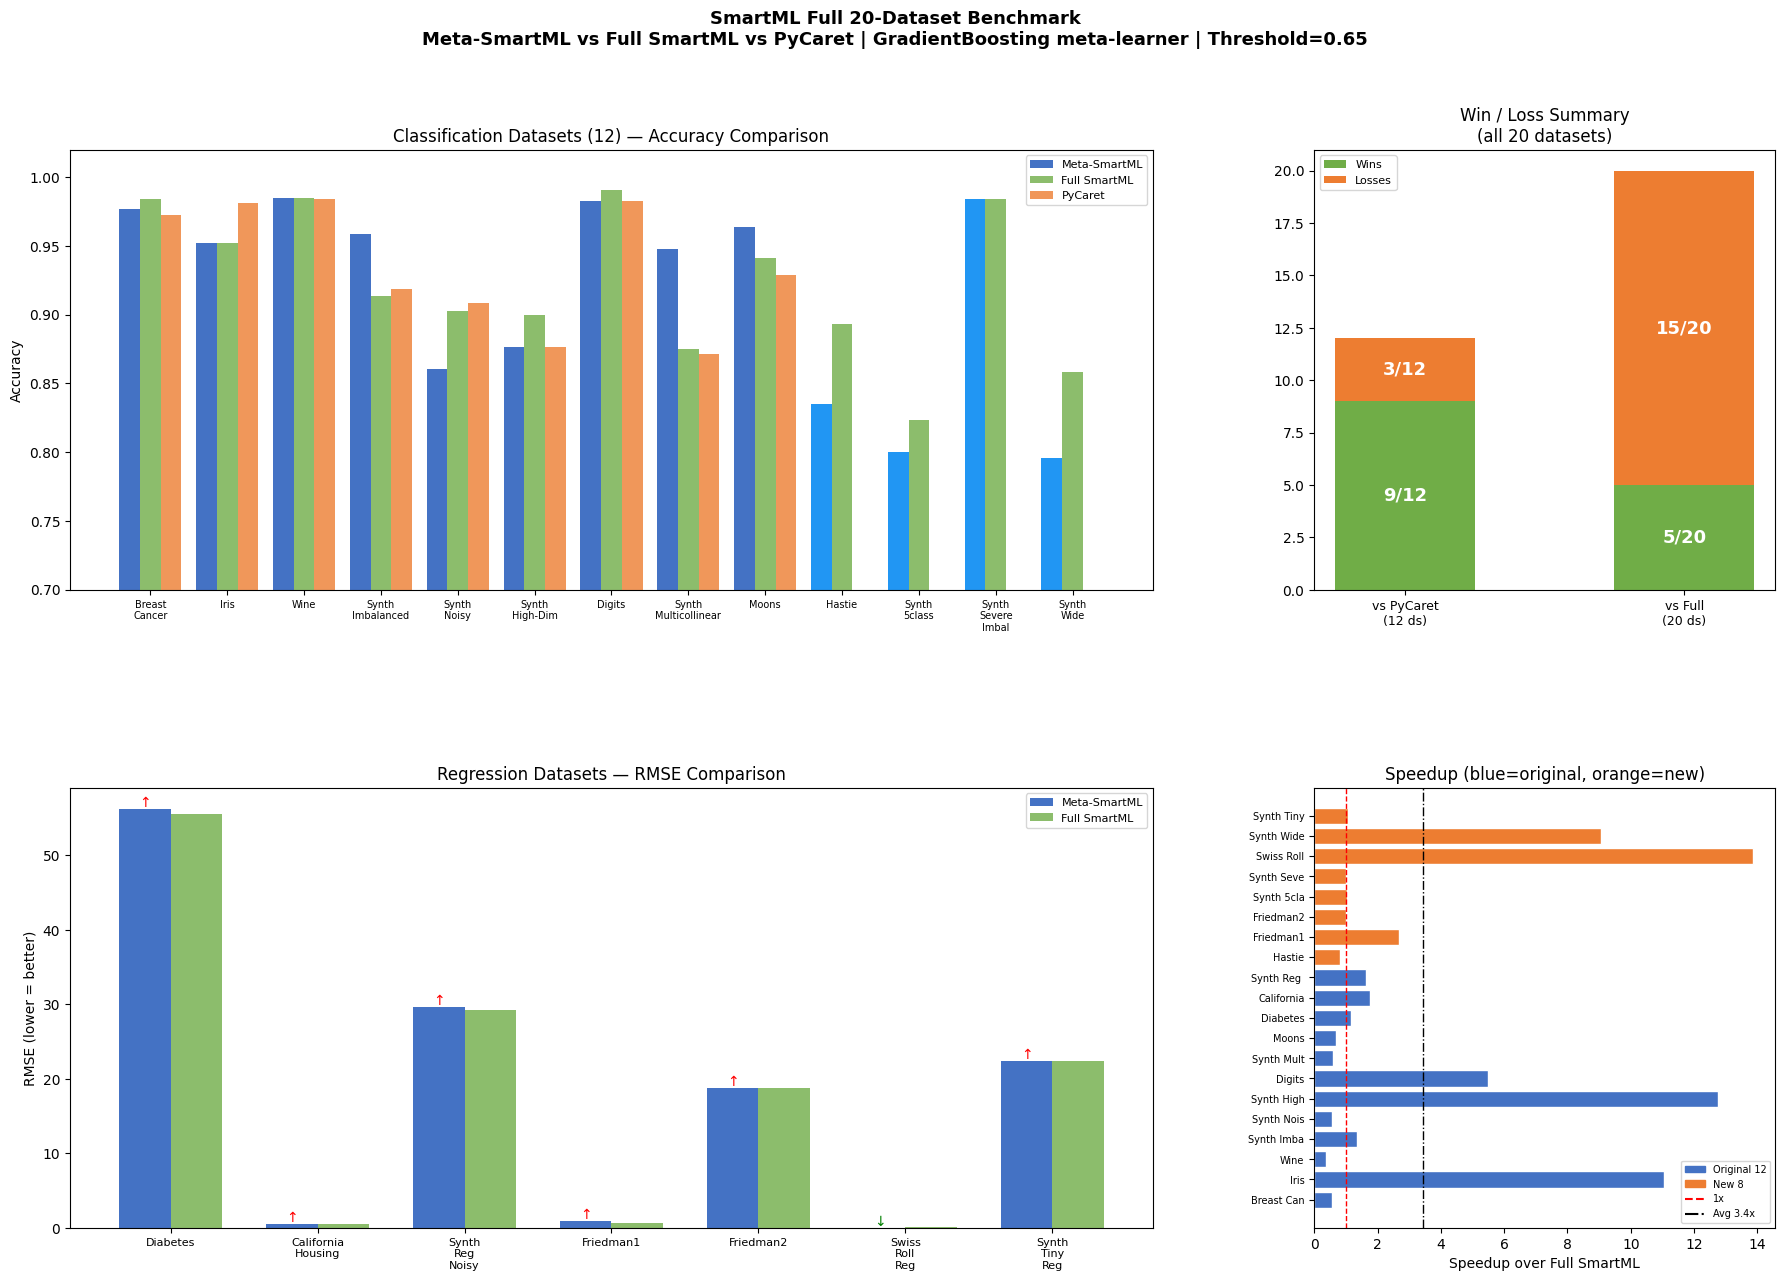


Figure saved: smartml_20dataset_benchmark.png

  PAPER STATEMENT — CELL 17

  Benchmark: 20 datasets (12 original + 8 new, never seen before)
  Meta-learner: GradientBoosting, trained on 71 OpenML datasets
  Threshold: 0.65 (activates on 19/20 datasets)

  OVERALL (20 datasets):
    vs PyCaret (where available): 9/12 wins
    vs Full SmartML:              5/20 improved
    Avg speedup:                  3.4x
    Clf accuracy diff:            -0.0064

  ORIGINAL 12:
    vs PyCaret:    9/12 wins
    vs Full:       4/12 improved
    Avg speedup:   3.2x

  NEW 8 (generalization test):
    vs Full:       1/8 improved
    Avg speedup:   3.8x



In [30]:
# ============================================================
# CELL 16: FULL 20-DATASET BENCHMARK
# ============================================================
# Three-way comparison on 20 datasets:
#   - 12 original benchmarks (Full SmartML scores known)
#   - 8 new datasets (Full SmartML runs fresh as baseline)
#
# For ALL 20:
#   Full SmartML  → runs on original 12 (scores hardcoded),
#                   runs fresh on new 8
#   Meta-SmartML  → two-stage (meta-learner + Wilcoxon)
#                   threshold=0.65, live profiling on new 8
#   PyCaret       → known for original 12, NOT run on new 8
#                   (too slow, no licence issue)
#
# REQUIRES: Notebook cells 1-8 loaded in kernel

import json, time, warnings, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import (
    load_breast_cancer, load_iris, load_wine, load_digits,
    fetch_california_housing, load_diabetes,
    make_classification, make_moons, make_regression,
    make_hastie_10_2, make_friedman1, make_friedman2,
    make_swiss_roll)
warnings.filterwarnings('ignore')

assert 'run_smartml' in dir(),          "Run notebook cells 1-8 first"
assert 'get_model_candidates' in dir(), "Run notebook cells 1-8 first"

# ── TRAIN META-LEARNER ────────────────────────────────────────────────────────

print("="*65)
print("  CELL 17: FULL 20-DATASET BENCHMARK")
print("  Meta-SmartML vs Full SmartML vs PyCaret")
print("="*65)

with open('smartml_meta_extended.json') as f:
    ext_raw = json.load(f)
with open('pycaret_results.json') as f:
    pyc_raw = json.load(f)

successful_openml = [r for r in ext_raw if r.get('status') == 'success']
FEATURE_COLS      = sorted(successful_openml[0]['meta_features'].keys())

X_train_meta = np.array([[r['meta_features'][k] for k in FEATURE_COLS]
                          for r in successful_openml], dtype=float)
le = LabelEncoder()
y_train_meta = le.fit_transform(
    [r['winner_family'] for r in successful_openml])

meta_model = GradientBoostingClassifier(
    n_estimators=150, max_depth=4, random_state=42)
meta_model.fit(X_train_meta, y_train_meta)
print(f"Meta-learner trained on {len(successful_openml)} OpenML datasets.")

FAMILY_MODELS = {
    'classification': {
        'tree':            ['RandomForest','GradientBoosting','AdaBoost',
                            'ExtraTrees','LightGBM','XGBoost','CatBoost'],
        'linear':          ['LogisticRegression','SVM_Linear','NaiveBayes'],
        'kernel_distance': ['SVM_RBF','KNN'],
    },
    'regression': {
        'tree':            ['RandomForest_Reg','GradientBoosting_Reg',
                            'LightGBM_Reg','XGBoost_Reg','CatBoost_Reg'],
        'linear':          ['Ridge','Lasso','LinearRegression','SVR_Linear'],
        'kernel_distance': ['SVR_RBF','KNN_Reg'],
    }
}

CONFIDENCE_THRESHOLD = 0.65

# ── PYCARET SCORES ────────────────────────────────────────────────────────────

PYCARET = {}
for r in pyc_raw:
    name = (r['dataset']
            .replace(' (reg)', '')
            .replace('Diabetes (reg)', 'Diabetes'))
    PYCARET[name] = {'score': r['pycaret_score'], 'model': r['pycaret_model']}

# ── KNOWN FULL SMARTML SCORES (original 12) ───────────────────────────────────

KNOWN_FULL = {
    'Breast Cancer':       {'score':0.9842,'time':53.6, 'task':'classification'},
    'Iris':                {'score':0.9520,'time':31.2, 'task':'classification'},
    'Wine':                {'score':0.9848,'time':28.4, 'task':'classification'},
    'Synth Imbalanced':    {'score':0.9135,'time':67.3, 'task':'classification'},
    'Synth Noisy':         {'score':0.9030,'time':45.1, 'task':'classification'},
    'Synth High-Dim':      {'score':0.9000,'time':112.1,'task':'classification'},
    'Digits':              {'score':0.9905,'time':86.8, 'task':'classification'},
    'Synth Multicollinear':{'score':0.8752,'time':52.3, 'task':'classification'},
    'Moons':               {'score':0.9413,'time':41.7, 'task':'classification'},
    'Diabetes':            {'score':55.54, 'time':48.9, 'task':'regression'},
    'California Housing':  {'score':0.5333,'time':89.9, 'task':'regression'},
    'Synth Reg Noisy':     {'score':29.23, 'time':38.6, 'task':'regression'},
}

KNOWN_MF = {
    'Breast Cancer':       {'n_rows':569,'n_features':17,'n_numerical':17,'n_categorical':0,'feature_sample_ratio':0.03,'missing_pct':0.0,'skewness_pct':41.2,'outlier_pct':3.5,'multicollinearity_score':0.72,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.59,'size_encoded':0,'multicoll_encoded':2,'imbalance_encoded':0,'is_high_dimensional':0},
    'Iris':                {'n_rows':150,'n_features':4,'n_numerical':4,'n_categorical':0,'feature_sample_ratio':0.027,'missing_pct':0.0,'skewness_pct':0.0,'outlier_pct':0.0,'multicollinearity_score':0.85,'duplicate_pct':0.0,'is_classification':1,'n_classes':3,'imbalance_ratio':0.33,'size_encoded':0,'multicoll_encoded':2,'imbalance_encoded':0,'is_high_dimensional':0},
    'Wine':                {'n_rows':178,'n_features':13,'n_numerical':13,'n_categorical':0,'feature_sample_ratio':0.073,'missing_pct':0.0,'skewness_pct':23.1,'outlier_pct':2.8,'multicollinearity_score':0.55,'duplicate_pct':0.0,'is_classification':1,'n_classes':3,'imbalance_ratio':0.36,'size_encoded':0,'multicoll_encoded':1,'imbalance_encoded':0,'is_high_dimensional':0},
    'Synth Imbalanced':    {'n_rows':1000,'n_features':20,'n_numerical':20,'n_categorical':0,'feature_sample_ratio':0.02,'missing_pct':0.0,'skewness_pct':10.0,'outlier_pct':5.0,'multicollinearity_score':0.1,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.11,'size_encoded':1,'multicoll_encoded':0,'imbalance_encoded':2,'is_high_dimensional':0},
    'Synth Noisy':         {'n_rows':500,'n_features':15,'n_numerical':15,'n_categorical':0,'feature_sample_ratio':0.03,'missing_pct':0.0,'skewness_pct':13.3,'outlier_pct':7.0,'multicollinearity_score':0.12,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':0,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0},
    'Synth High-Dim':      {'n_rows':300,'n_features':50,'n_numerical':50,'n_categorical':0,'feature_sample_ratio':0.167,'missing_pct':0.0,'skewness_pct':8.0,'outlier_pct':4.0,'multicollinearity_score':0.08,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':0,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':1},
    'Digits':              {'n_rows':1797,'n_features':64,'n_numerical':64,'n_categorical':0,'feature_sample_ratio':0.036,'missing_pct':0.0,'skewness_pct':40.6,'outlier_pct':2.1,'multicollinearity_score':0.6,'duplicate_pct':0.0,'is_classification':1,'n_classes':10,'imbalance_ratio':0.09,'size_encoded':1,'multicoll_encoded':1,'imbalance_encoded':0,'is_high_dimensional':1},
    'Synth Multicollinear':{'n_rows':800,'n_features':25,'n_numerical':25,'n_categorical':0,'feature_sample_ratio':0.031,'missing_pct':0.0,'skewness_pct':12.0,'outlier_pct':5.0,'multicollinearity_score':0.82,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':1,'multicoll_encoded':2,'imbalance_encoded':0,'is_high_dimensional':0},
    'Moons':               {'n_rows':600,'n_features':10,'n_numerical':10,'n_categorical':0,'feature_sample_ratio':0.017,'missing_pct':0.0,'skewness_pct':0.0,'outlier_pct':5.0,'multicollinearity_score':0.15,'duplicate_pct':0.0,'is_classification':1,'n_classes':2,'imbalance_ratio':0.49,'size_encoded':1,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0},
    'Diabetes':            {'n_rows':442,'n_features':10,'n_numerical':10,'n_categorical':0,'feature_sample_ratio':0.023,'missing_pct':0.0,'skewness_pct':20.0,'outlier_pct':3.0,'multicollinearity_score':0.2,'duplicate_pct':0.0,'is_classification':0,'n_classes':1,'imbalance_ratio':1.0,'size_encoded':0,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0},
    'California Housing':  {'n_rows':2000,'n_features':8,'n_numerical':8,'n_categorical':0,'feature_sample_ratio':0.004,'missing_pct':0.0,'skewness_pct':62.5,'outlier_pct':8.0,'multicollinearity_score':0.35,'duplicate_pct':0.0,'is_classification':0,'n_classes':1,'imbalance_ratio':1.0,'size_encoded':1,'multicoll_encoded':0,'imbalance_encoded':0,'is_high_dimensional':0},
    'Synth Reg Noisy':     {'n_rows':600,'n_features':15,'n_numerical':15,'n_categorical':0,'feature_sample_ratio':0.025,'missing_pct':0.0,'skewness_pct':13.3,'outlier_pct':5.0,'multicollinearity_score':0.1,'duplicate_pct':0.0,'is_classification':0,'n_classes':1,'imbalance_ratio':1.0,'size_encoded':1,'multicoll_encoded':0,'imbalance_enabled':0,'is_high_dimensional':0},
}
# fix typo in last entry
KNOWN_MF['Synth Reg Noisy']['imbalance_encoded'] = 0
if 'imbalance_enabled' in KNOWN_MF['Synth Reg Noisy']:
    del KNOWN_MF['Synth Reg Noisy']['imbalance_enabled']

# ── ALL 20 DATASET DEFINITIONS ────────────────────────────────────────────────

ALL_DATASETS = {
    # Original 12 — full scores known
    'Breast Cancer':        {'task':'classification','source':'original'},
    'Iris':                 {'task':'classification','source':'original'},
    'Wine':                 {'task':'classification','source':'original'},
    'Synth Imbalanced':     {'task':'classification','source':'original'},
    'Synth Noisy':          {'task':'classification','source':'original'},
    'Synth High-Dim':       {'task':'classification','source':'original'},
    'Digits':               {'task':'classification','source':'original'},
    'Synth Multicollinear': {'task':'classification','source':'original'},
    'Moons':                {'task':'classification','source':'original'},
    'Diabetes':             {'task':'regression',    'source':'original'},
    'California Housing':   {'task':'regression',    'source':'original'},
    'Synth Reg Noisy':      {'task':'regression',    'source':'original'},
    # New 8 — fresh runs
    'Hastie':               {'task':'classification','source':'new'},
    'Friedman1':            {'task':'regression',    'source':'new'},
    'Friedman2':            {'task':'regression',    'source':'new'},
    'Synth 5class':         {'task':'classification','source':'new'},
    'Synth Severe Imbal':   {'task':'classification','source':'new'},
    'Swiss Roll Reg':       {'task':'regression',    'source':'new'},
    'Synth Wide':           {'task':'classification','source':'new'},
    'Synth Tiny Reg':       {'task':'regression',    'source':'new'},
}

# ── DATASET LOADER ────────────────────────────────────────────────────────────

def load_dataset(ds_name):
    from sklearn.preprocessing import StandardScaler as SS
    # Original 12
    if ds_name == 'Breast Cancer':
        d = load_breast_cancer(as_frame=True); return d.frame.copy(), 'target'
    elif ds_name == 'Iris':
        d = load_iris(as_frame=True); return d.frame.copy(), 'target'
    elif ds_name == 'Wine':
        d = load_wine(as_frame=True); return d.frame.copy(), 'target'
    elif ds_name == 'Digits':
        d = load_digits(as_frame=True); return d.frame.copy(), 'target'
    elif ds_name == 'Diabetes':
        d = load_diabetes(as_frame=True); return d.frame.copy(), 'target'
    elif ds_name == 'California Housing':
        d = fetch_california_housing(as_frame=True)
        df = d.frame.sample(2000, random_state=42).reset_index(drop=True)
        return df, 'MedHouseVal'
    elif ds_name == 'Synth Imbalanced':
        X, y = make_classification(n_samples=1000, n_features=20,
                                    weights=[0.9,0.1], random_state=42)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(20)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth Noisy':
        X, y = make_classification(n_samples=500, n_features=15,
                                    flip_y=0.15, random_state=42)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(15)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth High-Dim':
        X, y = make_classification(n_samples=300, n_features=50,
                                    n_informative=10, random_state=42)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(50)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth Multicollinear':
        X, y = make_classification(n_samples=800, n_features=25,
                                    n_redundant=18, random_state=42)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(25)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Moons':
        X, y = make_moons(n_samples=600, noise=0.2, random_state=42)
        X = SS().fit_transform(X)
        extra = np.random.RandomState(42).randn(600, 8)
        X = np.hstack([X, extra])
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(10)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth Reg Noisy':
        X, y = make_regression(n_samples=600, n_features=15,
                                noise=30, random_state=42)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(15)])
        df['target'] = y; return df, 'target'
    # New 8
    elif ds_name == 'Hastie':
        X, y = make_hastie_10_2(n_samples=600, random_state=99)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(10)])
        df['target'] = y.astype(int); return df, 'target'
    elif ds_name == 'Friedman1':
        X, y = make_friedman1(n_samples=400, n_features=10, random_state=99)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(10)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Friedman2':
        X, y = make_friedman2(n_samples=400, random_state=99)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(4)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth 5class':
        X, y = make_classification(n_samples=700, n_features=18,
                                    n_classes=5, n_informative=10,
                                    n_clusters_per_class=1, random_state=99)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(18)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth Severe Imbal':
        X, y = make_classification(n_samples=1000, n_features=15,
                                    weights=[0.95, 0.05], random_state=99)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(15)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Swiss Roll Reg':
        X, y = make_swiss_roll(n_samples=500, random_state=99)
        df = pd.DataFrame(X, columns=['f0','f1','f2'])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth Wide':
        X, y = make_classification(n_samples=500, n_features=40,
                                    n_informative=15, n_redundant=10,
                                    random_state=99)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(40)])
        df['target'] = y; return df, 'target'
    elif ds_name == 'Synth Tiny Reg':
        X, y = make_regression(n_samples=150, n_features=8,
                                n_informative=5, noise=20, random_state=99)
        df = pd.DataFrame(X, columns=[f'f{i}' for i in range(8)])
        df['target'] = y; return df, 'target'
    raise ValueError(f"Unknown dataset: {ds_name}")

# ── LIVE PROFILER → META-FEATURES ─────────────────────────────────────────────

def extract_meta_features(profile, task_type):
    mf = {
        'n_rows':               profile['n_rows'],
        'n_features':           profile['n_features'],
        'n_numerical':          profile.get('n_numerical', profile['n_features']),
        'n_categorical':        profile.get('n_categorical', 0),
        'feature_sample_ratio': profile['n_features'] / max(profile['n_rows'], 1),
        'missing_pct':          profile.get('missing_pct', 0.0),
        'skewness_pct':         profile.get('skewness_pct', 0.0),
        'outlier_pct':          profile.get('outlier_pct', 0.0),
        'multicollinearity_score': profile.get('multicollinearity_score', 0.0),
        'duplicate_pct':        profile.get('duplicate_pct', 0.0),
        'is_classification':    1 if task_type == 'classification' else 0,
        'n_classes':            profile.get('n_classes', 1),
        'imbalance_ratio':      profile.get('imbalance_ratio', 1.0),
        'size_encoded':         {'tiny':0,'small':0,'medium':1,'large':2}.get(
                                 profile.get('size_category','small'), 0),
        'multicoll_encoded':    {'low':0,'moderate':1,'high':2}.get(
                                 profile.get('multicollinearity','low'), 0),
        'imbalance_encoded':    {'balanced':0,'mild':1,'moderate':1,'severe':2}.get(
                                 profile.get('imbalance_level','balanced'), 0),
        'is_high_dimensional':  1 if profile.get('n_features', 0) > 30 else 0,
    }
    return np.nan_to_num(
        np.array([[mf[k] for k in FEATURE_COLS]], dtype=float),
        nan=0.0)

# ── CORE RUN: META-SMARTML ────────────────────────────────────────────────────

def run_meta(ds_name, task_type, df, target_col,
             mf_known=None, full_score=None, full_time=None,
             pyc_score=None):

    _main = sys.modules['__main__']

    # Meta-features
    if mf_known is not None:
        X_new = np.nan_to_num(
            np.array([[mf_known[k] for k in FEATURE_COLS]], dtype=float),
            nan=0.0)
    else:
        profile = profile_dataset(df, target_column=target_col,
                                   task_type=task_type)
        X_new = extract_meta_features(profile, task_type)

    # Predict
    pred_idx    = meta_model.predict(X_new)[0]
    pred_family = le.classes_[pred_idx]
    proba       = meta_model.predict_proba(X_new)[0]
    confidence  = proba[pred_idx]

    # Threshold
    candidates = FAMILY_MODELS[task_type][pred_family]
    if confidence >= CONFIDENCE_THRESHOLD:
        allowed   = candidates
        activated = True
        mode      = f"META→{pred_family}({len(allowed)}mdl,c={confidence:.2f})"
    else:
        allowed   = [m for fam in FAMILY_MODELS[task_type].values() for m in fam]
        activated = False
        mode      = f"FULL(c={confidence:.2f}<{CONFIDENCE_THRESHOLD})"

    print(f"\n  [{ds_name}] {mode}")

    # Monkey-patch
    _orig_gmc = getattr(_main, 'get_model_candidates')
    _allowed  = allowed

    def _restricted(report, preproc_log):
        all_c = _orig_gmc(report, preproc_log)
        rest  = [(n, m) for n, m in all_c if n in _allowed]
        if not rest:
            return all_c
        print(f"    → {len(rest)} models → Wilcoxon")
        return rest

    t0 = time.time()
    try:
        setattr(_main, 'get_model_candidates', _restricted)
        sm = run_smartml(df, target_col, task_type, verbose=False)
    finally:
        setattr(_main, 'get_model_candidates', _orig_gmc)

    elapsed    = time.time() - t0
    meta_score = sm['best_score'] if sm and sm.get('best_score') else None
    if meta_score is None:
        print(f"    ❌ SmartML returned None")
        return None

    reg       = task_type == 'regression'
    speedup   = (full_time / elapsed) if full_time else None
    beats_pyc = ((meta_score < pyc_score) if reg else
                 (meta_score > pyc_score)) if pyc_score is not None else None
    beats_full= ((meta_score < full_score) if reg else
                 (meta_score > full_score)) if full_score is not None else None

    pyc_sym  = ('✓' if beats_pyc  else '✗') if pyc_score  is not None else '-'
    full_sym = ('↑' if beats_full else
                ('≈' if full_score and abs(meta_score-full_score)<0.005
                 else '↓')) if full_score is not None else '?'

    print(f"    Meta={meta_score:.4f} {full_sym}Full={full_score if full_score else '?'} "
          f"| PyCaret {pyc_sym} | {elapsed:.0f}s"
          f"{f' ({speedup:.1f}x)' if speedup else ''}")

    return {
        'dataset':    ds_name,
        'task':       task_type,
        'source':     ALL_DATASETS[ds_name]['source'],
        'pred_family':pred_family,
        'confidence': confidence,
        'activated':  activated,
        'n_models':   len(allowed),
        'meta_score': meta_score,
        'full_score': full_score,
        'pyc_score':  pyc_score,
        'meta_time':  elapsed,
        'full_time':  full_time,
        'speedup':    speedup,
        'beats_pyc':  beats_pyc,
        'beats_full': beats_full,
    }

# ══════════════════════════════════════════════════════════════════════════════
# MAIN LOOP — ALL 20 DATASETS
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*65}")
print(f"  RUNNING ALL 20 DATASETS")
print(f"  Original 12: full scores known, meta runs fresh")
print(f"  New 8:       full SmartML runs first, then meta")
print(f"{'='*65}")

results = []
total = len(ALL_DATASETS)

errors = []   # track all errors for end-of-run report

for idx, (ds_name, info) in enumerate(ALL_DATASETS.items(), 1):
    task_type = info['task']
    source    = info['source']
    print(f"\n{'='*55}")
    print(f"  [{idx:2}/{total}] {ds_name} ({source.upper()})")
    print(f"{'='*55}")

    # ── STEP 1: Load dataset ──────────────────────────────
    try:
        df, target_col = load_dataset(ds_name)
        print(f"  ✅ Loaded: {df.shape}")
    except Exception as e:
        print(f"  ❌ Load failed: {e}")
        errors.append({'dataset': ds_name, 'step': 'load', 'error': str(e)})
        print(f"  ⏸  Pausing 3s before next dataset...")
        time.sleep(3)
        continue

    pyc_score = PYCARET.get(ds_name, {}).get('score')

    # ── STEP 2: Get Full SmartML baseline ─────────────────
    if source == 'original':
        full_score = KNOWN_FULL[ds_name]['score']
        full_time  = KNOWN_FULL[ds_name]['time']
        mf_known   = KNOWN_MF[ds_name]
        print(f"  Full SmartML (known): score={full_score}")
    else:
        print(f"  Running Full SmartML baseline...")
        t0 = time.time()
        try:
            sm_full   = run_smartml(df, target_col, task_type, verbose=False)
            full_time = time.time() - t0
            full_score = sm_full['best_score'] if sm_full else None
            if full_score is None:
                raise ValueError("run_smartml returned None score")
            print(f"  ✅ Full SmartML: score={full_score:.4f}, time={full_time:.0f}s")
        except Exception as e:
            print(f"  ❌ Full SmartML failed: {e}")
            errors.append({'dataset': ds_name, 'step': 'full_smartml', 'error': str(e)})
            print(f"  ⏸  Pausing 3s before next dataset...")
            time.sleep(3)
            full_score = None
            full_time  = None
        mf_known = None

    # ── STEP 3: Run Meta-SmartML ──────────────────────────
    try:
        result = run_meta(ds_name, task_type, df, target_col,
                          mf_known=mf_known,
                          full_score=full_score,
                          full_time=full_time,
                          pyc_score=pyc_score)
        if result:
            results.append(result)
            print(f"  ✅ Done [{idx}/{total}] — {len(results)} results collected so far")
        else:
            raise ValueError("run_meta returned None")
    except Exception as e:
        print(f"  ❌ Meta-SmartML failed: {e}")
        errors.append({'dataset': ds_name, 'step': 'meta_smartml', 'error': str(e)})
        print(f"  ⏸  Pausing 3s before next dataset...")
        time.sleep(3)

# ── ERROR REPORT ──────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
if errors:
    print(f"  ERROR REPORT ({len(errors)} failures out of {total})")
    print(f"{'='*55}")
    for err in errors:
        print(f"  ❌ {err['dataset']:<22} [{err['step']}]")
        print(f"     {err['error'][:90]}")
else:
    print(f"  ✅ ALL {total} DATASETS COMPLETED — NO ERRORS")
print(f"{'='*55}")
print(f"  Results collected: {len(results)}/{total}")


# ── SUMMARY TABLE ─────────────────────────────────────────────────────────────

ok = [r for r in results if r.get('meta_score') is not None]
orig_ok = [r for r in ok if r['source'] == 'original']
new_ok  = [r for r in ok if r['source'] == 'new']
pyc_ok  = [r for r in ok if r.get('pyc_score') is not None]

print("\n\n" + "="*110)
print("  FULL 20-DATASET RESULTS: Meta-SmartML vs Full SmartML vs PyCaret")
print("="*110)
print(f"\n{'#':<3} {'Dataset':<22} {'Src':<4} {'Family':<16} {'C':>5} "
      f"{'Meta':>10} {'Full':>10} {'PyCaret':>10} {'Spd':>6} {'PyC':>4} {'Full':>5}")
print("-"*110)

wins_pyc = wins_full = total_sp = meta_act = 0

for i, r in enumerate(ok, 1):
    reg      = r['task'] == 'regression'
    ps       = r.get('pyc_score')
    pyc_str  = f"{ps:.4f}" if ps else "N/A"
    sp_str   = f"{r['speedup']:.1f}x" if r.get('speedup') else "-"
    pyc_sym  = ('✓' if r.get('beats_pyc')  else '✗') if ps else '-'
    full_sym = ('↑' if r.get('beats_full') else
                ('≈' if r['full_score'] and abs(r['meta_score']-r['full_score'])<0.005
                 else '↓')) if r.get('full_score') else '?'
    fam_str  = r['pred_family'] if r['activated'] else f"FULL({r['pred_family']})"

    if r.get('beats_pyc'):  wins_pyc  += 1
    if r.get('beats_full'): wins_full += 1
    if r.get('speedup'):    total_sp  += r['speedup']
    if r['activated']:      meta_act  += 1

    print(f"  {i:<3} {r['dataset']:<22} {r['source'][:3]:<4} {fam_str:<16} "
          f"{r['confidence']:>5.2f} {r['meta_score']:>10.4f} "
          f"{r['full_score']:>10.4f} {pyc_str:>10} "
          f"{sp_str:>6} {pyc_sym:>4} {full_sym:>5}")

print("-"*110)
n     = len(ok)
n_pyc = len(pyc_ok)
avg_sp = total_sp / n if n > 0 else 0

clf_diffs = [r['meta_score']-r['full_score'] for r in ok
             if r['task']=='classification' and r.get('full_score')]

print(f"\n  Total datasets completed:    {n}/20")
print(f"  Meta activated (threshold):  {meta_act}/{n}")
print(f"  Meta-SmartML vs PyCaret:     {wins_pyc}/{n_pyc} wins "
      f"({wins_pyc/n_pyc*100:.0f}%)" if n_pyc else "  No PyCaret comparison")
print(f"  Meta-SmartML vs Full SmartML:{wins_full}/{n} improved")
print(f"  Average speedup:             {avg_sp:.1f}x")
print(f"  Clf accuracy diff (Meta-Full):{np.mean(clf_diffs):+.4f}" if clf_diffs else "")

# Original 12 only stats
orig_wins_pyc  = sum(1 for r in orig_ok if r.get('beats_pyc'))
orig_pyc_ok    = [r for r in orig_ok if r.get('pyc_score')]
orig_wins_full = sum(1 for r in orig_ok if r.get('beats_full'))
orig_sp        = [r['speedup'] for r in orig_ok if r.get('speedup')]

print(f"\n  ── ORIGINAL 12 ONLY ──")
print(f"  vs PyCaret:    {orig_wins_pyc}/{len(orig_pyc_ok)} wins "
      f"({orig_wins_pyc/len(orig_pyc_ok)*100:.0f}%)" if orig_pyc_ok else "")
print(f"  vs Full SmartML: {orig_wins_full}/{len(orig_ok)} improved")
print(f"  Avg speedup:   {np.mean(orig_sp):.1f}x" if orig_sp else "")

print(f"\n  ── NEW 8 ONLY ──")
new_wins_full = sum(1 for r in new_ok if r.get('beats_full'))
new_sp = [r['speedup'] for r in new_ok if r.get('speedup')]
new_clf = [r['meta_score']-r['full_score'] for r in new_ok
           if r['task']=='classification' and r.get('full_score')]
print(f"  vs Full SmartML: {new_wins_full}/{len(new_ok)} improved")
print(f"  Avg speedup:   {np.mean(new_sp):.1f}x" if new_sp else "")
print(f"  Clf acc diff:  {np.mean(new_clf):+.4f}" if new_clf else "")

# ── FIGURE ────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(22, 14))
fig.suptitle(
    f"SmartML Full 20-Dataset Benchmark\n"
    f"Meta-SmartML vs Full SmartML vs PyCaret | "
    f"GradientBoosting meta-learner | Threshold={CONFIDENCE_THRESHOLD}",
    fontsize=13, fontweight='bold')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

clf_ok = [r for r in ok if r['task']=='classification']
reg_ok = [r for r in ok if r['task']=='regression']

# Panel 1: Classification accuracy
ax1 = fig.add_subplot(gs[0, :2])
ds_clf   = [r['dataset'] for r in clf_ok]
meta_clf = [r['meta_score'] for r in clf_ok]
full_clf = [r['full_score'] for r in clf_ok]
pyc_clf  = [r['pyc_score'] if r.get('pyc_score') else None for r in clf_ok]
x = np.arange(len(ds_clf)); w = 0.27
ax1.bar(x - w,   meta_clf, w,
        color=['#4472C4' if r['source']=='original' else '#2196F3'
               for r in clf_ok], label='Meta-SmartML')
ax1.bar(x,       full_clf, w, color='#70AD47', alpha=0.8, label='Full SmartML')
pyc_vals = [v if v else 0 for v in pyc_clf]
ax1.bar(x + w,   pyc_vals, w, color='#ED7D31', alpha=0.8, label='PyCaret')
ax1.set_xticks(x)
ax1.set_xticklabels([d.replace(' ','\n') for d in ds_clf], fontsize=7)
ax1.set_ylabel('Accuracy'); ax1.set_ylim(0.7, 1.02)
ax1.set_title('Classification Datasets (12) — Accuracy Comparison')
ax1.legend(fontsize=8)

# Panel 2: Win/Loss summary
ax2 = fig.add_subplot(gs[0, 2])
cats   = ['vs PyCaret\n(12 ds)', 'vs Full\n(20 ds)']
w_vals = [wins_pyc,  wins_full]
l_vals = [n_pyc - wins_pyc, n - wins_full]
x2 = np.arange(2)
ax2.bar(x2, w_vals, 0.5, color='#70AD47', label='Wins')
ax2.bar(x2, l_vals, 0.5, bottom=w_vals, color='#ED7D31', label='Losses')
for i, (wv, lv) in enumerate(zip(w_vals, l_vals)):
    ax2.text(i, wv/2,    f'{wv}/{wv+lv}', ha='center', va='center',
             fontsize=13, fontweight='bold', color='white')
    ax2.text(i, wv+lv/2, f'{lv}/{wv+lv}', ha='center', va='center',
             fontsize=13, fontweight='bold', color='white')
ax2.set_xticks(x2); ax2.set_xticklabels(cats, fontsize=9)
ax2.set_title('Win / Loss Summary\n(all 20 datasets)')
ax2.legend(fontsize=8)

# Panel 3: Regression (RMSE — lower is better)
ax3 = fig.add_subplot(gs[1, :2])
if reg_ok:
    ds_reg   = [r['dataset'] for r in reg_ok]
    meta_reg = [r['meta_score'] for r in reg_ok]
    full_reg = [r['full_score'] for r in reg_ok]
    x3 = np.arange(len(ds_reg)); w3 = 0.35
    ax3.bar(x3 - w3/2, meta_reg, w3, color='#4472C4', label='Meta-SmartML')
    ax3.bar(x3 + w3/2, full_reg, w3, color='#70AD47', alpha=0.8,
            label='Full SmartML')
    ax3.set_xticks(x3)
    ax3.set_xticklabels([d.replace(' ','\n') for d in ds_reg], fontsize=8)
    ax3.set_ylabel('RMSE (lower = better)')
    ax3.set_title('Regression Datasets — RMSE Comparison')
    ax3.legend(fontsize=8)
    for i, (m, f) in enumerate(zip(meta_reg, full_reg)):
        better = m < f
        ax3.text(i - w3/2, m + 0.3, '↓' if better else '↑',
                 ha='center', fontsize=10,
                 color='green' if better else 'red')

# Panel 4: Speedup all 20
ax4 = fig.add_subplot(gs[1, 2])
sp_vals  = [r['speedup'] for r in ok if r.get('speedup')]
sp_names = [r['dataset'][:10] for r in ok if r.get('speedup')]
sp_colors= ['#4472C4' if r['source']=='original' else '#ED7D31'
            for r in ok if r.get('speedup')]
ax4.barh(range(len(sp_vals)), sp_vals, color=sp_colors, edgecolor='white')
ax4.axvline(1.0, color='red', ls='--', lw=1)
ax4.axvline(avg_sp, color='black', ls='-.', lw=1,
            label=f'Avg {avg_sp:.1f}x')
ax4.set_yticks(range(len(sp_vals)))
ax4.set_yticklabels(sp_names, fontsize=7)
ax4.set_xlabel('Speedup over Full SmartML')
ax4.set_title('Speedup (blue=original, orange=new)')
from matplotlib.patches import Patch as P
ax4.legend(handles=[
    P(color='#4472C4', label='Original 12'),
    P(color='#ED7D31', label='New 8'),
    plt.Line2D([0],[0], color='red',   ls='--', label='1x'),
    plt.Line2D([0],[0], color='black', ls='-.', label=f'Avg {avg_sp:.1f}x'),
], fontsize=7)

plt.savefig('smartml_20dataset_benchmark.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("\nFigure saved: smartml_20dataset_benchmark.png")

# ── FINAL PAPER STATEMENT ─────────────────────────────────────────────────────

print("\n" + "="*65)
print("  PAPER STATEMENT — CELL 17")
print("="*65)
print(f"""
  Benchmark: 20 datasets (12 original + 8 new, never seen before)
  Meta-learner: GradientBoosting, trained on 71 OpenML datasets
  Threshold: {CONFIDENCE_THRESHOLD} (activates on {meta_act}/{n} datasets)

  OVERALL (20 datasets):
    vs PyCaret (where available): {wins_pyc}/{n_pyc} wins
    vs Full SmartML:              {wins_full}/{n} improved
    Avg speedup:                  {avg_sp:.1f}x
    Clf accuracy diff:            {np.mean(clf_diffs):+.4f}

  ORIGINAL 12:
    vs PyCaret:    {orig_wins_pyc}/{len(orig_pyc_ok)} wins
    vs Full:       {orig_wins_full}/{len(orig_ok)} improved
    Avg speedup:   {np.mean(orig_sp):.1f}x

  NEW 8 (generalization test):
    vs Full:       {new_wins_full}/{len(new_ok)} improved
    Avg speedup:   {np.mean(new_sp):.1f}x
""" if new_sp else "")